# Chapter 9 — Machine Learning

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

This notebook is the **complete chapter**: every definition, table and worked example, with runnable code for all of it. Everything is built with plain numpy and pandas, so each step of each algorithm can be seen before Chapters 10 and 11 hand you the library versions.

**In this chapter:** What machine learning is · Traditional code vs. learning · Supervised · Unsupervised · Semi-supervised · Reinforcement · Overfitting · Accuracy & the confusion matrix · Glossary + homework



> **Learning objectives.** By the end of this chapter you should be able to:
>
> - **Explain machine learning** — say what it is in your own words, where the term came from, and, for a piece of software, whether the rules inside it were written by a person or learned from data.
> - **Carry out supervised learning by hand** — classify a new case from labeled examples with the nearest-neighbor rule, and explain why a model must be judged on data it has never seen.
> - **Carry out unsupervised learning by hand** — run the K-means loop step by step, read a dendrogram, and compute support, confidence and lift for an association rule.
> - **Place a problem in the right family** — supervised, unsupervised, semi-supervised or reinforcement — and say which algorithms that family offers.



**Contents**

- **9.9.1 · What is machine learning?** — the idea, and where it already runs
    - 9.1.1 Traditional programming vs. machine learning
    - 9.1.2 Machine learning you already use
    - 9.1.3 A deeper example — self-driving cars
- **9.9.2 · Types of machine learning** — the map for the whole chapter
    - 9.2.1 Which type is this problem?
- **9.9.3 · Supervised learning** — learning from labeled examples
    - 9.3.1 A first classifier — nearest neighbor
    - 9.3.2 Training, testing and accuracy
    - 9.3.3 Overfitting and underfitting
    - 9.3.4 Validation and cross-validation
    - 9.3.5 The confusion matrix
    - 9.3.6 Classification and regression
    - 9.3.7 Named algorithms
- **9.9.4 · Unsupervised learning** — structure with no labels
    - 9.4.1 K-means clustering
    - 9.4.2 Hierarchical clustering
    - 9.4.3 Association rules
- **9.9.5 · Semi-supervised learning** — a few labels, a lot of data
- **9.9.6 · Reinforcement learning** — no dataset at all
    - 9.6.1 Exploration and exploitation
- **9.9.7 · Summary** — glossary, sources, self-check
    - 9.7.1 Glossary
    - 9.7.2 Sources
    - 9.7.3 Check your understanding
- **9.9.8 · Homework** — the graded work



> **How to use this notebook.** Sections 9.1 and 9.2 are reading. From Section 9.3 on, each idea is first explained and worked by hand, then built in code, one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** box says what the output below will show and what it means. Run the cells in order — later cells use variables made by earlier ones. The **Try it** boxes are small ungraded challenges. The graded work is Section 8.

> **Before you start.** This notebook assumes no prior coding experience.
>
> - A Jupyter notebook is made of **cells**: markdown (text, like this one) or code (Python that runs).
> - To run a code cell, click it and press **Shift + Enter**.
> - A **variable** is a name that stores a value: `n = 40` stores 40 under the name `n`. `#` starts a **comment** — text for people, which Python ignores.
> - If a cell fails, a cell above it was probably skipped. **Kernel → Restart & Run All** runs everything again from the top.



### Notation used in this chapter

*the symbols that appear below, and how to read them*

This chapter and the three after it write some ideas as formulas. A formula is only shorthand: every one of them can be said in an ordinary sentence, and each is followed here by a worked example with real numbers. These are the symbols that appear.

| Symbol | Say it as | Tiny example |
|---|---|---|
| **$x_1, x_2, x_i$** | “the first value, the second value, the $i$-th value” — a subscript is a label | If $x = (4, 9, 2)$ then $x_2 = 9$ |
| **$\bar{x}$** | “x-bar”, the **average** of all the $x$ values | $x = (4, 9, 2) \Rightarrow \bar{x} = (4+9+2)/3 = 5$ |
| **$\sum$** | “add up all of these” (Greek capital sigma, S for *sum*) | $\sum_{i=1}^{3} x_i = 4 + 9 + 2 = 15$ |
| **$\prod$** | “multiply all of these together” (capital pi, P for *product*) | $\prod_{i=1}^{3} x_i = 4 \times 9 \times 2 = 72$ |



#### Notation — continued

*three more symbols*

| Symbol | Say it as | Tiny example |
|---|---|---|
| **$\lvert a - b \rvert$** | the **distance** between two numbers, always positive | $\lvert 3 - 8 \rvert = 5$, and $\lvert 8 - 3 \rvert = 5$ too |
| **$\lVert \mathbf{x} \rVert$** | the **length** of an arrow from the origin to point $\mathbf{x}$ | for $(3,4)$: $\sqrt{3^2+4^2} = 5$ |
| **$\mathbf{1}[\,\cdot\,]$** | “**1 if this is true, 0 if false**” — a way to count things | $\mathbf{1}[5 > 3] = 1$ and $\mathbf{1}[5 > 9] = 0$ |



#### Notation — the last three

*and how to read them*

| Symbol | Say it as | Tiny example |
|---|---|---|
| **$\arg\max$** | “**which option gives the biggest answer**” (the option, not the answer) | if scores are A=2, B=7, C=5 then $\arg\max = B$ |
| **$\log$** | how many times you multiply the base to reach a number | $\log_2 8 = 3$, because $2\times2\times2 = 8$ |
| **$\hat{y}$** | “y-hat” — a **predicted** value, as opposed to the true $y$ | true price $y = 100$, predicted $\hat{y} = 94$ |



#### The symbols

*Notation · continued*

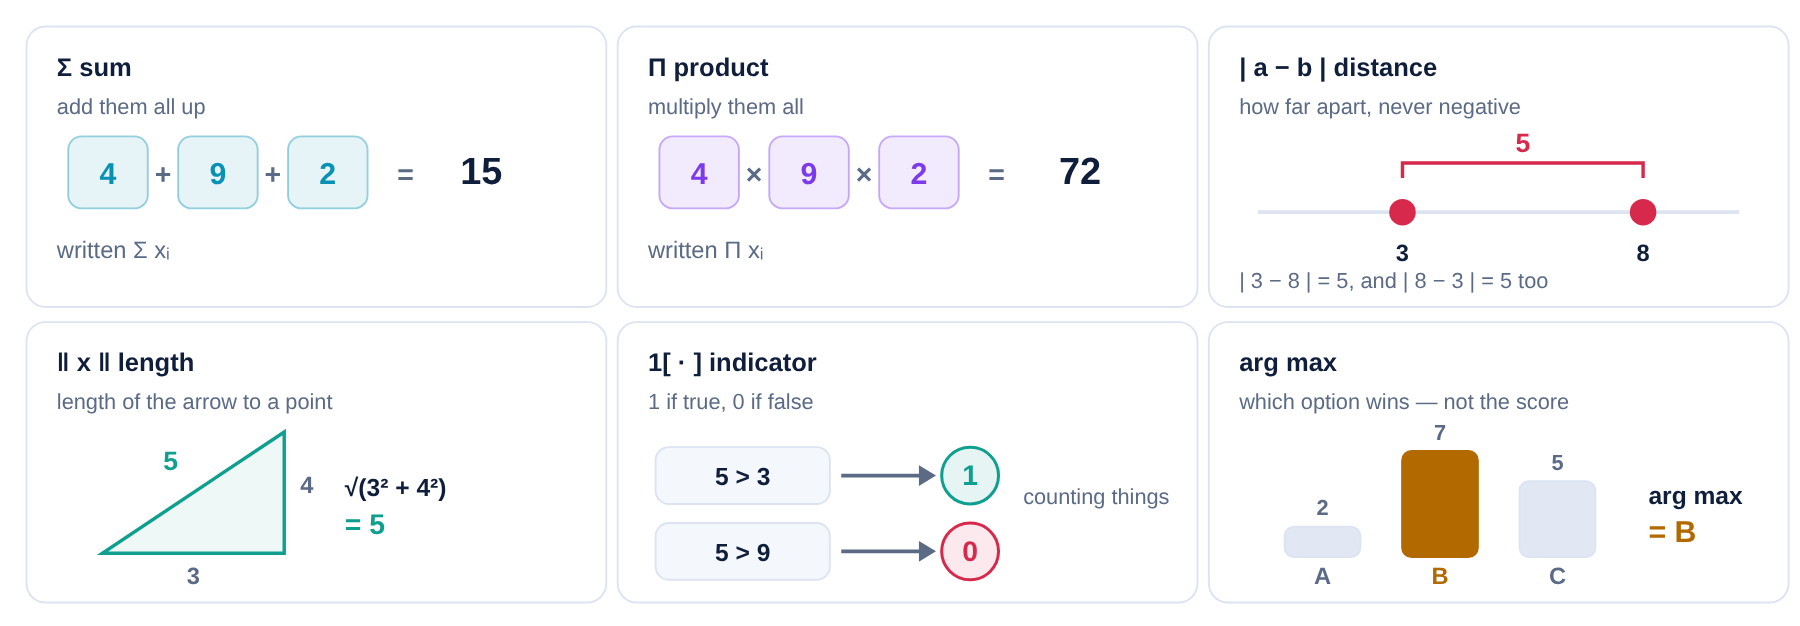

*The six symbols this chapter actually uses. Each one is a short instruction, not a concept — read it out loud and it stops being intimidating.*

> **Reading summation notation.** When you meet $\sum_{i=1}^{n}$, read it as *“for every row from the first to the last, work out the thing on the right, then add all those answers together.”* That one sentence unlocks most of the formulas in this course. Everything else is naming.



#### Setting up

One cell of preparation before the chapter begins. It loads the three libraries every code cell below relies on — numpy for arrays of numbers, pandas for tables, matplotlib for charts — and creates `rng`, a random-number generator started from the seed 888102. The seed is what makes every student's numbers identical: the same seed always produces the same sequence of “random” values. Sections 9.1 and 9.2 need no code; the tools are ready for Section 3.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(888102)   # the seed: every student gets the same "random" numbers
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 9.1 · What is machine learning?

*Data in, rules out — the one idea the chapter rests on*

> **Definition.** **Machine learning** is a subset of Artificial Intelligence (AI) that provides machines the ability to learn automatically and improve from experience, **without being explicitly programmed to do so**.

The last part of that definition is the whole idea. In ordinary programming a human works out the rules and types them in. In machine learning the human supplies **data**, and the machine works out the **rules** itself.

> **In plain words.** Instead of a programmer writing every rule by hand, the machine is shown examples and finds its own rules for solving the problem.

This section makes that idea concrete three times over: first where the term came from, then by setting the two ways of programming side by side on one problem, and then in four products you use every day. Section 9.2 then sorts machine learning into its families, and the rest of the chapter takes the families one at a time.



#### Origin of the term

> **Arthur Samuel, 1959.** The term *machine learning* was coined in **1959 by Arthur Samuel**, an IBM researcher. His checkers-playing program was among the world's first self-learning programs: rather than being told what a good move looks like, it improved by **playing more and more games****against itself** and keeping track of which positions tended to lead to a win. Nobody taught it strategy. It got better because it had played more games — which is what “learning from experience” means. Sixty years later the same idea, scaled up enormously, lets a program teach itself to play Go or chess at superhuman level.

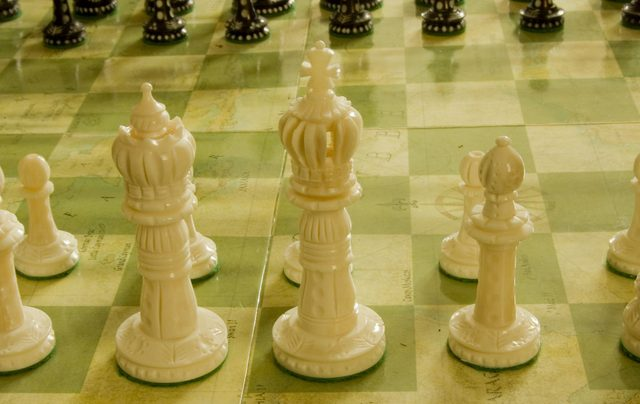

*Board games were the first proving ground for learning programs: Samuel's checkers player in 1959, and the chess and Go engines that now teach themselves to superhuman strength. — Photo: “Chess Pieces” by plffft, CC BY — flickr.com*



#### The first self-learning program

*Samuel's loop*

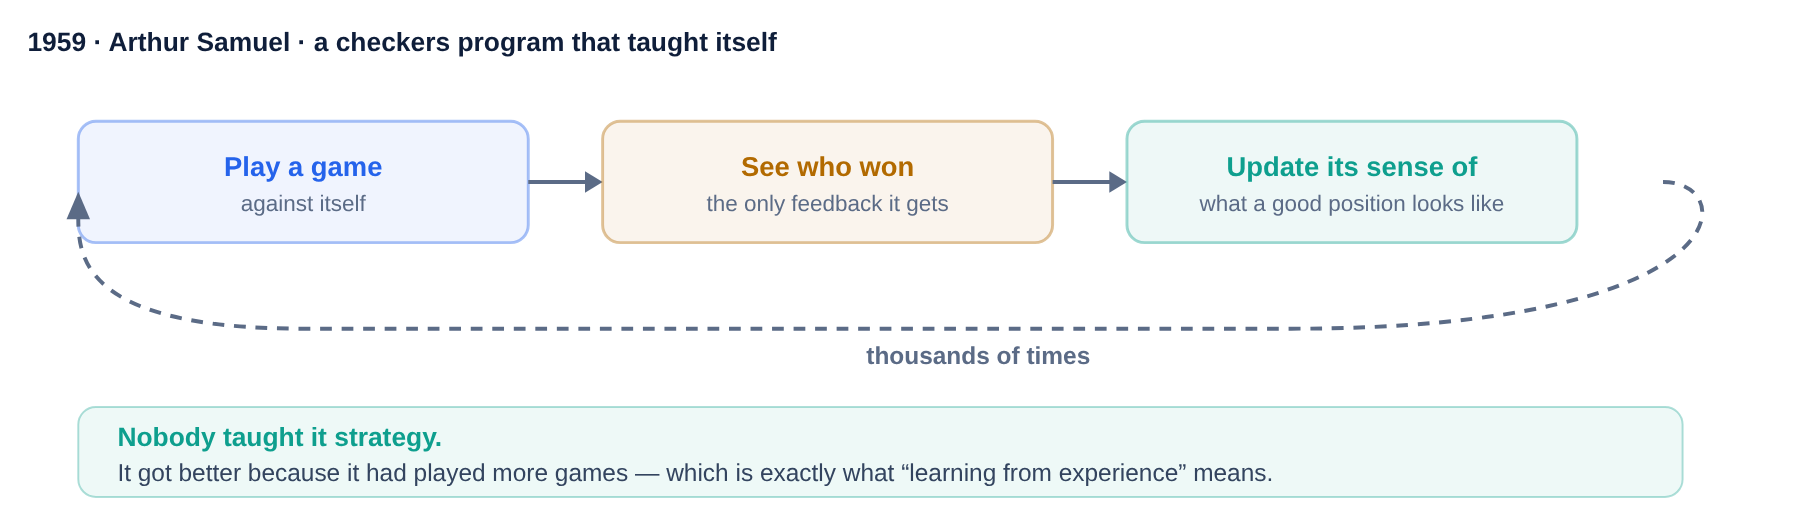

*The first self-learning program, and the loop every machine learner still runs: act, observe, adjust, repeat.*

Every learning method in this chapter runs some version of this loop — the supervised methods of Section 9.3 adjust to labeled examples, the reinforcement learner of Section 9.6 adjusts to rewards, exactly as Samuel's program did.



### 9.1.1 Traditional programming vs. machine learning

*Same problem — a spam filter — solved two ways*

The clearest way to see what is new about machine learning is to put it next to ordinary programming on the same task. Suppose you must build a **spam filter** for an email service.

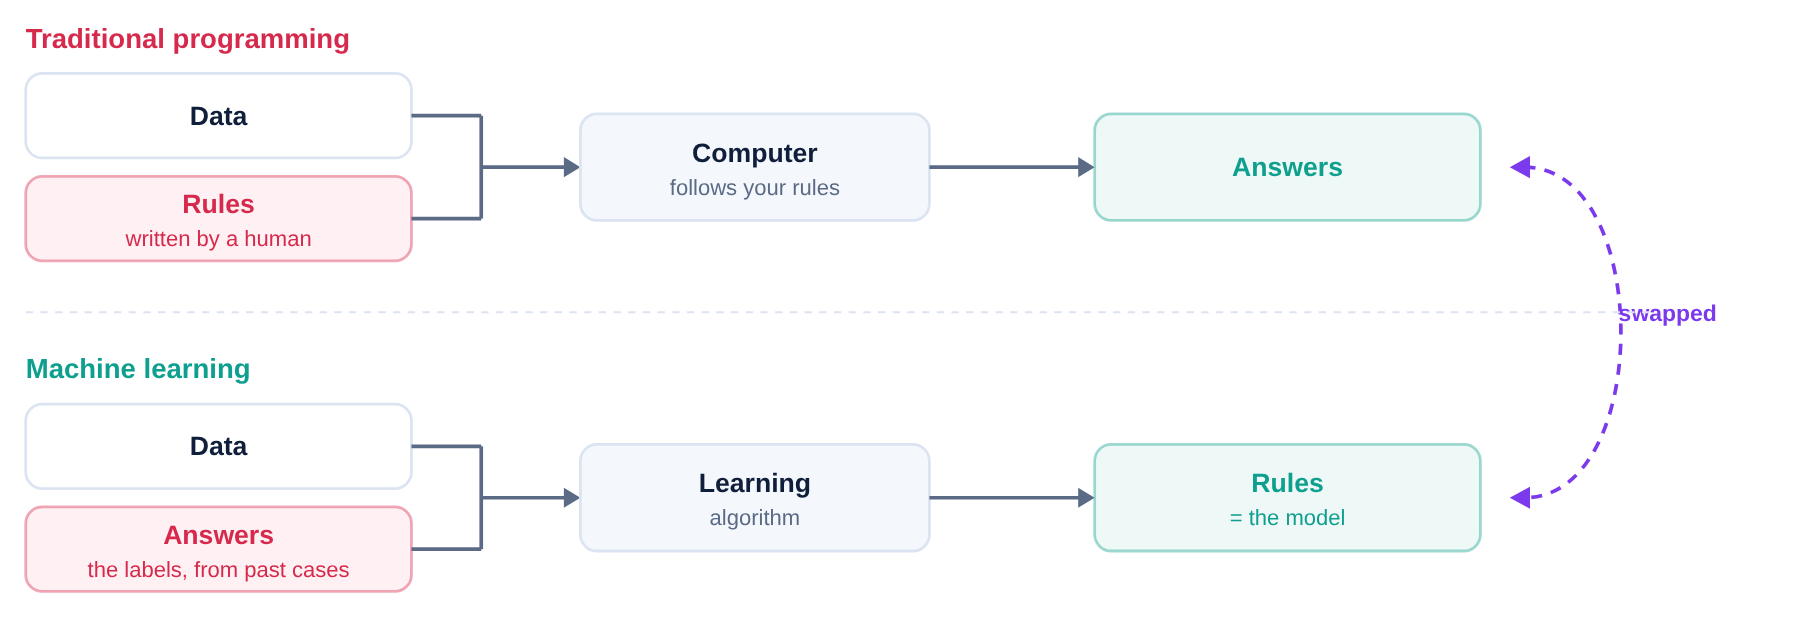

*The same two things change places: what the human hands over, and what comes out the far end. **Rules go in** on the top lane; **rules come out** on the bottom one.*



#### The two approaches, side by side

**The traditional approach**

You write the rules yourself:

```
if subject contains "FREE MONEY":  -> spam
if unknown sender and 5+ links:     -> spam
if body contains "click here":      -> spam
...
```

This works until spammers change one word. `"FREE MONEY"` becomes `"F-R-E-E M0NEY"` and the rule stops firing. You add another rule; they change again. You are in an endless race, hand-writing rules forever.

**The machine learning approach**

You collect a large pile of emails people have already marked “spam” or “not spam”, hand the whole pile to a learning algorithm, and let it work out which patterns of words, senders and link counts separate the two piles. When spammers change tactics you rewrite nothing — you feed in the newer examples and the model updates its own rules.



#### What each side provides

|  | Traditional programming | Machine learning |
|---|---|---|
| **What the human provides** | The rules (the program) | The data (examples, often with the right answer attached) |
| **What the computer provides** | The answers, by following your rules | The rules, by finding patterns in your data |
| **When the world changes** | A human edits the rules | The model is retrained on newer data |
| **Good for** | Problems with clear, stable, writable rules (payroll, tax, sorting) | Problems where the rules are unknown, huge in number, or constantly shifting (spam, faces, speech, recommendations) |

> **This reversed arrangement — *data in, rules out* — is the single idea that everything else in this chapter rests on. The next two subsections show it at work in products you already use.**



### 9.1.2 Machine learning you already use every day

*Four apps you probably opened today*

The spam filter is one of four everyday products built the second way. In each of them, ask the same question: why could the rules not simply have been written down?

- **Netflix** — Its recommendation engine chooses what to put in front of you — over **75% of what people watch on Netflix is picked by the recommender**, not found by browsing or searching. **Why rules fail:** nobody could hand-write a rule for every combination of viewer and title. The engine learns from what millions of similar viewers watched next.
- **Facebook** — **Auto-tagging**: it studies the facial features in an uploaded photo and suggests which of your friends is in it. **Why rules fail:** “what does this person's face look like?” cannot be expressed as a written rule. It is learned from previously tagged photos.
- **Gmail** — **Spam filtering** reads incoming mail in real time and classifies each message as spam or not spam. **Why rules fail:** the arms race of Section 9.1.1 — spammers adapt, so the filter has to keep learning.
- **Voice assistants** — Siri, Alexa and Google Assistant convert your **speech into text**, work out what you asked for, and convert text back into **speech**. **Why rules fail:** every accent, pace and microphone is different. The mapping from sound to words is learned from enormous amounts of recorded speech.



#### Four apps, one pattern

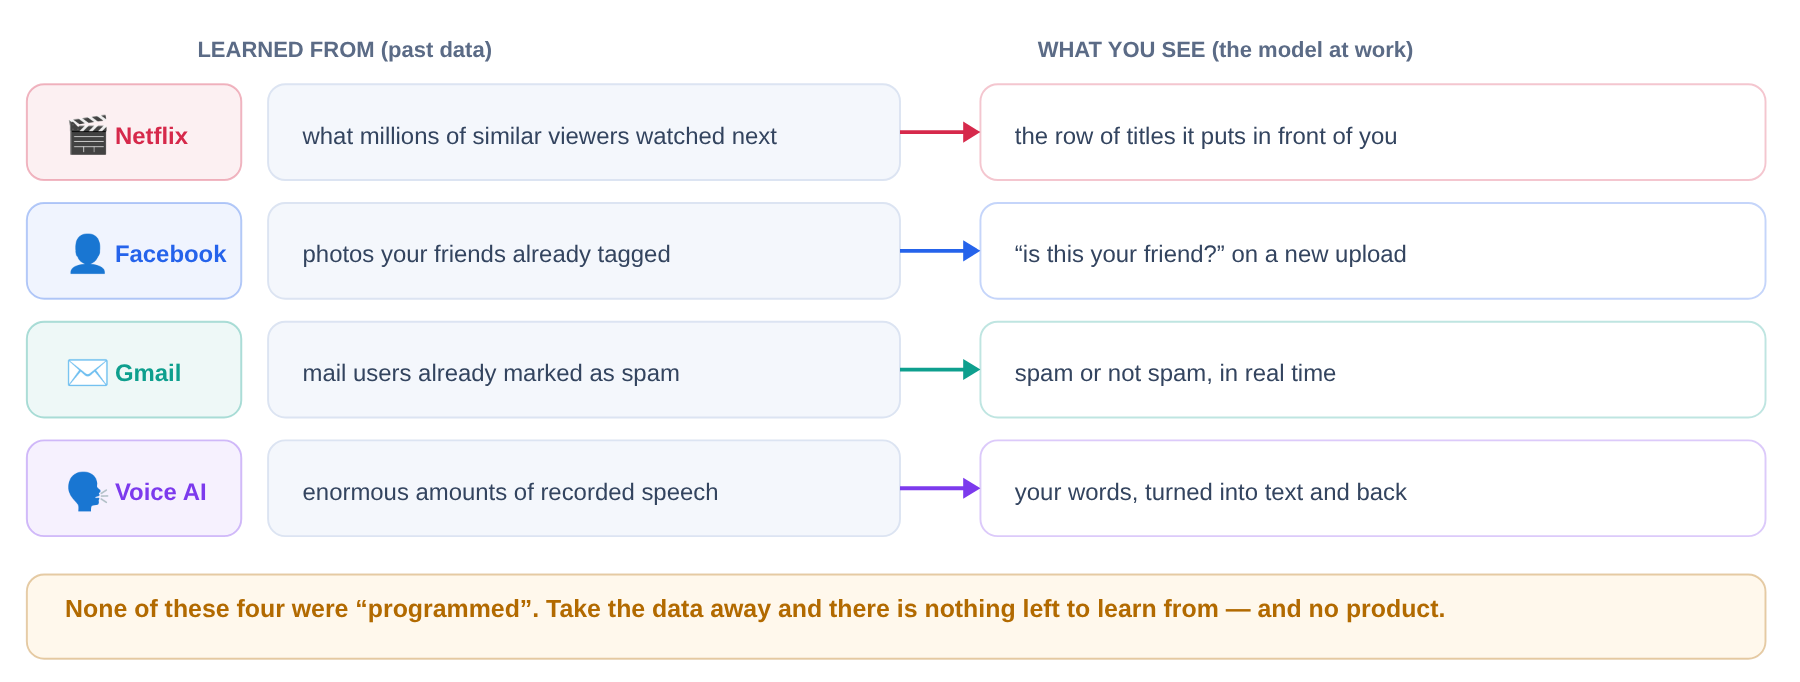

*Every one of them is the same shape: a mountain of past data on the left, learned behavior on the right, and no hand-written rules in between.*

> **The common element.** None of the four is “programmed” in the traditional sense. Each learned its behavior from mountains of past data — viewing history, tagged photos, labeled spam, recorded speech. Take the data away and there is nothing to learn from, and no product.



### 9.1.3 A deeper example — self-driving cars

*The most demanding case: learn and act in real time*

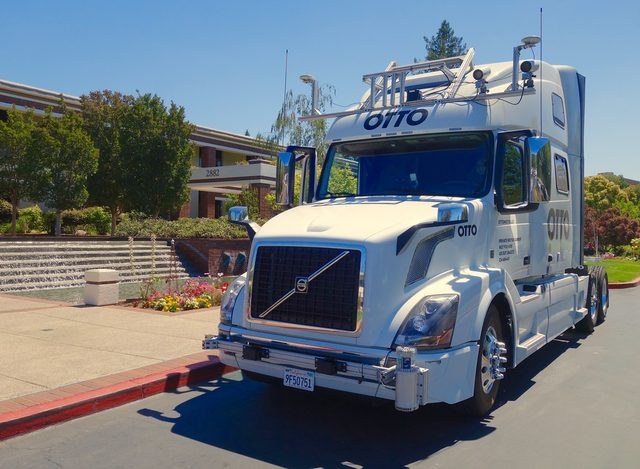

*A self-driving truck. The sensor array on the roof — cameras, radar and lidar — feeds the models described here. — Photo: “Your Uber Otto has arrived” by jurvetson, CC BY — flickr.com*

The four apps above learn from data and then answer a question. A self-driving car does the same, with two differences that make it the hardest case: it must answer many times a second, and a wrong answer is dangerous. The vehicle is covered in sensors — cameras, radar, and **lidar** (a laser range-finder that measures distance by timing reflected light) — which stream data into the car's computer, where models answer two questions over and over:



#### Two questions, many times per second

1. **What is that?** — Is the shape ahead a pedestrian, a cyclist, a parked car, a plastic bag blowing across the road, or a shadow? This is a **classification** problem: pick one label out of a fixed set.
2. **What will it do next?** — Given where that object has been for the last few seconds, where will it be a second from now? This is a **prediction** problem, and its answer decides whether the car brakes, steers, or carries on.

Only after those two answers does the car choose an action.

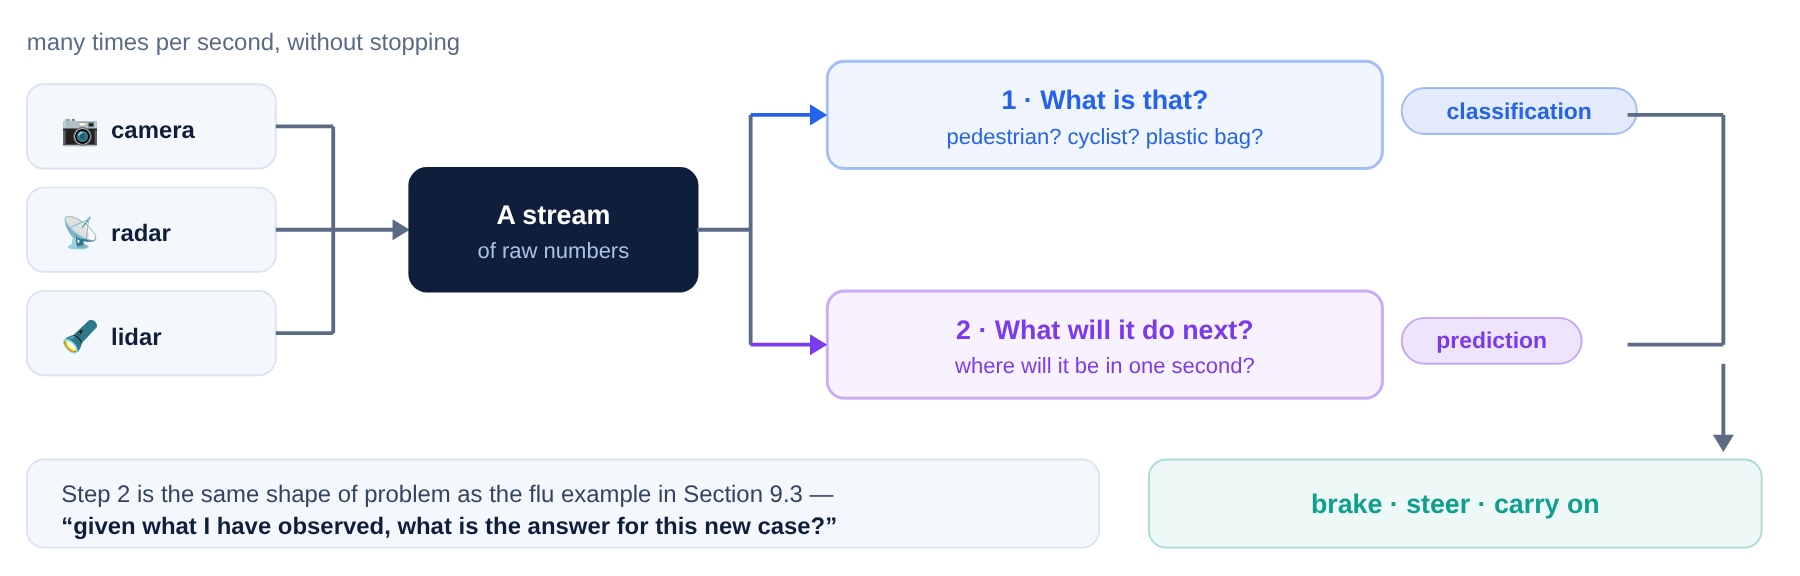

*Only after both questions are answered does the car choose an action. Everything left of the arrow is machine learning; everything right of it is driving.*



#### What Section 9.1 has established

> **Looking ahead.** Machine learning replaces hand-written rules with rules learned from data, and the same idea runs from a 1959 checkers program to a spam filter to a car. Both of the car's questions — “what is this new case?” and “given what I have seen, what comes next?” — are the kind of task **supervised learning** (Section 9.3) is built for. The flu-diagnosis example there is the same kind of problem as “is that a pedestrian?”, small enough to work out by hand. But supervised learning is only one family, and the next section draws the map.

> **Try it.** Arthur Samuel's program taught itself checkers by playing against itself. If you did the same today, which game would you choose, and what would count as the “experience” it learns from? What would make a game *too hard* for this approach?



## 9.2 · Types of machine learning

*Three families — and the one question that tells them apart*

Section 9.1 gave one definition of machine learning. In practice it is done in three quite different ways, and which one applies is decided by a single question about the data you have. This table is the **map for the rest of the chapter**: Sections 9.3, 9.4 and 9.6 each take one row and go deep into it, and Section 9.5 covers the space between the first two.

| Type | Learns from | Goal |
|---|---|---|
| **Supervised learning** | Labeled data (inputs + known answers) | Predictive analysis: classification, regression |
| **Unsupervised learning** | Unlabeled data (inputs only) | Find structure: clustering, association |
| **Reinforcement learning** | Trial and error + reward feedback | Learn a behavior (a policy) from mistakes |



#### The three families

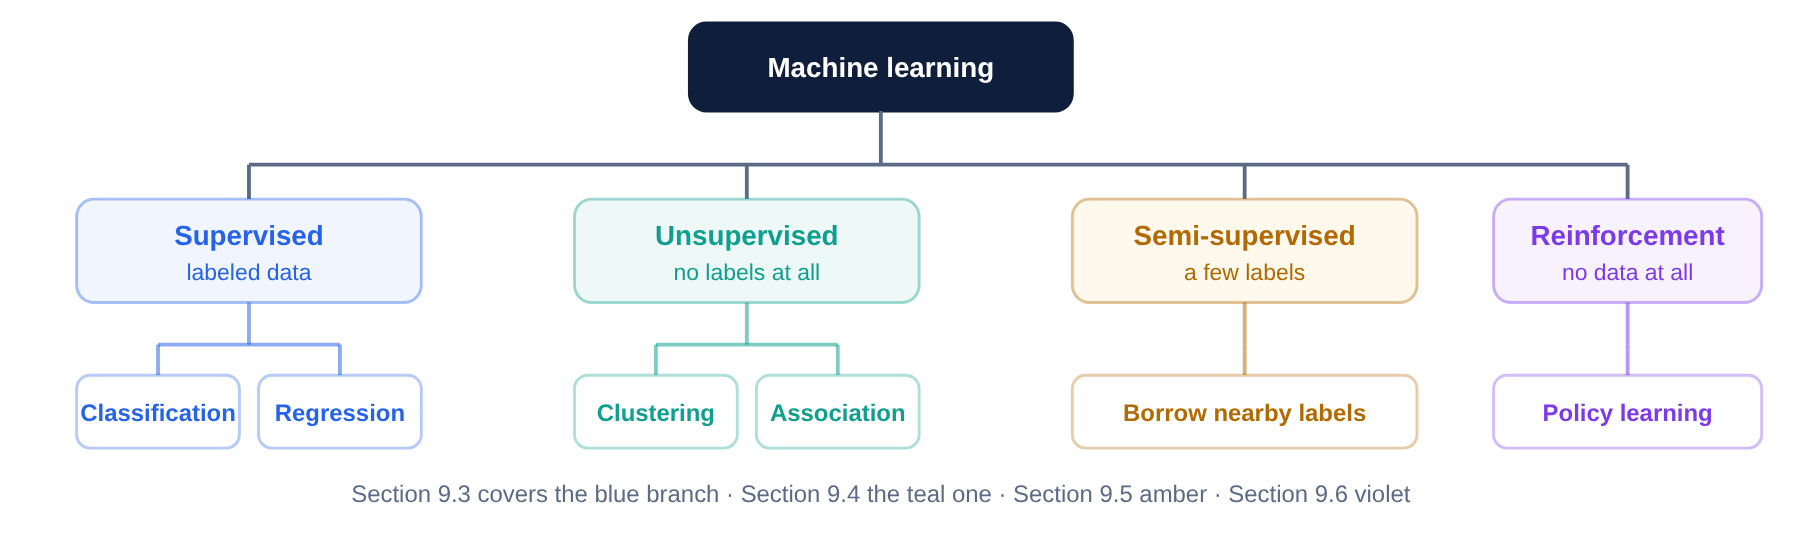

*The map for the rest of the chapter. Every problem you meet in this course sits on one of these four branches.*



#### The question that tells them apart

> **The one question.** What does the data look like? Does each example come with the right answer, with no answer, or is there no dataset at all?

- **Supervised** — Every example comes with the right answer attached. Six patients, and for each one you already know whether they had the flu. The model's job is to reproduce that answer for a *new* patient. The word is literal: it is as if a teacher stood over the model with an answer key.
- **Unsupervised** — You have the examples but **no answers at all**. Sixty customers, and nothing says which “type” each one is. The model's job is to find groupings or patterns that were already in the data, unlabeled.
- **Reinforcement** — There is no dataset to begin with. An **agent** tries something, sees what reward it gets, and tries again. Its job is to learn a *behavior*, not to predict a value.

> **Note.** **Semi-supervised learning** (Section 9.5) is not a fourth family so much as the space between the first two: a small amount of labeled data plus a large amount of unlabeled data. It exists because labeling is expensive — it is easy to collect a million photos and very slow to have a person describe each one.



### 9.2.1 Which type is this problem?

*The most practical skill in this chapter*

Placing a new problem in the right family is the first decision in any project, because it decides which algorithms you are even allowed to reach for. The reasoning is always the same question from above — what does the data look like? — applied to a concrete case:

| Problem | Type | Why |
|---|---|---|
| **Predict a house's selling price from its size, age and location — you have 10,000 past sales with their actual prices** | **Supervised** regression | Every training example carries a known answer (the price it sold for), and the answer is a number. |
| **Decide whether an incoming email is spam — you have 50,000 emails users already marked** | **Supervised** classification | Known answers again, but the answer is one of a fixed set of classes (spam / not spam). |
| **Split 5,000 customers into “types” for a marketing campaign — nobody has ever assigned a type** | **Unsupervised** clustering | There are no correct answers to learn from; you want the groupings already present in the data. |
| **Find which products get bought together in supermarket receipts** | **Unsupervised** association | No labels, and you are looking for *rules* about co-occurrence rather than groups of customers. |
| **Teach a robot arm to pick up an unfamiliar object** | **Reinforcement** | No dataset of correct arm movements exists. The robot tries, sees whether it dropped the object, and adjusts. |
| **Classify 1,000,000 photos when a doctor has had time to label only 200** | **Semi-supervised** | A little labeled data, a lot of unlabeled data — labeling the rest by hand is not realistic. |



#### Placing a problem in its family

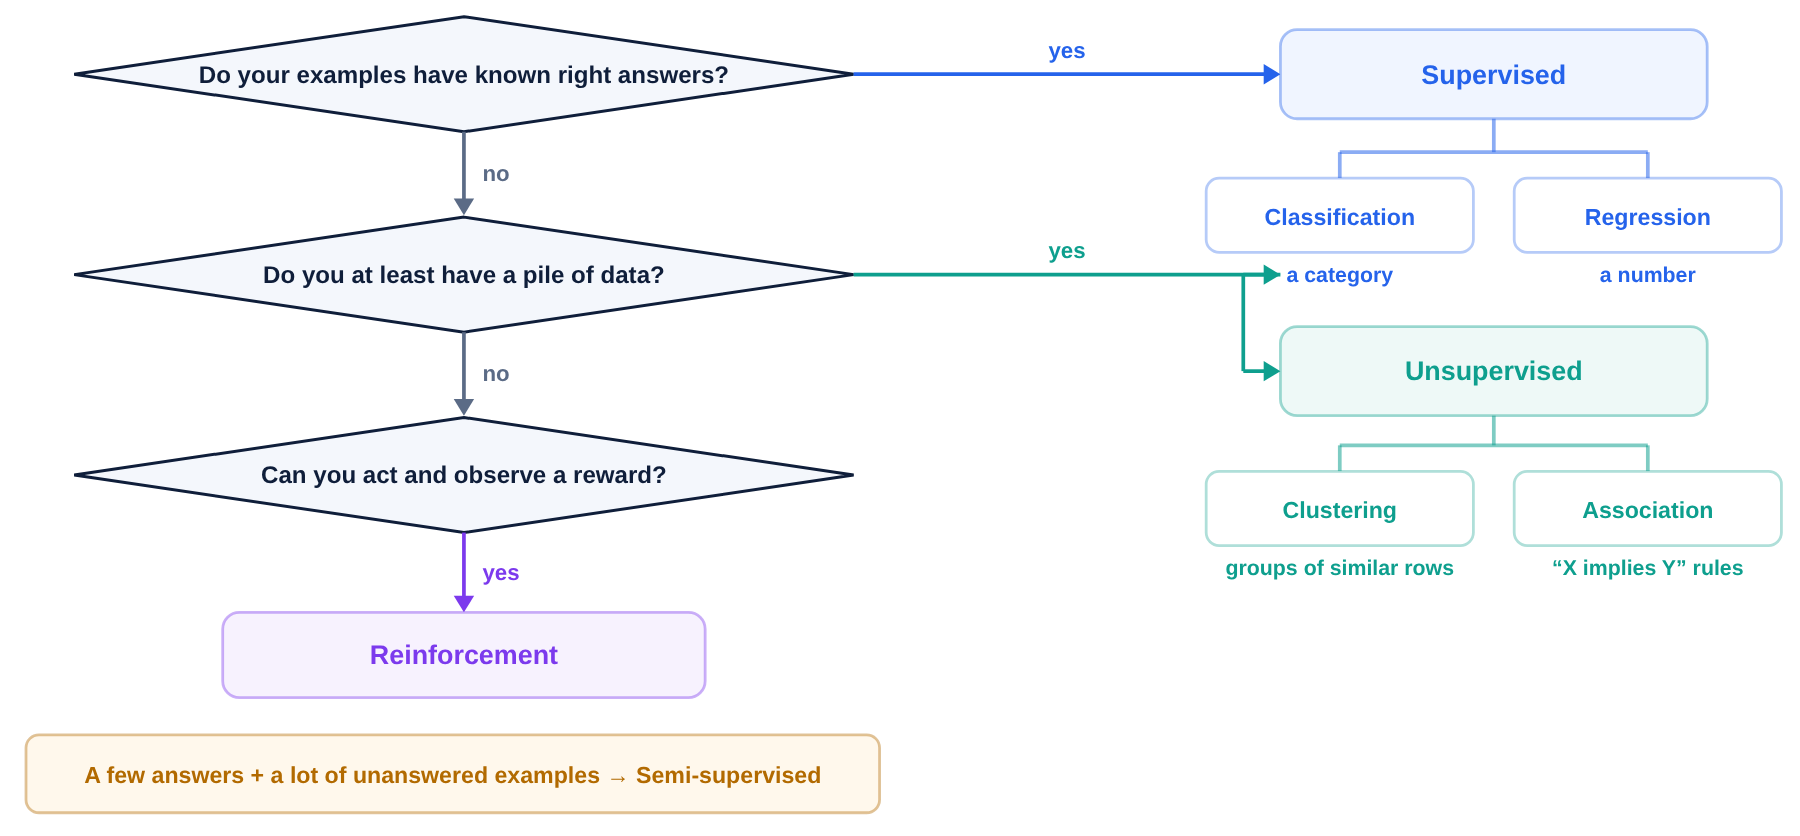

*Follow the arrows from the top. Three questions place any new problem on the right branch — and the branch decides which algorithms you may reach for.*

> **The route through the rest of the chapter.** With the map drawn, the chapter now walks it. Section 9.3 takes the first row — supervised learning — and builds a classifier by hand, then asks how to tell whether it is any good. Section 9.4 removes the labels. Section 9.6 removes the dataset.



## 9.3 · Supervised learning

*Learning from examples that come with the answer attached*

The first row of the map in Section 9.2 is the family with labeled data: every example carries the right answer. This section builds a complete supervised learner by hand — a small table of patients, a rule that classifies a new one, and then the harder question of how to tell whether that rule is any good. The ideas introduced here (training and test data, overfitting, cross-validation, the confusion matrix) are used for every algorithm in Chapter 10.

> **Definition.** Supervised learning is guided by known outcomes: you show the model labeled examples (inputs *and* the correct answer), and it learns a **target function** that predicts the label for *new*, unseen inputs.

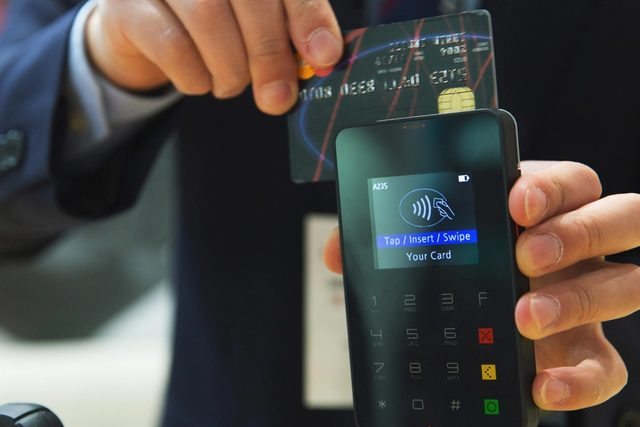

*A card payment is approved or declined in under a second by a classifier trained on millions of past transactions, each labeled genuine or fraudulent — supervised learning at work. — Photo: “Credit card payment, shopping” — CC0, rawpixel.com*



#### The two tasks of supervised learning

*and the order in which they are treated here*

**Classification — a discrete class**

Flu / No flu  ·  approved / not approved  ·  S / M / L.

Treated in Sections 9.3.1 to 9.3.5, using one example developed throughout.

**Regression — a continuous value**

a price  ·  a temperature  ·  an exam score.

Set out in Section 9.3.6 and developed in Chapter 10.

> **What this section covers, and in what order.** Both are learned the same way, from labeled examples, and everything said below about training, testing and overfitting applies to both. They differ only in the kind of answer they give: a class, or a number. Classification comes first because its simplest method can be worked through by hand, so you can see how labeled examples turn into a prediction before any algorithm is named.



#### Five terms used throughout the course

| Term | What it means | In the flu example |
|---|---|---|
| **Attribute feature, input variable** | One measured property of an example — one column of the table | temperature, cough, sore throat, sinus pain |
| **Label class, target, output variable** | The answer you want to predict — the extra column | “Flu” or “No flu” |
| **Training set** | The labeled examples the model is allowed to learn from | the 6 patients in the table below |
| **Model** | The rule the algorithm ends up with, learned from the training set | “copy the label of the most similar patient” |
| **Prediction** | The model's answer for a new, unlabeled example | “this new patient has the flu” |

> **The example this section builds on.** Newly admitted patients are measured on four variables — temperature, cough, sore throat, sinus pain — and for six past patients the diagnosis is known. **Problem:** predict whether a new patient has the flu.



#### The supervised pipeline

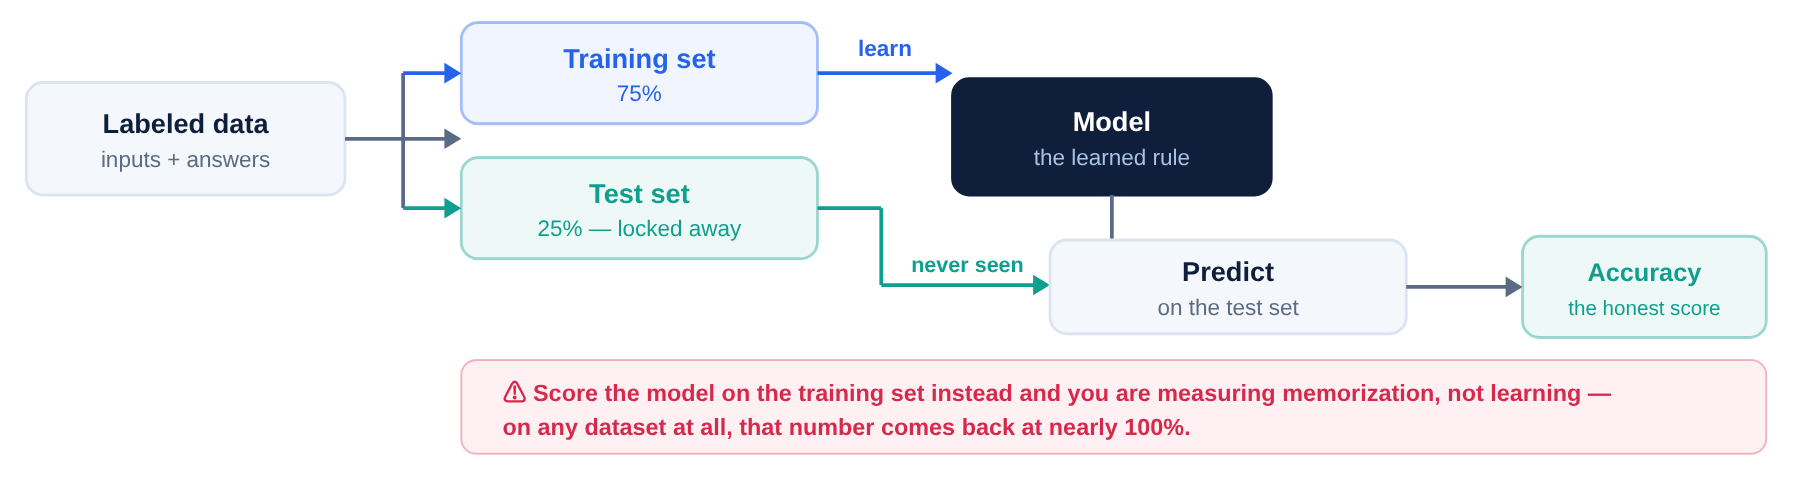

*The whole of supervised learning in one line. The split happens **before** any learning, and the test set is opened exactly once, at the end.*

Two things in this picture will matter more than they look: the split happens *before* any learning, and the test set is opened exactly once, at the end. Section 9.3.2 explains why.



#### The training data

The six past patients go into a pandas table, one row per patient and one column per attribute, with the known diagnosis as the last column. The table is written as a dictionary — each column name paired with its list of values — and the row labels are set to the patient numbers so the rows can be referred to by name later. This table is the training set for everything in Section 9.3.1.



> **Interpretation.** Each row is a labeled example: four **attributes** (temperature, cough, sore throat, sinus pain) plus a known **class** (Flu / No flu). It is the data matrix of Chapter 2 with one extra column — the label to be predicted. Notice that no single column separates the classes: patient 3 has a temperature of 38.4 and no flu, patient 5 has 38.5 and does. A rule has to use the columns together, which is what Section 9.3.1 builds.



In [2]:
flu_data = pd.DataFrame({
    "temperature": [37.0, 39.0, 38.4, 36.8, 38.5, 39.2],
    "cough": ["yes", "no", "no", "no", "yes", "no"],
    "sore_throat": ["no", "yes", "no", "yes", "no", "no"],
    "sinus_pain": ["no", "yes", "no", "no", "yes", "yes"],
    "class": ["No flu", "Flu", "No flu", "No flu", "Flu", "Flu"],
}, index=[1, 2, 3, 4, 5, 6])
flu_data.index.name = "patient"
flu_data

,temperature,cough,sore_throat,sinus_pain,class
patient,,,,,
1,37.0,yes,no,no,No flu
2,39.0,no,yes,yes,Flu
3,38.4,no,no,no,No flu
4,36.8,no,yes,no,No flu
5,38.5,yes,no,yes,Flu
6,39.2,no,no,yes,Flu


### 9.3.1 A first classifier — nearest neighbor

*Find the most similar patient, copy their label*

> **Rationale.** Labeled examples on their own do not give a prediction for a new case. A rule is needed that turns one into the other, and building that rule is what supervised learning does. Any such rule is a classifier. The nearest-neighbor rule is taken as the first example on four grounds:
>
> - It needs no new mathematics: nothing to fit, nothing to minimize, no equations to solve.
> - It has no training step. The model is the stored examples themselves, which makes the difference between training and test data in Section 9.3.2 easy to see rather than something to take on trust.
> - Every number it produces can be worked out by hand and checked against the code.
> - It is a standard method — **k-nearest-neighbors**, one of the classification algorithms listed in Section 9.3.7 — not something invented for teaching.

For a new patient, find the **most similar** patient already in the training data and copy their label. The new patient to classify has temperature 38.9, cough = no, sore throat = yes, sinus pain = yes.



#### The nearest neighbor

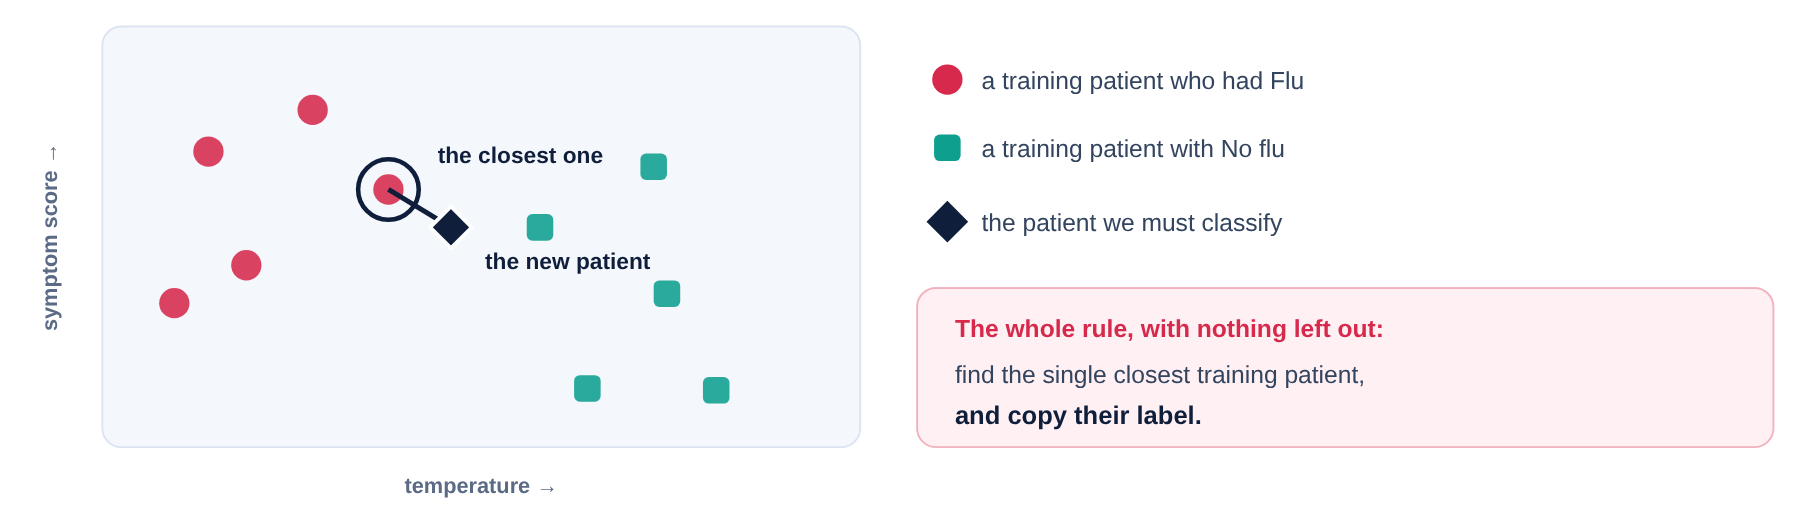

*The model is not an equation — it is this picture. Everything Section 9.3.1 does is measure which point is nearest and read off its color.*

> **About the two axes in these pictures.** A picture needs two numbers per patient, and the table has one number (temperature) plus three yes/no symptoms. So the patients in the pictures of this section are placed by temperature and by a **symptom score**: a single number standing for how many symptoms the patient has and how severe they are, with 0 meaning none. It is not a column of the table — it is a summary of the symptom columns, used only so the idea can be drawn. The pictures also show more patients than the table, because six points are too few to see a pattern in. The hand calculation below uses the six real rows.



#### “Similar” as a number — the distance function

*the one ingredient the rule needs*

“Most similar” has to become a number before a computer can use it. A **distance function** $d(\mathbf{x}, \mathbf{z})$ takes two rows and hands back one number: small when they are alike, large when they are not. Writing a record with $p$ columns as $\mathbf{x} = (x_1, x_2, \dots, x_p)$, the two everyday choices for numeric data are:

$$d_{\text{Euclidean}}(\mathbf{x}, \mathbf{z}) = \sqrt{\sum_{j=1}^{p} (x_j - z_j)^2}\qquad\qquad d_{\text{Manhattan}}(\mathbf{x}, \mathbf{z}) = \sum_{j=1}^{p} \lvert x_j - z_j \rvert$$

Both say: *go through the columns one at a time, see how far apart the two records are in that column, and combine those gaps into a single number.* Euclidean squares each gap, adds them and takes the square root — the straight-line distance you would measure with a ruler. Manhattan adds the gaps up — the distance you walk in a city, along the streets, because you cannot cut through the buildings.

> **Worked example.** Two shops on a map: $\mathbf{x} = (2, 3)$ and $\mathbf{z} = (5, 7)$. The gaps are $5 - 2 = 3$ across and $7 - 3 = 4$ up.
>
> - **Euclidean:** $\sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = \mathbf{5}$ — the direct flight.
> - **Manhattan:** $\lvert 3 \rvert + \lvert 4 \rvert = 3 + 4 = \mathbf{7}$ — three blocks across, four blocks up.
>
> The Manhattan answer is larger, and it always is, because walking around corners can never be shorter than flying straight.



#### Two distance metrics

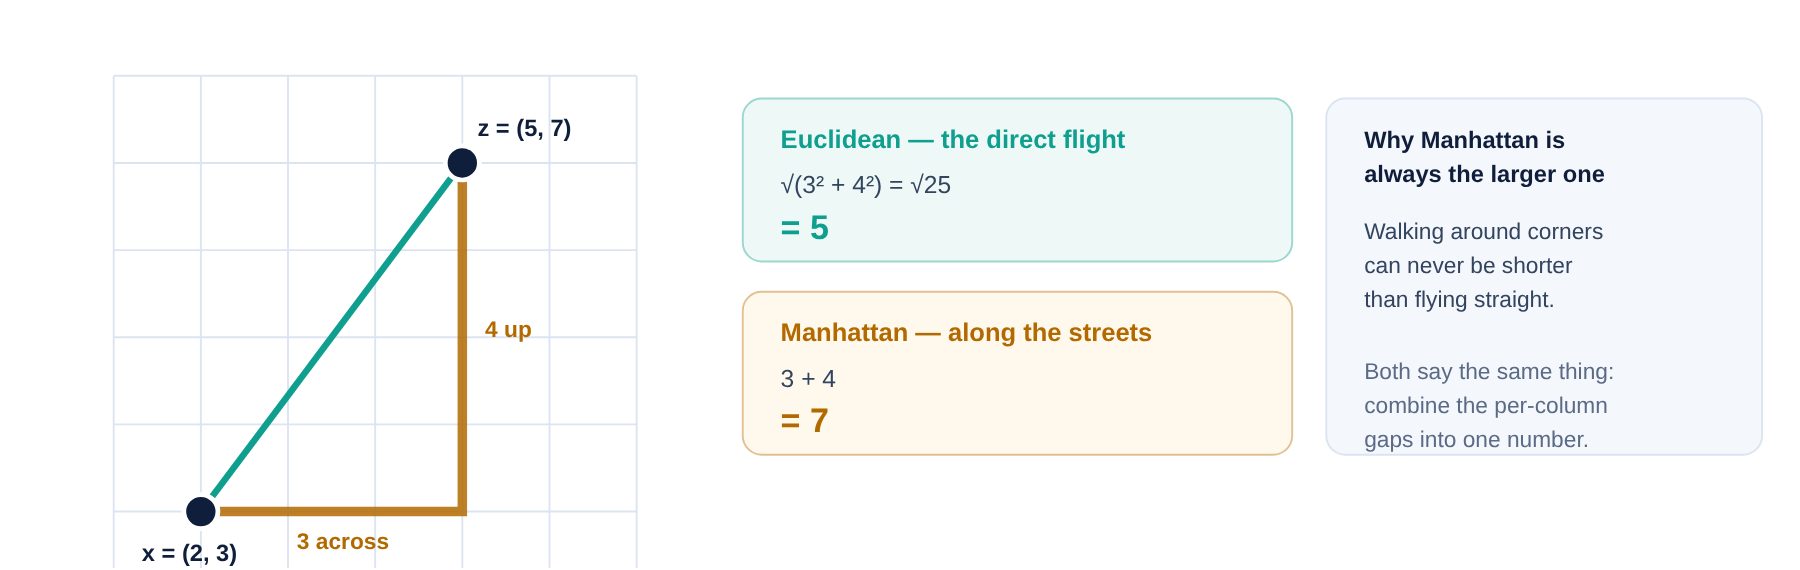

*Two ways to turn “how far apart are these two records?” into a single number. The gaps are identical; only how you combine them differs.*



#### A distance for mixed attribute types

*the one this section uses*

The flu table has one numeric column and three yes/no columns, so neither formula fits as written. The distance used here adds the temperature gap to a count of disagreements:

$$d(\mathbf{x}, \mathbf{z}) = \underbrace{\lvert x_{\text{temp}} - z_{\text{temp}} \rvert}_{\text{the number column}}\;+\; \underbrace{\sum_{j \in \text{symptoms}} \mathbf{1}\!\left[x_j \neq z_j\right]}_{\text{the yes/no columns}}$$

The symbol $\mathbf{1}[\,\cdot\,]$ equals $1$ when the statement inside is true and $0$ when it is false, so the sum is *how many symptoms the two patients disagree on*. A patient whose temperature is 0.5° away and who disagrees on one symptom is at distance $0.5 + 1 = 1.5$.

**Worked example.** **Patient 5** is temperature $38.5$, cough **yes**, sore throat **no**, sinus pain **yes**. The new patient is $38.9$, cough **no**, sore throat **yes**, sinus pain **yes**.

| Part | Comparison | Contributes |
|:--|:--|--:|
| **Temperature** | $\lvert 38.5 - 38.9 \rvert = 0.4$ | $0.4$ |
| **Cough** | yes vs. no → they differ | $1$ |
| **Sore throat** | no vs. yes → they differ | $1$ |
| **Sinus pain** | yes vs. yes → they agree | $0$ |

Total: $0.4 + 1 + 1 + 0 = \mathbf{2.4}$. The table below does this for all six patients.



#### Every training patient

*The worked example*

With the distance defined, the whole rule is three steps: compute the distance from the new patient to each of the six, rank them, take the smallest. Here is the first step for all six rows. The new patient is temperature **38.9**, cough **no**, sore throat **yes**, sinus pain **yes**.

| Patient | Temperature part | Cough | Sore throat | Sinus pain | Total | Class |
|:-:|:--|:--|:--|:--|--:|:--|
| **1** | \|37.0 − 38.9\| = 1.9 | yes ≠ no → +1 | no ≠ yes → +1 | no ≠ yes → +1 | **4.9** | No flu |
| **2** | \|39.0 − 38.9\| = 0.1 | no = no → +0 | yes = yes → +0 | yes = yes → +0 | **0.1** | **Flu** |
| **3** | \|38.4 − 38.9\| = 0.5 | no = no → +0 | no ≠ yes → +1 | no ≠ yes → +1 | **2.5** | No flu |
| **4** | \|36.8 − 38.9\| = 2.1 | no = no → +0 | yes = yes → +0 | no ≠ yes → +1 | **3.1** | No flu |
| **5** | \|38.5 − 38.9\| = 0.4 | yes ≠ no → +1 | no ≠ yes → +1 | yes = yes → +0 | **2.4** | **Flu** |
| **6** | \|39.2 − 38.9\| = 0.3 | no = no → +0 | no ≠ yes → +1 | yes = yes → +0 | **1.3** | **Flu** |



#### The ranking

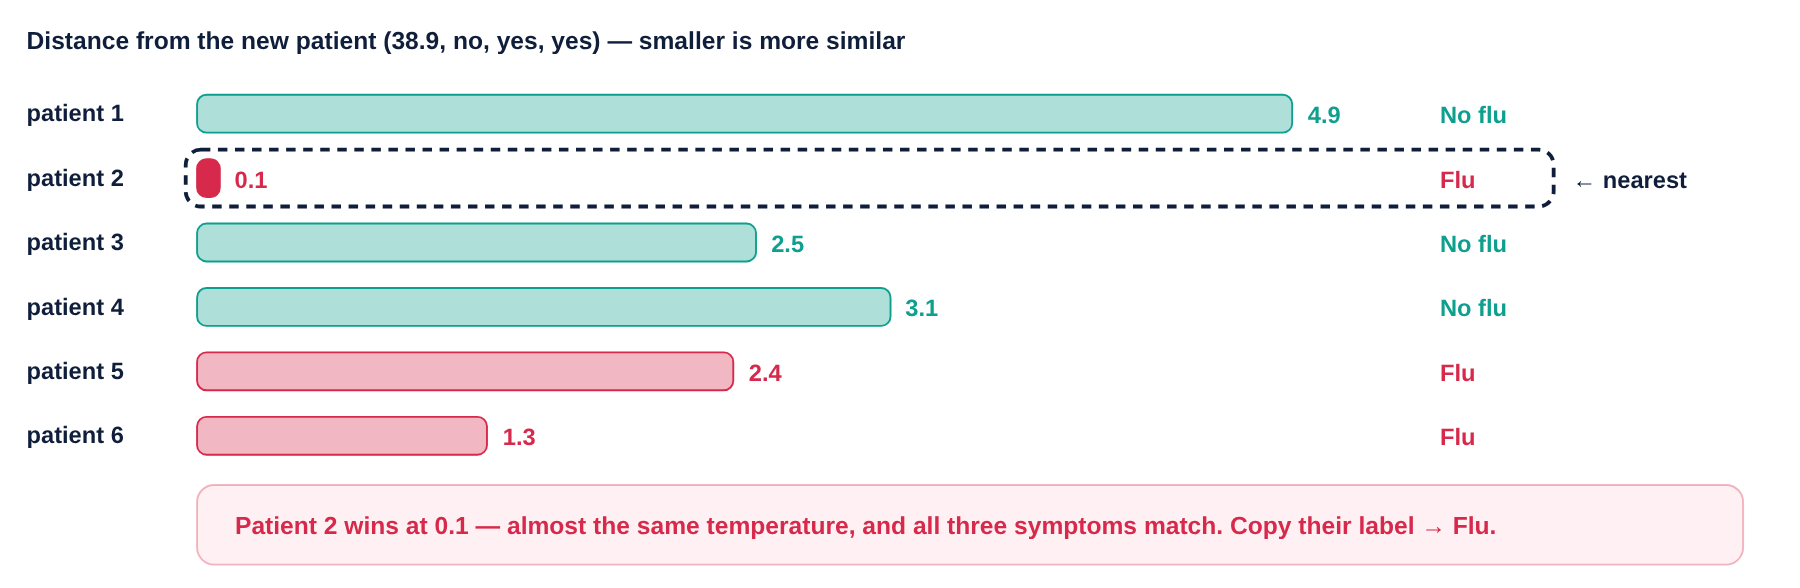

*The whole algorithm, as one picture: measure six distances, take the shortest bar, copy that patient's answer.*

Patient 2 is nearest, at distance **0.1**: almost the same temperature and all three symptoms the same. Its label is copied.

> **Prediction for the new patient → Flu**

That is the entire algorithm. The cells that follow do exactly these steps in code, so every number Python prints can be checked against the table.



#### The steps

*What the cells below do*

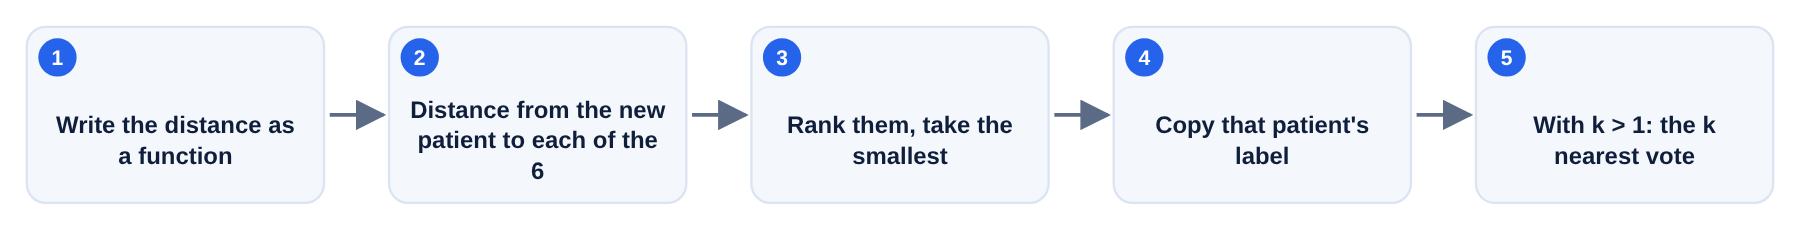

*The nearest-neighbor rule in five steps. The cells that follow carry out one step each.*



#### The distance function

The hand calculation is now repeated in Python, one step per cell, starting with the distance. A function is a named block of code that takes inputs and returns an answer; this one, `flu_distance`, takes one training patient (a row of the table) and the new patient's four values, and returns the single number defined by the formula shown here. The line in triple quotes is a docstring — a short description of what the function does.

$$d(\mathbf{x}, \mathbf{z}) = \lvert x_{\text{temp}} - z_{\text{temp}} \rvert\;+\; \sum_{j \in \text{symptoms}} \mathbf{1}\!\left[x_j \neq z_j\right]$$

The first term is the temperature gap; the sum counts the symptoms that disagree.



In [3]:
def flu_distance(row, temperature, cough, sore_throat, sinus_pain):
    """Temperature gap, plus 1 for each symptom that disagrees."""
    dist = abs(row["temperature"] - temperature)          # abs() drops the minus sign
    # a comparison such as row["cough"] != cough gives True or False; True counts as 1 when added,
    # so the three comparisons add up to the number of symptoms that disagree
    dist += (row["cough"] != cough) + (row["sore_throat"] != sore_throat) + (row["sinus_pain"] != sinus_pain)
    return dist

#### All six distances at once

The new patient's values are stored as a dictionary, so each value has a name. Then `.apply(flu_distance, axis=1, ...)` calls the function once for every row of the table (`axis=1` means row by row) and collects the six answers; `**new_patient` unpacks the dictionary into the function's other inputs — the same as writing `temperature=38.9, cough="no", ...` by hand.



> **Interpretation.** Six distances, one per training patient, and they are exactly the totals in the hand-computed table: 4.9, 0.1, 2.5, 3.1, 2.4, 1.3. That agreement is the point of working the example by hand first — the computer's answer can be checked line by line.



In [4]:
new_patient = dict(temperature=38.9, cough="no", sore_throat="yes", sinus_pain="yes")
distances = flu_data.apply(flu_distance, axis=1, **new_patient)
distances.name = "distance_to_new_patient"
distances

patient
1    4.9
2    0.1
3    2.5
4    3.1
5    2.4
6    1.3
Name: distance_to_new_patient, dtype: float64

#### The nearest patient and its label

Ranking the six and taking the smallest is one call: `.idxmin()` returns the *label* of the row holding the smallest value — the patient number, not the distance — and that patient's class is read off the table. The class is the prediction, and it should match the takeaway above.



> **Interpretation.** The new patient's symptoms are closest to patient 2, and patient 2's label — Flu — is copied. This is the whole idea behind the **k-nearest-neighbors** classifier, one of the named algorithms in Section 9.3.7, done here with a single neighbor and a hand-written distance. The next step asks whether one neighbor is enough.



In [5]:
nearest_patient = int(distances.idxmin())
print("nearest patient:", nearest_patient)
print("its class, copied as the prediction:", flu_data.loc[nearest_patient, "class"])

nearest patient: 2
its class, copied as the prediction: Flu


#### The parameter k

> **One neighbor is fragile.** The rule so far uses **k = 1**: consult the single closest patient and copy their answer. That is fragile — if the one closest example happens to be unusual, or was recorded wrongly, the prediction goes with it. The standard fix is to consult the **k closest** examples and let them **vote**.

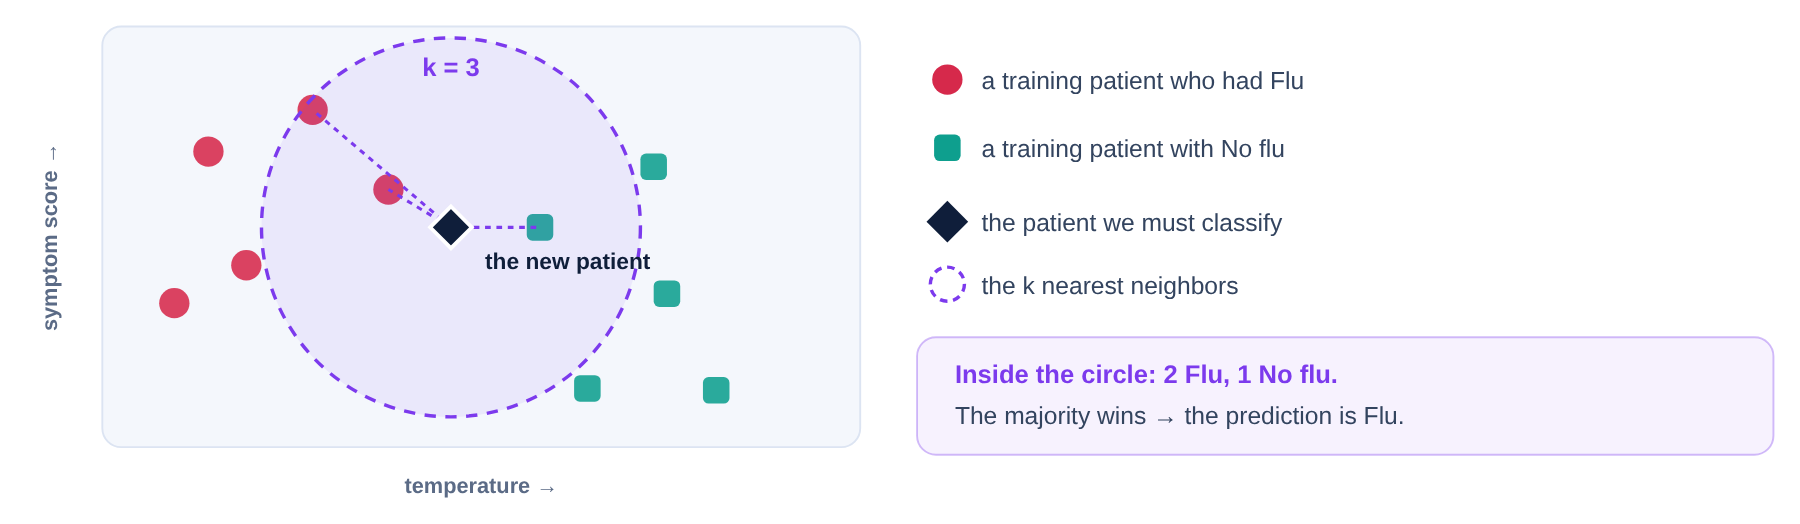

*The same patients and the same two axes as the Section 9.3.1 picture, now with **k = 3**. Instead of copying one neighbor, the three closest vote — which is what stops a single odd example from deciding the answer on its own.*



#### The classifier in general

Let $N_k(\mathbf{x})$ mean “the $k$ training patients closest to $\mathbf{x}$”. The prediction is whichever label most of them carry:

$$\hat{y}(\mathbf{x}) = \arg\max_{c \,\in\, \text{classes}} \sum_{i \,\in\, N_k(\mathbf{x})} \mathbf{1}\!\left[y_i = c\right]$$

In words: *for each possible answer $c$, count how many of the $k$ neighbors carry that answer, and go with the winner.* $\arg\max$ means “the option with the biggest count”, not the count itself. With $k = 1$ this is the rule already used.

> **Worked example.** **The same table, with $k = 3$.** Sorting the six distances gives $0.1$ (patient 2, **Flu**), $1.3$ (patient 6, **Flu**), $2.4$ (patient 5, **Flu**), then $2.5$, $3.1$, $4.9$.
>
> - The three nearest are patients 2, 6 and 5. Counting labels: **Flu** gets $1+1+1 = 3$ votes, **No flu** gets $0$. So $\hat{y} = $ **Flu**.
> - With $k = 5$ the five nearest are patients 2, 6, 5, 3, 4 → **Flu** $3$ votes, **No flu** $2$. Still **Flu**, but 3–2 rather than 3–0. That narrowing is what the decision-boundary picture at the end of this section shows.



#### Three neighbors, and their votes

The vote is now built in code. `.nsmallest(3)` keeps the three smallest distances *with their row labels*; the three patient numbers are used to look up the class of each nearest neighbor — these labels are the votes — and `.value_counts()` tallies how many said Flu and how many said No flu, the $\sum \mathbf{1}[y_i = c]$ of the formula, one count per class.



In [6]:
k = 3
nearest_three = distances.nsmallest(k)
votes = flu_data.loc[nearest_three.index, "class"]
print(nearest_three.to_string(), "\n")
print(votes.to_string(), "\n")
tally = votes.value_counts()
tally

patient
2    0.1
6    1.3
5    2.4 

patient
2    Flu
6    Flu
5    Flu 



class
Flu    3
Name: count, dtype: int64

#### The majority verdict

`.idxmax()` returns the label with the largest count — the $\arg\max$ — which is the prediction for k = 3. It is the mirror image of the `.idxmin()` used to find the nearest patient.

$$\hat{y}(\mathbf{x}) = \arg\max_{c \,\in\, \text{classes}} \sum_{i \,\in\, N_k(\mathbf{x})} \mathbf{1}\!\left[y_i = c\right]$$

The tally is the sum; `.idxmax()` is the arg max.



> **Interpretation.** All three nearest patients are flu cases, so the vote is unanimous and k = 3 agrees with k = 1. When the neighbors disagree, the majority wins, which is what makes a larger k robust to one odd example. Choosing k is a real decision: too small and a single strange example can swing the prediction; too large and the vote starts including patients who are not similar at all. In practice several values of k are tried and the one that scores best on **test** data is kept — which is what Section 9.3.2 is about. First, the effect of k is made visible.



In [7]:
tally.idxmax()

'Flu'

#### A caution on attribute scale

> **Distance adds columns together.** The distance used here adds degrees Celsius to yes/no disagreements as if they were the same unit. A temperature gap between patients is usually below 2 while each mismatched symptom costs a full 1, so the symptoms carry most of the weight. The effect is general: because distance adds columns together, a column measured in big numbers drowns out a column measured in small ones. If temperature were recorded in millidegrees, $\lvert 38500 - 38900 \rvert = 400$ would swamp the symptom counts of 1 and the symptoms would stop affecting the answer at all; annual income in baht would decide the “nearest” neighbor on its own. Numeric columns are therefore usually **standardized** first — replaced by $z = (x - \bar{x}) / s$, the number of standard deviations from the column's own average — so that every column speaks the same units. Rescaling attributes to comparable ranges is also called **normalization**, and it is a standard step before any distance-based algorithm. The classifier in the next cells does it.



#### The effect of k

*The decision boundary*

k controls how much the classifier is willing to trust a single neighbor, and the effect is easiest to *see*. Six patients are too few for a picture, so the next cells build a larger simulated set — 120 patients described by temperature and the symptom score from the pictures above — with a few wrong labels mixed in, as real data always has. Then the classifier is asked for its answer at every point of the plane, for three values of k, and the answers are colored in. The colored picture is the classifier's **decision boundary**.



#### 120 simulated patients

A fresh generator `rng_knn` is seeded so the picture comes out the same for everyone. Sixty healthy patients are drawn from a bell curve around 37.2 °C with a low symptom score, sixty ill ones around 38.6 °C with a higher score (`np.column_stack` puts the two columns side by side, one row per patient), and the two groups are stacked into one array `X` of 120 rows. `y` records which group each row came from — 0 for healthy, 1 for ill — and is kept separately, because the classifier will only ever see `X`. The two clouds overlap on purpose: if they separated cleanly, every k would give the same answer.



In [8]:
rng_knn = np.random.default_rng(888102)
n_each = 60
healthy = np.column_stack([rng_knn.normal(37.2, 0.45, n_each), rng_knn.normal(2.0, 1.1, n_each)])
sick = np.column_stack([rng_knn.normal(38.6, 0.55, n_each), rng_knn.normal(5.0, 1.3, n_each)])
X = np.vstack([healthy, sick])                      # 120 rows, 2 columns: temperature, symptom score
y = np.r_[np.zeros(n_each), np.ones(n_each)]        # the truth: sixty 0s, then sixty 1s
print("first three healthy patients:\n", healthy[:3].round(2))
print("first three ill patients:\n", sick[:3].round(2))
print("X:", X.shape, "  y:", y.shape, "  ill patients:", int(y.sum()))

first three healthy patients:
 [[37.45  1.98]
 [37.67  0.73]
 [37.5   2.21]]
first three ill patients:
 [[38.87  3.94]
 [37.92  4.88]
 [38.48  4.61]]
X: (120, 2)   y: (120,)   ill patients: 60


#### Eight labels recorded wrongly

Real data always contains some wrong labels, and they are what make the choice of k matter. Eight row numbers are picked at random and their labels flipped — `1 - y` turns 0 into 1 and 1 into 0 — so the count of ill patients is no longer exactly 60.



In [9]:
noise_idx = rng_knn.choice(len(y), 8, replace=False)
y[noise_idx] = 1 - y[noise_idx]
print("rows flipped:", np.sort(noise_idx))
print("ill patients now:", int(y.sum()))

rows flipped: [15 23 26 36 38 77 82 97]
ill patients now: 62


#### A k-nearest-neighbors classifier for many patients at once

This function is the Section 9.3.1 rule written for a whole batch of query points. It first standardizes both columns, as the caution above requires, so temperature and symptom score contribute comparably. It then measures the distance from every query point to every training point, takes the k nearest, and lets them vote: a mean label of 0.5 or more means the majority said ill.

$$z = \frac{x - \bar{x}}{s}$$

Standardization, applied to each column before any distance is measured.



In [10]:
def knn_predict(train_X, train_y, query, k):
    mu, sigma = train_X.mean(axis=0), train_X.std(axis=0)     # standardize both columns
    scaled_train = (train_X - mu) / sigma
    scaled_query = (query - mu) / sigma
    distances = np.linalg.norm(scaled_train[None, :, :] - scaled_query[:, None, :], axis=2)
    nearest = np.argsort(distances, axis=1)[:, :k]              # the k closest training rows
    return (train_y[nearest].mean(axis=1) >= 0.5).astype(int)   # majority vote

#### A grid of imaginary patients

To color the whole plane, the classifier has to answer for every point in it, not only the 120 real patients. `np.meshgrid` lays a 220 × 220 grid over the range of temperatures and symptom scores — 48,400 imaginary patients — and the two grids are flattened into a two-column array, one row per imaginary patient, the shape `knn_predict` expects. The first three rows are shown.



In [11]:
grid_t, grid_s = np.meshgrid(np.linspace(35.5, 40.5, 220), np.linspace(-2, 9, 220))
grid = np.column_stack([grid_t.ravel(), grid_s.ravel()])
print("grid:", grid.shape)
grid[:3].round(2)

grid: (48400, 2)


array([[35.5 , -2.  ],
       [35.52, -2.  ],
       [35.55, -2.  ]])

#### Three values of k

Everything is in place. For k = 1, 15 and 101 the classifier answers for every grid point; each answer colors its point, and the real patients are drawn on top. The border between the two colors is the model.



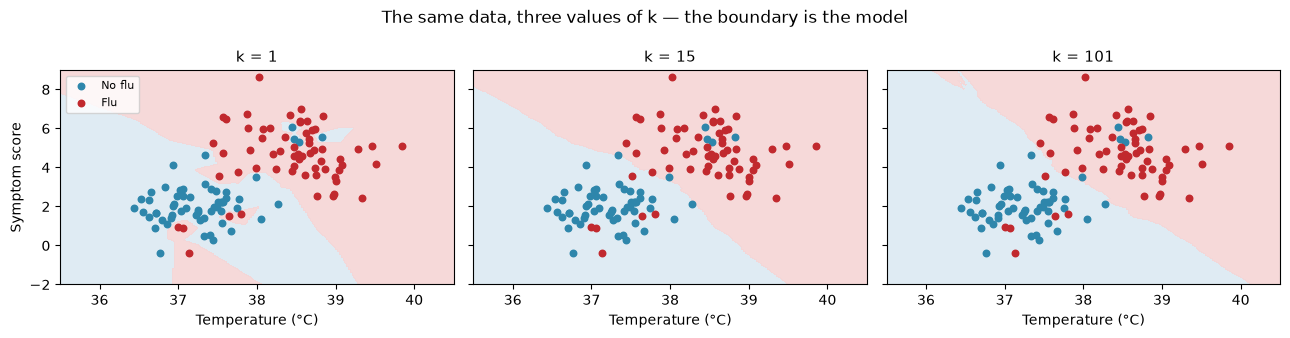

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True, sharey=True)
for ax, k in zip(axes, [1, 15, 101]):
    zz = knn_predict(X, y, grid, k).reshape(grid_t.shape)
    ax.contourf(grid_t, grid_s, zz, levels=[-0.5, 0.5, 1.5], colors=["#DCE9F2", "#F6D5D5"], alpha=0.9)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=22, color="#2E86AB", label="No flu")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=22, color="#C1292E", label="Flu")
    ax.set_title(f"k = {k}", fontsize=11)
    ax.set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Symptom score")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("The same data, three values of k — the boundary is the model", fontsize=12)
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** The shaded regions are the **decision boundary** — the classifier's answer for every possible new patient. Nothing else about the model exists; the picture *is* the model.
>
> - **k = 1** gives a jagged boundary with small islands. Every mislabeled point carves out its own territory, because with one neighbor nobody can outvote it. The model has memorized the noise.
> - **k = 15** is smooth and sensible. Mislabeled points are outvoted by their neighbors.
> - **k = 101** is nearly a straight line and is starting to ignore real structure. With k close to the size of the dataset, every query gets the majority class wherever it sits.



#### Where Section 9.3.1 leaves us

> **Small k = flexible and noisy  ·  Large k = rigid and blunt. Somewhere between them is the right amount of flexibility — and nothing in the training data can say where, because on the training data k = 1 is always perfect: every patient's nearest neighbor is itself.**

Two things are now needed. A fair way to score a model, which is Section 9.3.2. And names for the two failures in the picture — memorizing noise, and ignoring structure — which is Section 9.3.3.



### 9.3.2 Training, testing and accuracy

*Why a model must be judged on data it has never seen*

Section 9.3.1 ended with a question the training data cannot answer: which k is right? On the six patients themselves, k = 1 is perfect every time, because every patient's nearest neighbor is itself, at distance 0. A score computed on the data a model learned from measures how well it **memorized**, not how well it **generalizes** to someone new — and generalizing is the only thing wanted. This section sets out the fair procedure and its score.

- **1 · Training** — Learn a model from the **training data**.
- **2 · Testing** — Check the model on **unseen test data**.

$$\text{Accuracy} = \frac{\text{Number of correct classifications}}{\text{Total number of test cases}}$$

If 10 test patients are classified and 9 get the right answer, accuracy is $9/10 = 90\%$.



#### Cutting the data before any learning

So the labeled data is cut into two parts *before* any learning happens:

**Training set — 70–80% of the rows**

The model is allowed to look at these.

**Test set — the remaining 20–30%**

Locked away until the model is finished, then used **once**, to measure it.

The example below uses a **75% / 25%** split of 40 patients: 30 to train on, 10 held back.

> **Definition.** **Overfitting** is the name for the failure this guards against: a model that has learned the training data *too* specifically — its noise and accidents included — and therefore does well on data it has seen and badly on data it has not. High training accuracy with low test accuracy is the classic symptom; the k = 1 panel of Section 9.3.1 is a picture of it. Section 9.3.3 treats it fully.



#### The accuracy formula

$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\!\left[\hat{y}_i = y_i\right] \qquad\qquad \text{Error rate} = 1 - \text{Accuracy}$$

With $n$ test records, true labels $y_i$ and predictions $\hat{y}_i$: walk through the test records one at a time. Each time the prediction matches the truth, the $\mathbf{1}[\dots]$ contributes $1$; each time it does not, it contributes $0$. The sum is the number correct, and dividing by $n$ turns that count into a proportion.

> **Worked example.** Ten test patients. The model gets patients 1–7 and 9–10 right, and patient 8 wrong.
>
> The sum is $1+1+1+1+1+1+1+0+1+1 = 9$, so accuracy $= 9/10 = 0.9 = \mathbf{90\%}$, and the error rate is $1 - 0.9 = \mathbf{10\%}$. The two numbers say the same thing.

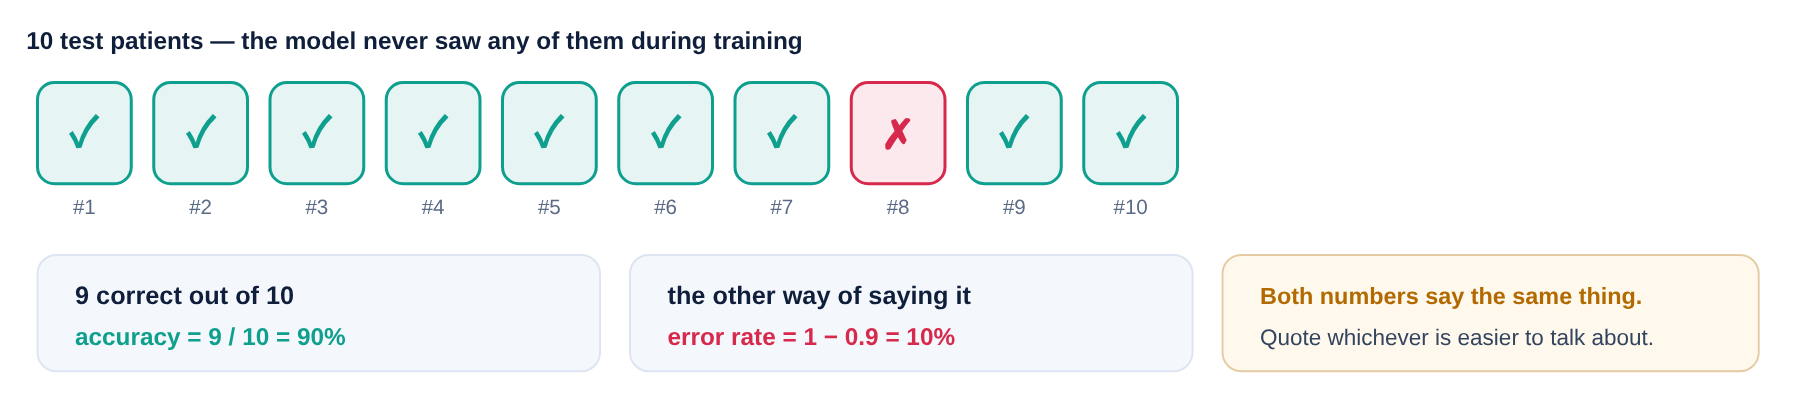

*Accuracy is a count, then a division. The only thing that makes it meaningful is that these ten patients were held back from training.*



#### The steps

*What the cells below do*

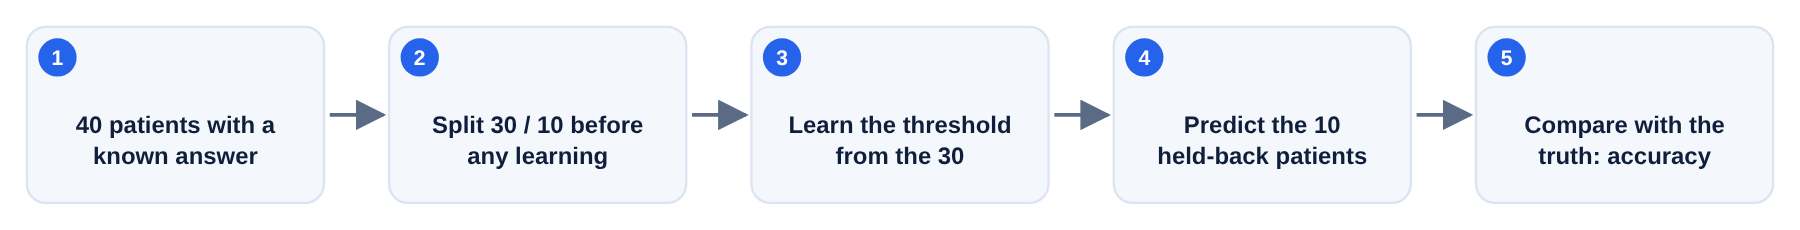

*Train on one part, score on a part the model never saw.*



#### A dataset where the right answer is known

The procedure is carried out on data built for the purpose. Forty body temperatures are drawn from a bell curve around 37.5 °C, and by construction a patient has the flu when their temperature is above 38.2. Comparing the whole array with 38.2 gives an array of True and False, one per patient — the ground truth the model will be scored against; the model is not told the rule. True counts as 1 when summed, so `.sum()` counts the flu cases. The data is invented so that the right answer is known; with real patients there would be nothing to check against.



In [13]:
n = 40
temp = rng.normal(37.5, 1.2, n)
true_flu = temp > 38.2                          # comparing an array gives an array of True/False
print("first eight temperatures:", temp[:8].round(1))
print("first eight labels:      ", true_flu[:8])
print("flu cases among the 40:  ", int(true_flu.sum()))

first eight temperatures: [38.2 38.7 38.3 39.8 38.1 37.6 36.8 36.8]
first eight labels:       [False  True  True  True False False False False]
flu cases among the 40:   14


#### The split, before any learning

Three quarters of the 40 patients are for training and the rest for testing. `temp[:split]` is everything up to the split point and `temp[split:]` everything from it onward; the labels are cut at the same point, so each temperature stays with its own diagnosis. The cut is made first, before anything is learned, and the test labels are put away until the very last step.



In [14]:
split = int(n * 0.75)                            # 30 of 40
train_temp, test_temp = temp[:split], temp[split:]
train_flu, test_flu = true_flu[:split], true_flu[split:]
print("training patients:", len(train_temp), "  test patients:", len(test_temp))

training patients: 30   test patients: 10


#### The model — one number, learned from the training set only

The model is the simplest possible: a temperature threshold. `train_temp[train_flu]` uses the True/False array as a mask and keeps only the training temperatures of patients who had the flu — the only numbers the model gets to see — and the lowest of them becomes the threshold: anyone hotter is predicted to have the flu. That single number is the entire model, and the point of the next two cells is to see whether it still works on patients it never saw.



In [15]:
print("training temperatures of the flu patients:", train_temp[train_flu].round(1))
threshold = train_temp[train_flu].min()
print("threshold:", round(float(threshold), 2))

training temperatures of the flu patients: [38.7 38.3 39.8 39.1 38.3 40.4 39.  38.4 38.4]
threshold: 38.28


#### Test accuracy

The threshold is applied to the ten test temperatures, giving one True/False prediction per test patient — the first time the model meets them. Then the test labels come out: comparing predictions with the truth gives True wherever the model was right, the $\mathbf{1}[\hat{y}_i = y_i]$ of the formula, and the share of True values is the accuracy (the mean of a True/False array is the proportion of Trues, because True counts as 1).

$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\!\left[\hat{y}_i = y_i\right]$$



> **Interpretation.** The threshold was learned from the training set only and then scored on ten patients the model had never seen, so the number is an honest estimate of how the model would do on the next patient through the door. Testing on the training patients instead would have said how well it memorized them, which is a different question. Every algorithm in Chapter 10 is scored this same way: train on one part, report on a part the model never saw.



In [16]:
predicted_flu = test_temp > threshold
print("predicted:", predicted_flu)
print("truth:    ", test_flu)
accuracy = (predicted_flu == test_flu).mean()
print(f"\nTest accuracy: {accuracy:.0%}  ({(predicted_flu == test_flu).sum()}/{len(test_flu)} correct)")

predicted: [False  True  True False  True  True  True False False False]
truth:     [False  True  True False  True  True  True False False False]

Test accuracy: 100%  (10/10 correct)


#### A caution on perfect scores

> **An easy problem.** A perfect score is a reason to look closer, not a reason to be pleased. This problem was easy by construction: the data was *built* so that flu is exactly “temperature above 38.2”, and the model was asked for a temperature threshold. Real problems are never that clean, and a model with too much flexibility can score perfectly on its training data while learning nothing general — the subject of Section 9.3.3.

> **Accuracy under class imbalance.** Accuracy can also make a useless model look good when the classes are **imbalanced**. Consider screening for a disease that only 1 person in 100 has. A “model” that ignores its input and always answers “healthy” scores **99% accuracy** — and catches not a single patient. Section 9.3.5 introduces the measures — precision, recall and the confusion matrix — that look at *which kind* of mistake a model makes, not only how many.

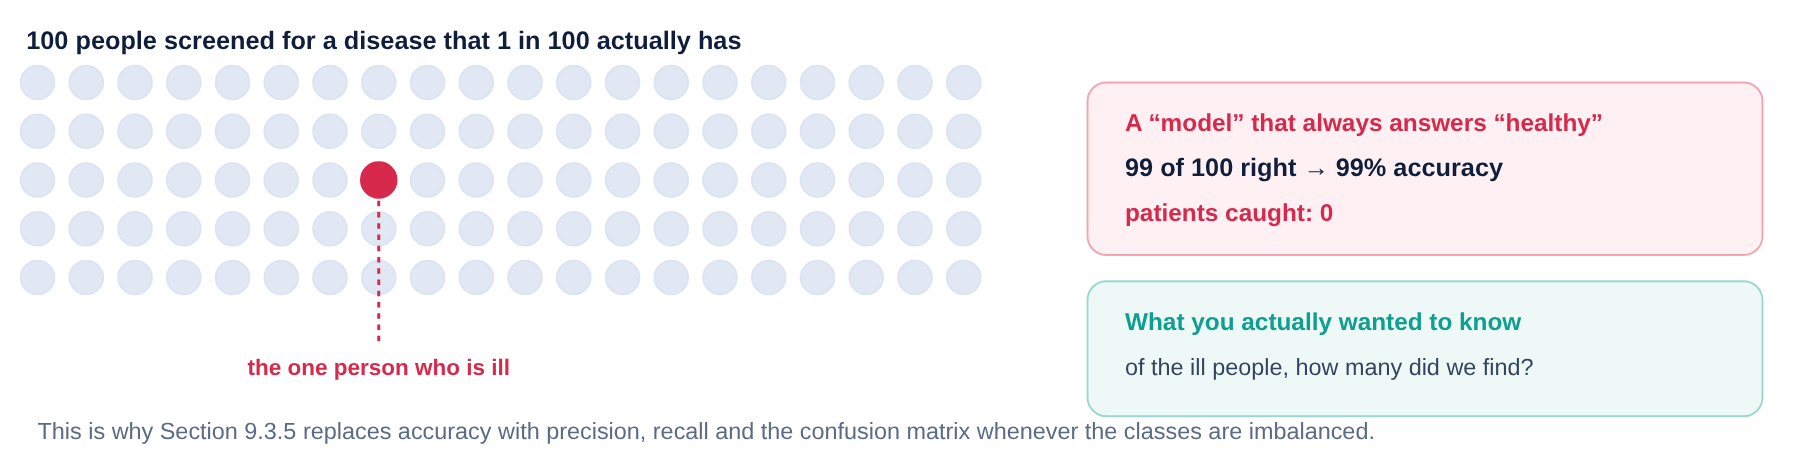

*A single number can hide a model that does nothing at all. The rarer the thing you are hunting, the easier accuracy is to fake.*



### 9.3.3 Overfitting and underfitting

*The central problem of machine learning*

The picture at the end of Section 9.3.1 showed two ways a model can be wrong: k = 1 memorized the noise, and k = 101 ignored the structure. Section 9.3.2 then showed that only a score on unseen data can tell the two apart from a good fit. This section names the two failures, explains where the names come from, and then reproduces both in code with a model whose flexibility can be turned up one notch at a time.

|  | Underfitting | Overfitting |
|---|---|---|
| **The model is** | Too simple to capture the pattern | Too flexible; it memorizes the noise |
| **Training error** | High | Very low, often zero |
| **Test error** | High | High |
| **Called** | High **bias** | High **variance** |
| **Fix by** | More flexibility, better features | Less flexibility, more data, regularization |

> **Why training error cannot guide the choice.** **Training error always improves as flexibility is added**, so it cannot say when to stop. Only error on data the model has never seen can.



#### Three fits

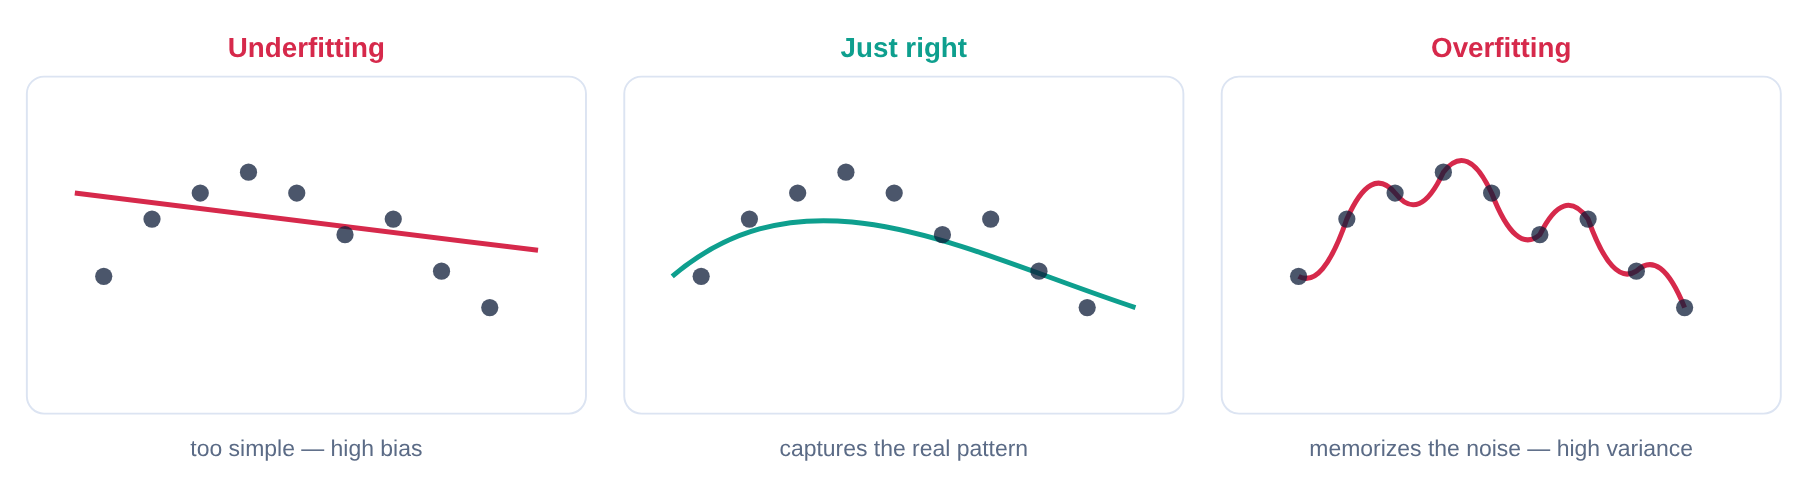

*Same nine points, three models. Only the middle one would do well on a tenth point that none of them has seen.*



#### Where the words “bias” and “variance” come from

*not loose metaphors*

Imagine collecting the training data over and over — a different sample each time — and refitting the model on each one. The average squared error on new data then splits into exactly three pieces:

$$\underbrace{\text{total error}}_{\text{what you measure on new data}}= \underbrace{\text{Bias}^2}_{\text{wrong in the same direction every time}}+ \underbrace{\text{Variance}}_{\text{jumps around between samples}}+ \underbrace{\text{noise}}_{\text{unpredictable, in the world itself}}$$

$$\mathbb{E}\!\left[\left(y - \hat{f}(x)\right)^{2}\right]= \left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^{2}\;+\; \mathbb{E}\!\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^{2}\right]\;+\; \sigma^{2}$$

where $f(x)$ is the truth, $\hat{f}(x)$ is the fitted model, and $\mathbb{E}[\,\cdot\,]$ means “the average over all those imagined training sets”.



#### Bias and variance

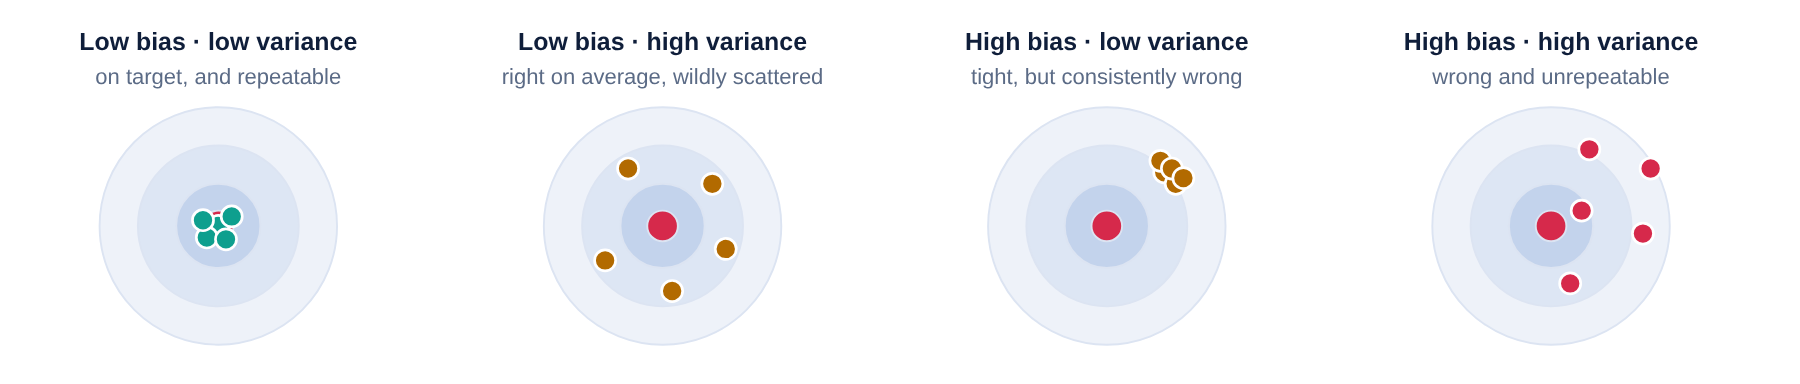

*Each dot is the model refitted on a different sample of training data. **Bias** is how far the cluster of dots sits from the bullseye; **variance** is how spread out the dots are among themselves.*



#### Worked example — a house worth 15 million

> **Worked example.** A house truly worth **15** million baht. The model is trained on three different samples of past sales, and predicts **12**, **16** and **20**.
>
> - **Step 1 — the average prediction.** $(12 + 16 + 20) / 3 = \mathbf{16}$.
> - **Step 2 — bias.** How far that average sits from the truth: $16 - 15 = 1$, so $\text{Bias}^2 = 1^2 = \mathbf{1}$. The model leans high whichever sample it sees.
> - **Step 3 — variance.** How far each prediction sits from its own average of 16: $(12-16)^2 = 16$, $(16-16)^2 = 0$, $(20-16)^2 = 16$. Average: $(16 + 0 + 16)/3 = \mathbf{10.7}$.
>
> Variance ($10.7$) dwarfs bias ($1$), so this model's problem is **instability, not a systematic lean** — it is overfitting. The fix is a simpler model or more data.



#### The three components, interpreted

- **Bias — wrong the same way every time** — A straight line through a curve is too low in the middle and too high at the ends *however much data it is given*. That is **underfitting**.
- **Variance — wrong a different way each time** — A very flexible model chases whichever points it happened to receive, so a fresh sample produces a very different answer. That is **overfitting**.
- **Noise — nobody can predict it** — Two identical houses genuinely sell for different prices. No model removes it, which is why a test error of exactly zero is a warning sign rather than a success.

> **Flexibility trades bias against variance. The best model sits where the *total* bottoms out — and since the total is what test error estimates, only test error can find it. The next cells show that happening.**



#### The steps

*What the cells below do*

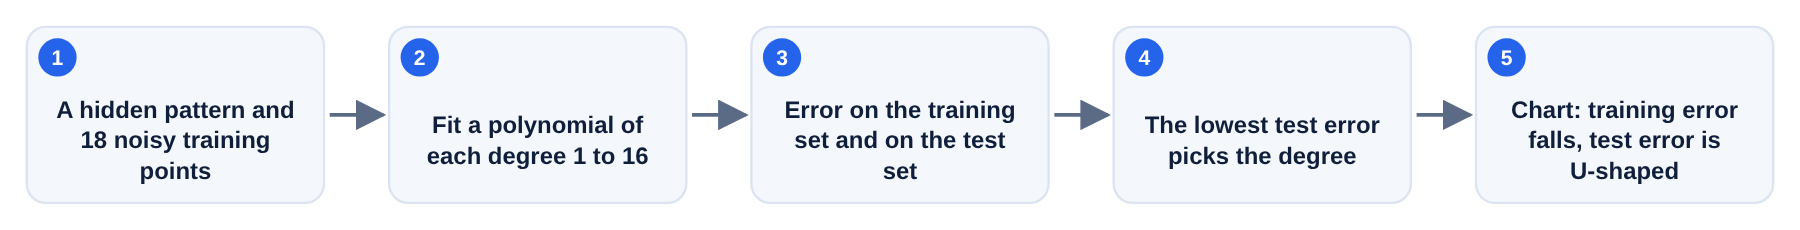

*Turning the flexibility dial one notch at a time and watching both errors.*



#### A hidden pattern, 18 training points and 200 test points

To watch both failures happen, a case is needed where the true pattern is known. A function plays that part — a curve of x against y; in real life it is never available, here it is written down so every fit can be judged against it. Eighteen training x-values are drawn at random between 0 and 6, and each y is the true pattern at its x plus a little random noise — the noise is what makes a perfect fit impossible. Two hundred more points from the same pattern are kept for scoring and never shown to any model; the test set is much larger than the training set so its score is steady rather than an accident of a few points.



In [17]:
def true_function(x):
    """The pattern the data really follows. In real life it is never known."""
    return np.sin(x * 1.4) * 2.5 + 0.4 * x

rng_fit = np.random.default_rng(888102)
x_train = np.sort(rng_fit.uniform(0, 6, 18))
y_train = true_function(x_train) + rng_fit.normal(0, 0.7, len(x_train))     # pattern + noise
x_test = np.sort(rng_fit.uniform(0, 6, 200))
y_test = true_function(x_test) + rng_fit.normal(0, 0.7, len(x_test))
print("x_train:", x_train.round(2))
print("y_train:", y_train.round(2))
print("training points:", len(x_train), "  test points:", len(x_test))

x_train: [0.49 0.66 1.23 1.3  1.39 2.53 2.85 2.88 2.98 3.17 3.55 3.66 3.68 4.88
 5.06 5.31 5.61 5.67]
y_train: [ 1.61  2.7   4.63  3.83  3.43 -0.19 -0.2  -1.05 -1.26 -0.81 -0.92 -0.89
 -1.54  3.83  4.36  4.75  6.82  5.99]
training points: 18   test points: 200


#### Three degrees fitted to the same points

The model family is polynomials, and the degree is the flexibility dial: degree 1 is a straight line, degree 15 can bend fifteen times. Degrees 1, 4 and 15 are fitted to the same 18 points and drawn against the true pattern, with the training and test error in each panel's title.



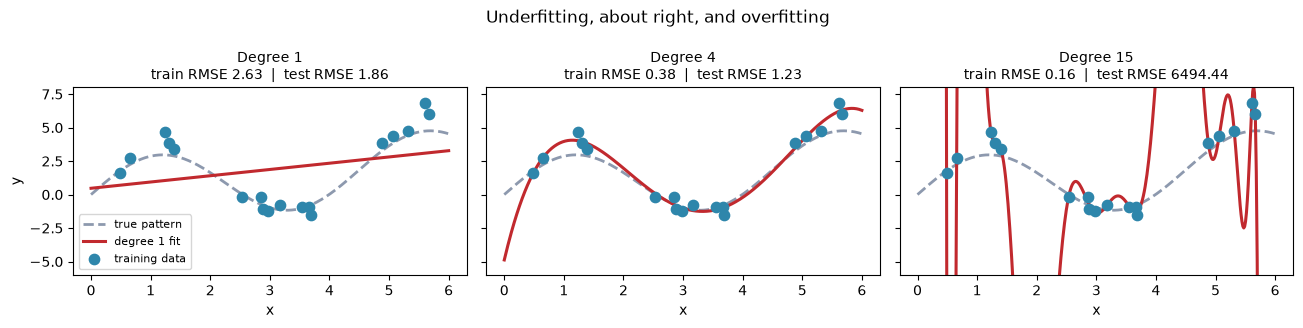

In [18]:
grid = np.linspace(0, 6, 400)          # 400 evenly spaced x values, only for drawing smooth curves
degrees_shown = [1, 4, 15]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
for ax, degree in zip(axes, degrees_shown):
    fitted = np.poly1d(np.polyfit(x_train, y_train, degree))
    train_rmse = np.sqrt(((fitted(x_train) - y_train) ** 2).mean())
    test_rmse = np.sqrt(((fitted(x_test) - y_test) ** 2).mean())
    ax.plot(grid, true_function(grid), color="#8D99AE", linewidth=2, linestyle="--", label="true pattern")
    ax.plot(grid, fitted(grid), color="#C1292E", linewidth=2.2, label=f"degree {degree} fit")
    ax.scatter(x_train, y_train, s=55, color="#2E86AB", zorder=5, label="training data")
    ax.set_ylim(-6, 8)
    ax.set_xlabel("x")
    ax.set_title(f"Degree {degree}\ntrain RMSE {train_rmse:.2f}  |  test RMSE {test_rmse:.2f}", fontsize=10)
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Underfitting, about right, and overfitting", fontsize=12)
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** Three panels, three amounts of flexibility:
>
> - **Degree 1** — a straight line cannot bend, so it misses the curve everywhere: high error on training and test alike. This is bias.
> - **Degree 4** — follows the pattern without chasing the noise: both errors low, and close to each other. About right.
> - **Degree 15** — passes close to every training point and swings wildly between them: training error tiny, test error large. This is variance.
> - The two numbers in each title are these errors; the next cell computes them for every degree.



#### Every degree from 1 to 16

The loop fits one polynomial per degree and records the error on the training set and on the test set, side by side in a table with one column per degree. numpy warns that the highest degrees are numerically unstable — a symptom of the very problem this section is about — so the warning is caught and reported as a sentence rather than a red box.



> **Interpretation.** Read the two rows across: that is the whole lesson. Training error falls all the way along. Test error falls, bottoms out, then climbs again — and only the second row knows when to stop.



In [19]:
import warnings

degrees = range(1, 17)
train_errors, test_errors = [], []
unstable_from = None
for degree in degrees:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fitted = np.poly1d(np.polyfit(x_train, y_train, degree))
        if caught and unstable_from is None:
            unstable_from = degree
    train_errors.append(np.sqrt(((fitted(x_train) - y_train) ** 2).mean()))
    test_errors.append(np.sqrt(((fitted(x_test) - y_test) ** 2).mean()))

if unstable_from:
    print(f"note: from degree {unstable_from} upward numpy reports the fit as poorly conditioned —")
    print(f"      {len(x_train)} points cannot pin down that many coefficients.\n")

pd.DataFrame({"degree": list(degrees),
              "train error": np.round(train_errors, 2),
              "test error": np.round(test_errors, 2)}).set_index("degree").T   # one column per degree

note: from degree 16 upward numpy reports the fit as poorly conditioned —
      18 points cannot pin down that many coefficients.



degree,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
train error,2.63,1.35,1.01,0.38,0.38,0.38,0.37,0.35,0.30,0.29,0.22,0.21,0.21,0.19,0.16,0.16
test error,1.86,1.93,1.49,1.23,1.29,1.34,1.76,1.34,5.83,3.20,30.29,7.04,8.65,459.37,6494.44,4379.48


#### The best degree

The best model is the one with the lowest *test* error, not the lowest training error. `np.argmin` finds the position of the smallest test error and the degree at that position is read off; the lowest degree, the best and the highest are then printed together — an underfit, the sweet spot and an overfit, each with its two errors.



In [20]:
best_degree = list(degrees)[int(np.argmin(test_errors))]
print(f"Degree {list(degrees)[0]:>2}: train {train_errors[0]:.2f}  test {test_errors[0]:.2f}   (underfit)")
print(f"Degree {best_degree:>2}: train {train_errors[best_degree-1]:.2f}  "
      f"test {test_errors[best_degree-1]:.2f}   (best)")
print(f"Degree {list(degrees)[-1]:>2}: train {train_errors[-1]:.2f}  test {test_errors[-1]:.2f}   (overfit)")

Degree  1: train 2.63  test 1.86   (underfit)
Degree  4: train 0.38  test 1.23   (best)
Degree 16: train 0.16  test 4379.48   (overfit)


#### Training error against test error

The table as a chart: both error curves against the degree, on a logarithmic scale so the whole range fits. The dashed line marks the best degree; blue shading is the underfitting side, red the overfitting side.



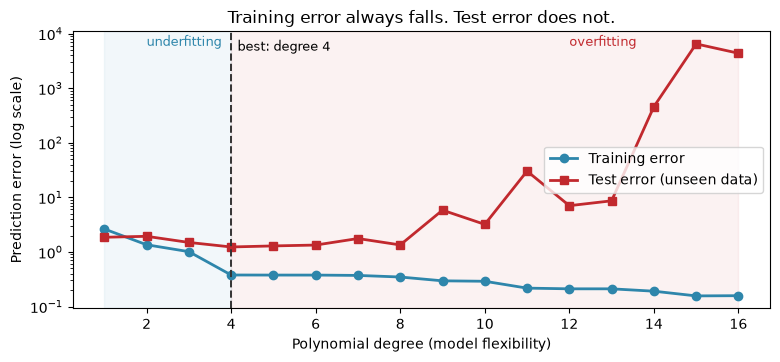

In [21]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(degrees, train_errors, marker="o", linewidth=2, color="#2E86AB", label="Training error")
ax.plot(degrees, test_errors, marker="s", linewidth=2, color="#C1292E", label="Test error (unseen data)")
ax.axvline(best_degree, color="#333", linestyle="--", linewidth=1.4)
ax.text(best_degree + 0.15, max(test_errors) * 0.75, f"best: degree {best_degree}", fontsize=9)
ax.axvspan(1, best_degree, color="#2E86AB", alpha=0.06)
ax.axvspan(best_degree, 16, color="#C1292E", alpha=0.06)
ax.text(2, max(test_errors) * 0.92, "underfitting", fontsize=9, color="#2E86AB")
ax.text(12, max(test_errors) * 0.92, "overfitting", fontsize=9, color="#C1292E")
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree (model flexibility)")
ax.set_ylabel("Prediction error (log scale)")
ax.set_title("Training error always falls. Test error does not.")
ax.legend()
plt.show()

#### What the chart shows

> **Interpretation.** The most important chart in the chapter:
>
> - **Blue line — training error** only ever goes down. More flexibility always fits the training data better, and with 18 points a high enough degree threads through every one.
> - **Red line — test error** is U-shaped. It falls while extra flexibility captures real pattern, then rises once the flexibility is spent memorizing noise.
> - **The gap between the two lines** is the overfitting.
> - **The dashed line** marks the degree with the lowest test error — the one to keep.



#### Two rules from the chart

- **Rule 1 — training performance is not evidence of anything** — A student who memorized the answer key scores 100% on that exam and has learned nothing.
- **Rule 2 — the best model is rarely the most complex one** — The bottom of the red curve is what you want, and it can only be found by measuring on data the model has not seen.

> **A loose end.** One thing in the cells above was not quite honest. The best degree was chosen *by looking at the test error*, so the test set influenced the model that was picked, and the reported test error is now a little optimistic. The next section fixes this.



### 9.3.4 Validation and cross-validation

*Choosing a model with the test set quietly spoils it*

Section 9.3.3 used the test set twice: once to choose the degree and once to report how good the chosen degree is. The second use is no longer a measurement on unseen data, because the choice already depended on it. The fix is a third set, used for choosing, so the test set is touched exactly once:

| Set | Typical share | Used for |
|:--|:-:|:--|
| **Training** | 60% | Fitting the model's parameters |
| **Validation** | 20% | Choosing between models and settings (like `k` or the degree) |
| **Test** | 20% | One final, honest estimate — touched **once**, at the very end |

When data is scarce, holding out 20% twice is painful. **k-fold cross-validation** avoids it: split the training data into k parts, and take turns using each part as the validation set.



#### k-fold cross-validation

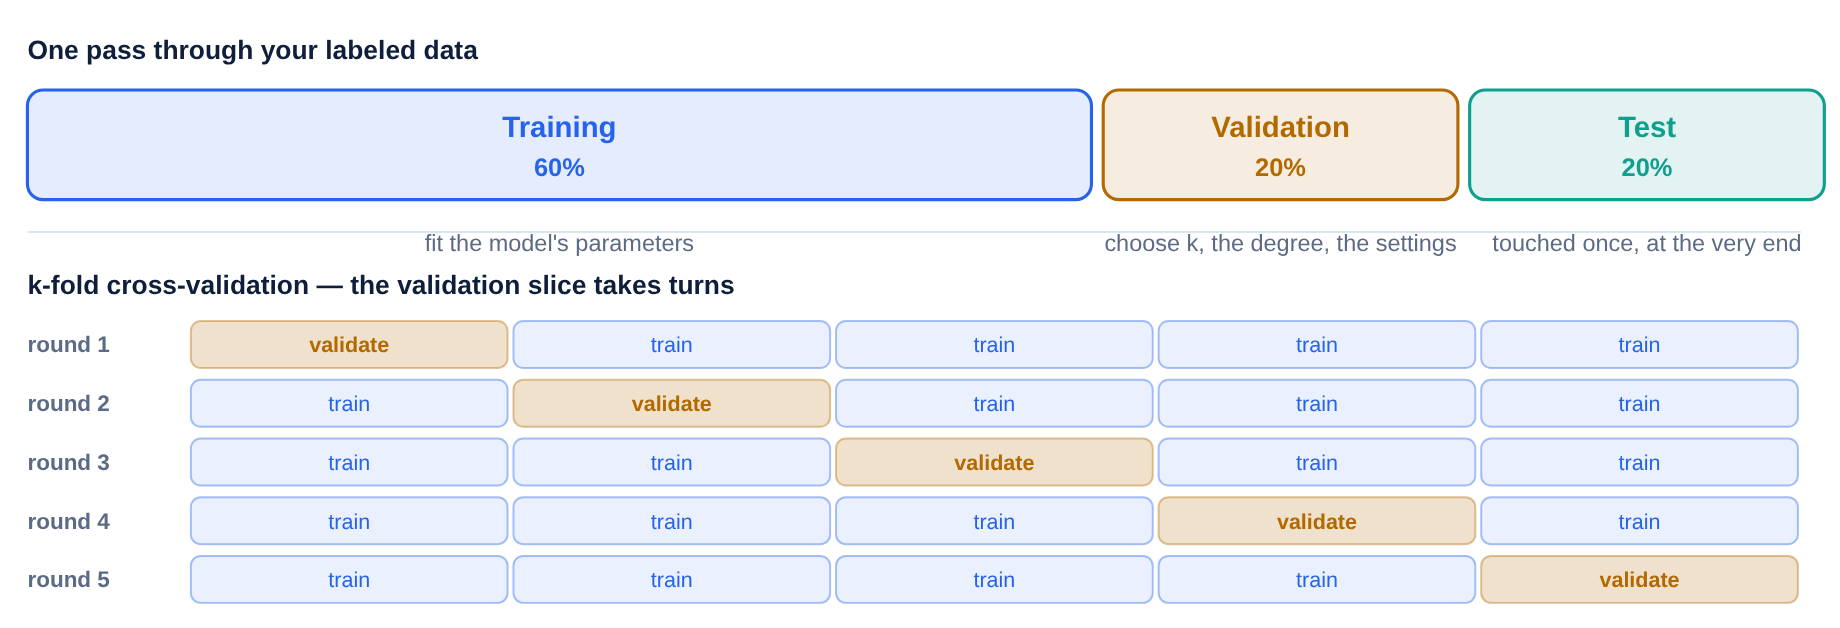

*Every row is one round; every column is one fifth of the data. Each fifth validates exactly once and trains four times — so nothing is wasted, and nothing is ever tested by a model that already saw it.*



#### The cross-validation formula

$$\text{CV}_{k} = \frac{1}{k} \sum_{j=1}^{k} L_{j}$$

*k-fold cross-validation.* Cut the training data into $k$ equal parts, called **folds**. Take turns: hold out one fold, train on the other $k-1$, and measure the error $L_j$ on the held-out fold. The estimate is the average of those $k$ errors. Every record is used for training $k-1$ times and for validation exactly once, and no record is ever scored by a model that had already seen it. That is what makes the estimate honest without permanently giving up 20% of the data.

> **Note.** $k = 5$ and $k = 10$ are the usual choices. Setting $k = n$ — one record per fold — is called **leave-one-out**: the most thorough and the slowest, since it fits the model $n$ times.

**Worked example.** **5-fold cross-validation on the 18 training points, degree 4.** The points are shuffled and cut into five folds of 3 or 4; each round fits the polynomial on four folds and measures the error on the fifth (these are the numbers the code below prints):

| Round | Trained on | Tested on | Error $L_j$ |
|:-:|:--|:--|--:|
| **1** | folds 2,3,4,5 | fold 1 | $0.51$ |
| **2** | folds 1,3,4,5 | fold 2 | $0.65$ |
| **3** | folds 1,2,4,5 | fold 3 | $0.47$ |
| **4** | folds 1,2,3,5 | fold 4 | $0.50$ |
| **5** | folds 1,2,3,4 | fold 5 | $0.44$ |

$\text{CV}_5 = (0.51 + 0.65 + 0.47 + 0.50 + 0.44) / 5 = 2.57 / 5 = \mathbf{0.51}$.

Notice the spread: fold 2 gave $0.65$ and fold 5 gave $0.44$. A single split would have handed over one of those numbers at random. Averaging five is steadier, and the spread itself warns how much any single split can mislead.



#### The steps

*What the cells below do*

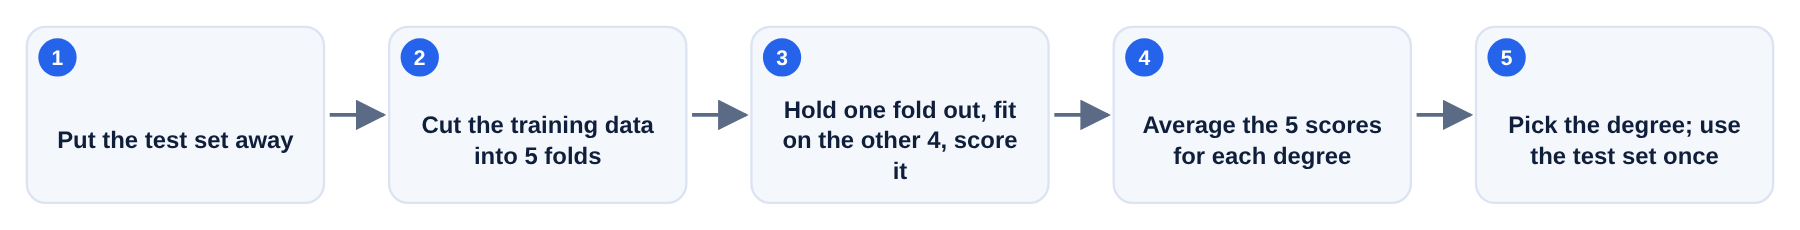

*Cross-validation chooses the model without touching the test set.*



#### The cross-validation function

The procedure is now applied to the polynomial problem of Section 9.3.3, using the training data only. The function shuffles the 18 training points, cuts them into five folds, and for each fold fits the polynomial on the other four and measures its error on the held-out one. It returns the five errors.

$$\text{CV}_{k} = \frac{1}{k} \sum_{j=1}^{k} L_{j}$$

The function returns the k errors; the mean is taken in the cells that follow.



In [22]:
def cross_validate_polynomial(x, y, degree, n_folds=5, seed=888102):
    local_rng = np.random.default_rng(seed)
    order = local_rng.permutation(len(x))            # shuffle the row numbers
    folds = np.array_split(order, n_folds)           # cut them into k folds
    scores = []
    for fold in folds:
        validation_mask = np.zeros(len(x), dtype=bool)
        validation_mask[fold] = True                 # True for the held-out rows
        fitted = np.poly1d(np.polyfit(x[~validation_mask], y[~validation_mask], degree))
        scores.append(np.sqrt(((fitted(x[validation_mask]) - y[validation_mask]) ** 2).mean()))
    return np.array(scores)

#### Cross-validation across degrees

A single call for degree 4 first shows what the function returns: one error per fold, five in all, and their spread is the first thing to notice. Then the same procedure runs for seven degrees, printing the five fold scores, their mean and their standard deviation — the mean is the number used to choose, the standard deviation says how much any one fold would have misled. The degree with the lowest mean is chosen, and the test set has not been looked at; it can now be used once, honestly.



In [23]:
print("degree 4, one error per fold:", cross_validate_polynomial(x_train, y_train, degree=4).round(2), "\n")
print(f"{'degree':>7} {'fold scores (RMSE)':>44} {'mean':>8} {'std':>7}")
cv_means = []
for degree in [1, 2, 3, 4, 5, 8, 12]:
    scores = cross_validate_polynomial(x_train, y_train, degree)
    cv_means.append((degree, scores.mean()))
    print(f"{degree:>7} {np.array2string(scores, precision=2, floatmode='fixed'):>44} "
          f"{scores.mean():>8.2f} {scores.std():>7.2f}")
chosen = min(cv_means, key=lambda pair: pair[1])       # the pair with the smallest mean error
print(f"\nCross-validation picks degree {chosen[0]} (mean RMSE {chosen[1]:.2f}), without touching the test set.")

degree 4, one error per fold: [0.51 0.65 0.47 0.5  0.44] 

 degree                           fold scores (RMSE)     mean     std
      1                   [3.19 3.18 2.70 2.36 2.08]     2.70    0.44
      2                   [1.47 2.32 1.02 0.69 1.54]     1.41    0.55
      3                   [0.91 1.62 1.39 1.21 1.55]     1.34    0.26
      4                   [0.51 0.65 0.47 0.50 0.44]     0.51    0.07
      5                   [0.62 0.68 0.49 0.61 0.43]     0.57    0.09
      8                   [0.59 0.87 1.82 1.81 0.55]     1.13    0.57
     12 [5.59e-01 4.02e+03 1.38e+02 4.10e+01 7.92e+00]   841.94 1591.04

Cross-validation picks degree 4 (mean RMSE 0.51), without touching the test set.


#### The folds

The rotation as a picture: each row is one round, red cells are held out for validation, blue cells are trained on.



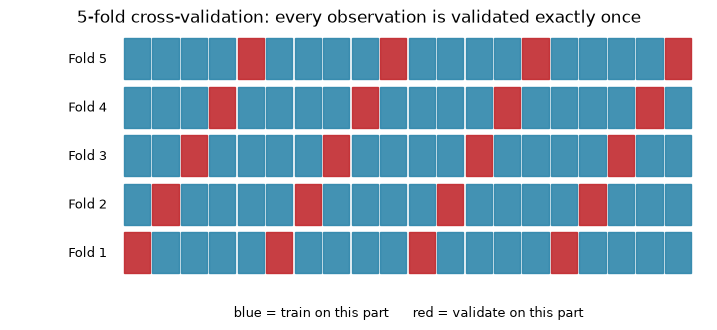

In [24]:
fig, ax = plt.subplots(figsize=(9, 3.4))
n_folds = 5
for fold in range(n_folds):
    for position in range(20):
        is_validation = (position % n_folds) == fold
        ax.add_patch(plt.Rectangle((position, fold), 0.92, 0.85,
                                   color="#C1292E" if is_validation else "#2E86AB", alpha=0.9))
    ax.text(-0.6, fold + 0.42, f"Fold {fold + 1}", ha="right", va="center", fontsize=9)
ax.set_xlim(-4, 20.5)
ax.set_ylim(-0.4, n_folds)
ax.set_title("5-fold cross-validation: every observation is validated exactly once")
ax.text(10, -0.9, "blue = train on this part      red = validate on this part", ha="center", fontsize=9)
ax.axis("off")
plt.show()

#### What the chart shows

> **Interpretation.** How to read the rows:
>
> - **Each row is one round.** The red fifth is held out and scored; the four blue fifths are trained on.
> - **Every fifth is red exactly once** and blue four times, so all the data does both jobs, and no round trains and scores on the same rows.
> - **In the printout above, the standard deviation matters as much as the mean.** A degree whose fold scores swing widely fits whichever points it happened to see — overfitting in another disguise.



#### The workflow this implies

1. **Split off a test set and put it away** — Do not look at it again until step 4.
2. **Cross-validate on the rest** — Use it to choose the model and its settings.
3. **Retrain the chosen model** — On *all* the non-test data.
4. **Evaluate once on the test set** — And report that number.

> **Watch out.** Step 4 is the number you publish. Going back to tune after seeing it makes it dishonest again.

The procedure for scoring a model is now complete. What remains is the score itself: Section 9.3.2 warned that accuracy can flatter a useless model when one class is rare, and the next section replaces it with something that cannot be fooled that way.



### 9.3.5 Accuracy is not enough — the confusion matrix

*Four boxes, and every metric is a different way of dividing them*

Accuracy counts how many predictions were right. It says nothing about *which* ones were wrong, and on a yes/no problem there are two different ways to be wrong that usually cost very different amounts — a disease missed is not the same as a healthy patient called back for a second test. Every prediction on a yes/no problem lands in one of four boxes:

|  | Actually positive | Actually negative |
|---|---|---|
| **Predicted positive** | **True positive (TP)** — correctly caught | **False positive (FP)** — a false alarm |
| **Predicted negative** | **False negative (FN)** — a miss | **True negative (TN)** — correctly left alone |



#### Only for classification

> **Where a confusion matrix applies.** A confusion matrix exists only for a **classification** problem, because its boxes count answers that were right or wrong — Flu or No flu, ill or healthy, spam or not. A **regression** model predicts a number, and a prediction of 15.2 million for a house worth 15 million is neither right nor wrong, only close or far; regression is judged by the size of its errors instead, as the training and test error of Section 9.3.3 already did, and Chapter 10 gives those measures their names (RMSE, MAE, R²). With more than two classes the matrix has more rows and columns — one per class — and the same four kinds of count are read off for each class in turn.



#### The four boxes

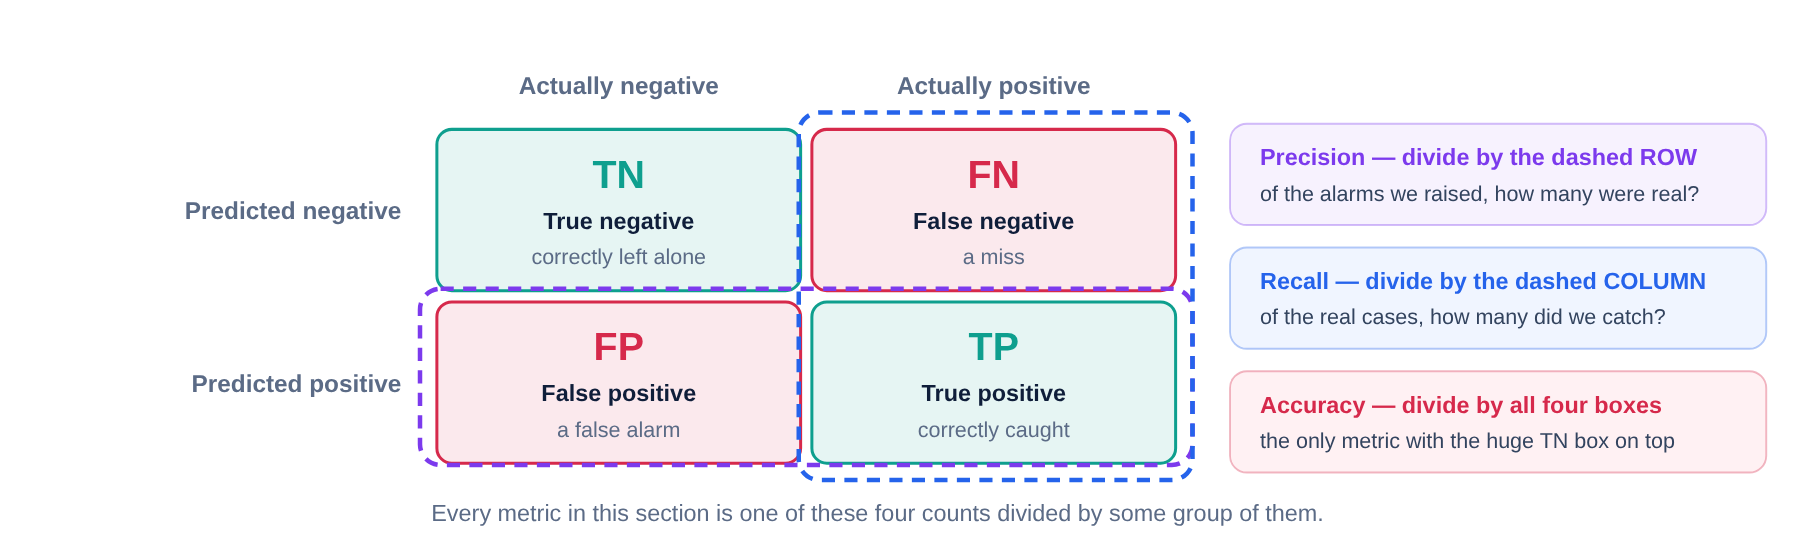

*Accuracy fuses the two mistakes into one number. Precision and recall pull them apart by asking about a **row** and a **column** instead of the whole square.*



#### Three metrics from four counts

Each metric answers one question about the four boxes, and each is a fraction: something the model got right, divided by some group of people. The whole difficulty of this section is keeping track of *which group* is on the bottom line.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{Specificity} = \frac{TN}{TN + FP} \qquad\qquad F_{1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$



#### Accuracy, precision and recall in words

- **Accuracy — out of everyone, how many decisions were right** — Both kinds of correct answer (TP and TN) over all patients. It is the natural first score and the one everyone quotes. Its weakness: when one class is rare, TN is enormous and is earned for free by saying “no” to everyone — so a high accuracy can hide a model that catches nobody.
- **Precision — out of the people flagged, how many were really ill** — TP over everything the model flagged (TP + FP). Low precision means many false alarms: healthy people called back, real emails sent to the spam folder. Care about precision when *acting on a flag is expensive* — a follow-up test, a blocked transaction, a deleted message.
- **Recall — out of the people who were ill, how many were caught** — TP over everyone who really had the condition (TP + FN). Low recall means missed cases: sick patients sent home. Care about recall when *missing a case is expensive* — cancer screening, fraud detection, a smoke alarm. A model that flags everyone has recall 100% and terrible precision.
- **Specificity — out of the healthy, how many were correctly left alone** — TN over everyone who was healthy (TN + FP). It is recall's mirror image for the negative class, and it is what a high accuracy on a rare condition is mostly made of.
- **F1 — precision and recall in one number** — The harmonic mean of the two, which stays close to the smaller one. Use it when one number is needed and both kinds of mistake matter. It ignores TN entirely, which is why it does not reward a model for the easy negatives.

> **The two that pull against each other.** Precision and recall both have TP on top and differ only in the bottom line: precision divides by the **flagged** column of the table, recall by the **actually ill** row. Raising the threshold flags fewer people, so precision goes up and recall goes down; lowering it does the reverse. No threshold makes both perfect on overlapping scores — which is why the two are always reported together.



#### Worked example — a screening test

**Worked example.** **A screening test on 1,000 people, of whom 60 truly have the condition.** The test flags 50 people. Of those 50, 40 really have it and 10 do not.

First fill in the four boxes: $TP = 40$ (flagged and really ill) · $FP = 10$ (flagged but healthy) · $FN = 60 - 40 = 20$ (ill but missed) · $TN = 1000 - 40 - 10 - 20 = 930$.

| Metric | Substitute the numbers | Result |
|:--|:--|--:|
| **Accuracy** | $(40 + 930) / 1000$ | $\mathbf{97.0\%}$ |
| **Precision** | $40 / (40 + 10) = 40/50$ | $\mathbf{80.0\%}$ |
| **Recall** | $40 / (40 + 20) = 40/60$ | $\mathbf{66.7\%}$ |
| **Specificity** | $930 / (930 + 10) = 930/940$ | $\mathbf{98.9\%}$ |
| **$F_1$** | $2 \times (0.80 \times 0.667) / (0.80 + 0.667) = 1.067 / 1.467$ | $\mathbf{72.7\%}$ |

**The consequence.** A model that answers “nobody is ill” in every case scores $940/1000 = \mathbf{94\%}$ accuracy — three points below the real model — while catching **zero** patients. Its recall is $0/60 = 0\%$. Accuracy is the only metric here with $TN$ in the top line, and on rare conditions $TN$ is enormous and free. That is how a useless model hides behind a fine-looking accuracy.



#### The screening test, counted

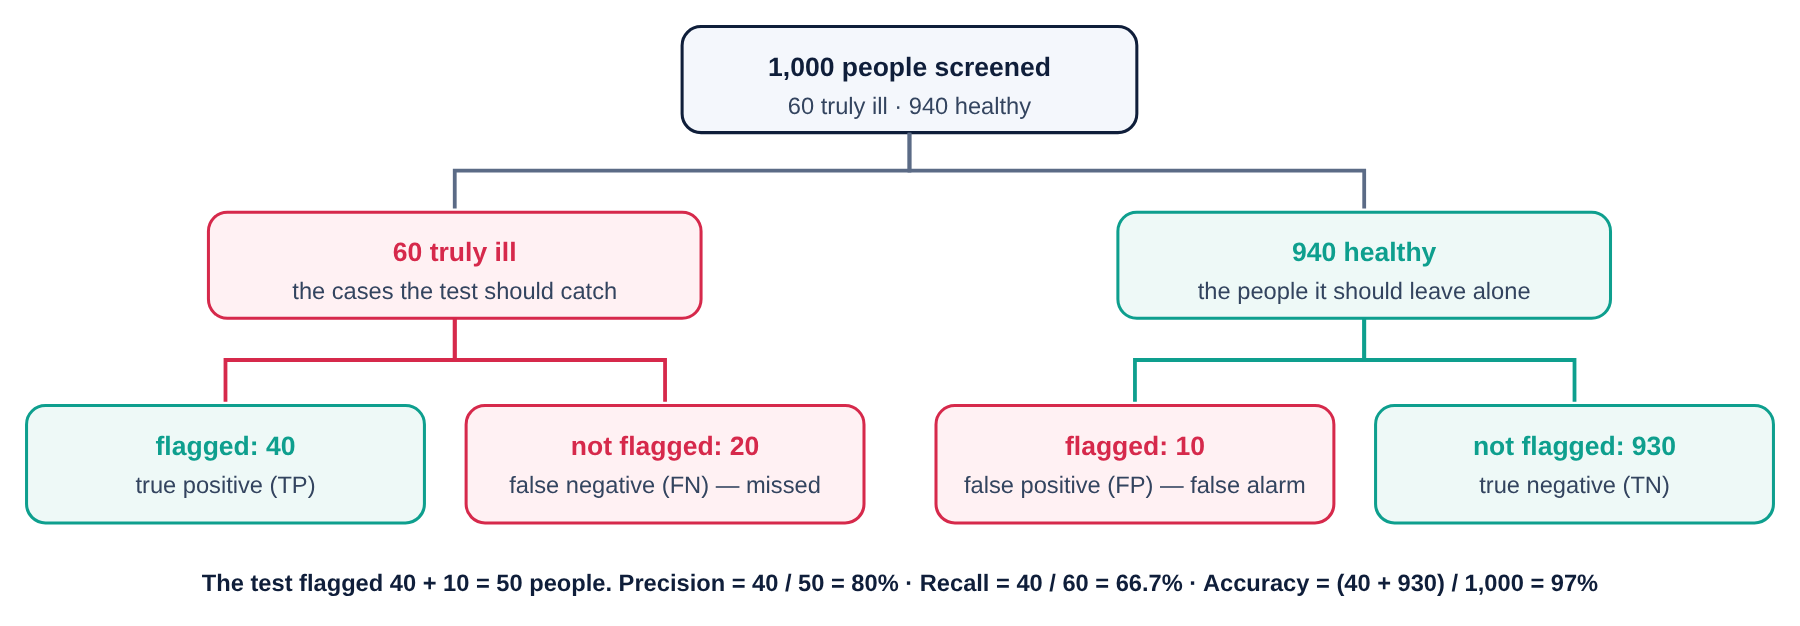

*The four counts of the worked example: 1,000 people split first by the truth, then by the test's answer. Precision reads the two flagged boxes; recall reads the two ill boxes.*

Read the tree top to bottom: the truth splits the 1,000 people first, the test's answer splits each group again, and the four leaves are the four boxes of the confusion matrix. Precision looks only at the two *flagged* leaves; recall looks only at the two *ill* leaves. The 930 in the last leaf is what makes accuracy look good however many of the 60 are missed.



#### The four metrics on the four boxes

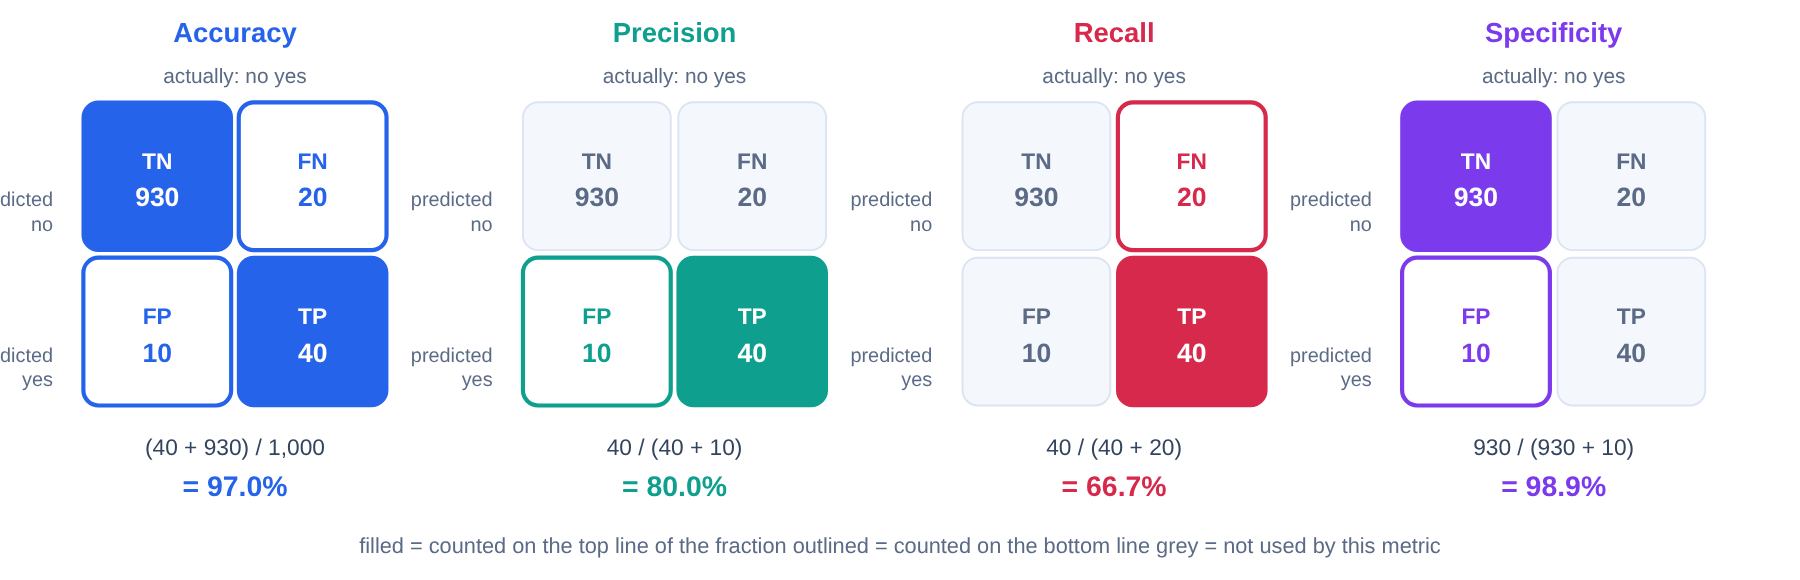

*The same four boxes, read four ways. Each metric asks “how many did we get right, out of which group?” — the outlined boxes are the group, the filled box is what was right in it.*

Every one of the four metrics is a fraction of these same boxes. Accuracy uses all four and is dominated by the 930; precision reads down the *flagged* row (40 of 50); recall reads across the *ill* column (40 of 60); specificity reads across the healthy column (930 of 940). The do-nothing model that flags nobody has TP = 0: its accuracy is 940 / 1,000 = 94%, its precision is undefined and its recall is 0.



#### The harmonic mean

> **Why $F_1$ uses a harmonic mean.** Precision and recall pull against each other: flagging more people can only raise recall and can only lower precision. $F_1$ combines them with a **harmonic mean**, which is deliberately harsh — unlike an ordinary average it stays close to the *smaller* of the two.
>
> **The harshness is the point.** A model with precision $1.00$ and recall $0.02$ has an ordinary average of $0.51$, which sounds respectable. Its $F_1$ is $2 \times (1.00 \times 0.02)/(1.00 + 0.02) = 0.04/1.02 = \mathbf{0.04}$. The harmonic mean does not let one excellent number cover for one terrible one.

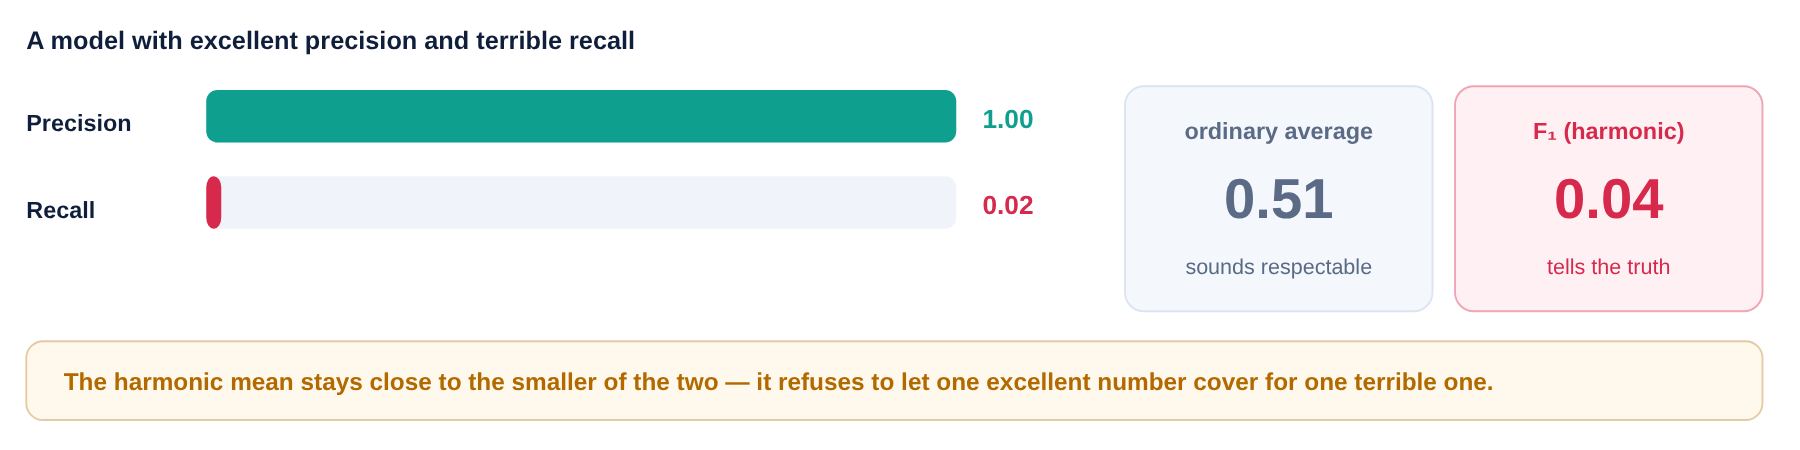

*Why F₁ is not just the average of precision and recall: an average would let this model look like a coin flip instead of the failure it is.*

The worked example is now reproduced in code, so that each of its numbers can be checked, and then the threshold is moved to see how the four boxes and the metrics change.



#### The steps

*What the cells below do*

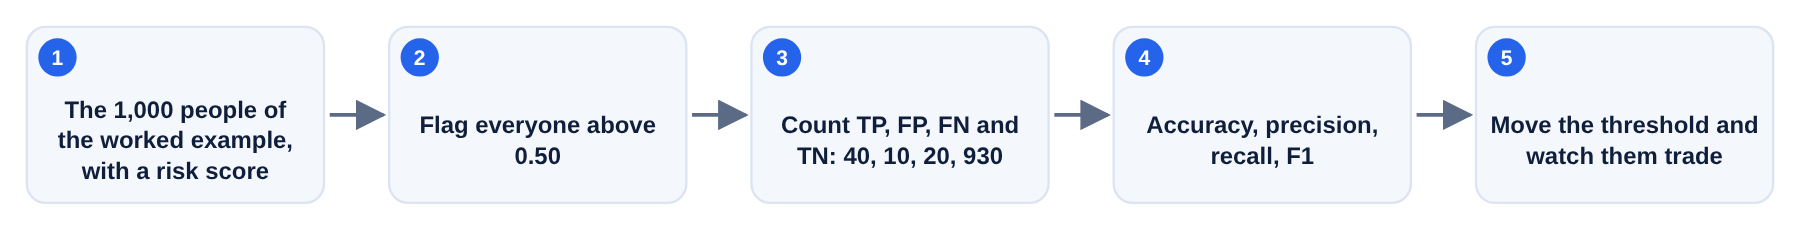

*The worked example again, this time computed: the same 1,000 people, the same four boxes, the same metrics.*



#### The worked example, in code

The same 1,000 people: 60 have the condition, 940 do not. A screening model gives each person a **risk score** between 0 and 1, and the person is flagged when the score is above a threshold. The scores here are drawn so that a threshold of 0.50 flags exactly the 50 people of the worked example — 40 ill and 10 healthy — so every number below can be checked against the table above, and later the threshold can be moved to see what changes. The first array records who is ill; the second holds the scores.



In [25]:
rng_eval = np.random.default_rng(4)
n_patients = 1_000
has_condition = np.r_[np.ones(60, dtype=bool), np.zeros(940, dtype=bool)]     # 60 ill, then 940 healthy
risk_score = np.empty(n_patients)
risk_score[:40]   = rng_eval.uniform(0.50, 0.95, 40)     # ill, and scored above 0.50
risk_score[40:60] = rng_eval.uniform(0.05, 0.50, 20)     # ill, but scored below
risk_score[60:70] = rng_eval.uniform(0.50, 0.95, 10)     # healthy, but scored above
risk_score[70:]   = rng_eval.uniform(0.05, 0.50, 930)    # healthy, scored below
print("people:", n_patients, " ill:", int(has_condition.sum()), " healthy:", int((~has_condition).sum()))
print("first six scores:", risk_score[:6].round(2))

people: 1000  ill: 60  healthy: 940
first six scores: [0.92 0.73 0.94 0.54 0.77 0.67]


#### The four boxes, counted

Flagging everyone above 0.50 gives one True/False per person. Each box is then a count of rows: `&` combines two True/False arrays row by row and is True only where both are; `~` flips True and False. Flagged and ill are the true positives; flagged but healthy the false positives; ill but not flagged the false negatives — the dangerous box in a screening; healthy and not flagged the true negatives, the big box. The four counts are then arranged as the 2 × 2 table, rows for the prediction and columns for the truth, in the same layout as the table and diagram earlier in this section.



In [26]:
predicted = risk_score > 0.50
true_positive  = int((predicted & has_condition).sum())      # flagged and ill
false_positive = int((predicted & ~has_condition).sum())     # flagged but healthy
false_negative = int((~predicted & has_condition).sum())     # ill but missed
true_negative  = int((~predicted & ~has_condition).sum())    # healthy and left alone
print("flagged:", int(predicted.sum()), "   TP", true_positive, " FP", false_positive, " FN", false_negative, " TN", true_negative)
matrix = np.array([[true_negative, false_negative],
                   [false_positive, true_positive]])
matrix

flagged: 50    TP 40  FP 10  FN 20  TN 930


array([[930,  20],
       [ 10,  40]])

#### The four metrics

Every metric is these four numbers divided by some group of them, and the cell computes all four; they should match the worked example's table line for line. Accuracy is correct decisions of either kind over all 1,000 people, high because of the 930; precision divides the 40 true positives by the 50 flagged; recall divides them by the 60 who were ill; F1 is the harmonic mean of the last two, closer to the smaller one.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$F_{1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$



In [27]:
accuracy = (true_positive + true_negative) / n_patients
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
f1 = 2 * precision * recall / (precision + recall)
print(f"accuracy {accuracy:.3f}   precision {precision:.3f}   recall {recall:.3f}   F1 {f1:.3f}")

accuracy 0.970   precision 0.800   recall 0.667   F1 0.727


#### The accuracy of doing nothing

For comparison: a model that flags nobody is right about every healthy patient and wrong about every ill one. Its accuracy is the share of healthy patients — the number the real model has to beat, and it barely does.



> **Interpretation.** The screening scores 97% accuracy; the do-nothing model scores 94%. Three points apart by accuracy, after the screening caught 40 real cases and the do-nothing model caught none. By recall the two are 66.7% against 0 — which is why a screening is judged on recall and precision, not on accuracy.



In [28]:
round(float((~has_condition).mean()), 3)

0.94

#### Precision, recall and accuracy at every threshold

The 0.50 threshold was a default, not a law. The same 1,000 people can be flagged at any threshold, and moving it trades one kind of mistake for the other; this cell makes the trade visible: 181 thresholds from 0.05 to 0.95 are tried, and for each one the people are re-flagged and the three measures recomputed. A lenient, a middle and a strict threshold are printed side by side — read down: as the threshold rises, precision rises and recall falls, every time.



In [29]:
thresholds = np.linspace(0.05, 0.95, 181)      # steps of 0.005, so 0.50 itself is one of them
precisions, recalls, accuracies = [], [], []
for threshold in thresholds:
    flagged = risk_score > threshold
    tp = (flagged & has_condition).sum()
    precisions.append(tp / flagged.sum() if flagged.sum() else np.nan)
    recalls.append(tp / has_condition.sum())
    accuracies.append((flagged == has_condition).mean())

for t in (0.20, 0.50, 0.80):
    i = int(np.argmin(np.abs(thresholds - t)))          # the prepared threshold closest to t
    print(f"threshold {thresholds[i]:.2f} -> precision {precisions[i]:.1%}, "
          f"recall {recalls[i]:.1%}, accuracy {accuracies[i]:.1%}")

threshold 0.20 -> precision 7.8%, recall 91.7%, accuracy 34.9%
threshold 0.50 -> precision 80.0%, recall 66.7%, accuracy 97.0%
threshold 0.80 -> precision 75.0%, recall 25.0%, accuracy 95.0%


#### The confusion matrix and the trade-off

Left, the four counts as a heat map. Right, precision, recall and accuracy as the threshold moves, with the 0.50 default marked.



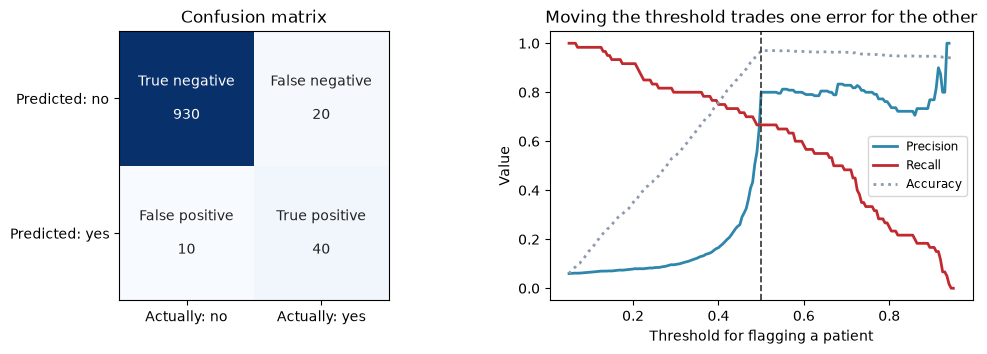

In [30]:
fig, (ax_cm, ax_curve) = plt.subplots(1, 2, figsize=(12, 3.5))

ax_cm.imshow(matrix, cmap="Blues")
labels = [["True negative", "False negative"], ["False positive", "True positive"]]
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f"{labels[i][j]}\n\n{matrix[i, j]:,}", ha="center", va="center",
                   fontsize=10, color="white" if matrix[i, j] > matrix.max() / 2 else "#222")
ax_cm.set_xticks([0, 1], ["Actually: no", "Actually: yes"])
ax_cm.set_yticks([0, 1], ["Predicted: no", "Predicted: yes"])
ax_cm.set_title("Confusion matrix")
ax_cm.grid(False)

ax_curve.plot(thresholds, precisions, linewidth=2, color="#2E86AB", label="Precision")
ax_curve.plot(thresholds, recalls, linewidth=2, color="#C1292E", label="Recall")
ax_curve.plot(thresholds, accuracies, linewidth=2, linestyle=":", color="#8D99AE", label="Accuracy")
ax_curve.axvline(0.50, color="#333", linestyle="--", linewidth=1.2)
ax_curve.set_xlabel("Threshold for flagging a patient")
ax_curve.set_ylabel("Value")
ax_curve.set_title("Moving the threshold trades one error for the other")
ax_curve.legend(fontsize=8.5)
plt.show()

#### What the chart shows

> **Interpretation.** Two panels:
>
> - **Left — the matrix** separates the two kinds of mistake that accuracy fuses together: 20 **false negatives** (sick people sent home) and 10 **false positives** (healthy people called back). In a screening the two are not remotely equivalent.
> - **Right — precision (blue) rises and recall (red) falls** as the threshold moves right; lower it and the reverse. No threshold makes both high on overlapping scores.
> - **The dotted accuracy line barely moves** from 0.50 upward — the subject of the next cell.
> - So the threshold is a **business decision, not a technical one**: it sets which mistake you would rather make.



#### Reading the right-hand panel

> **Accuracy barely notices the threshold.** From 0.50 upward the dotted accuracy line is almost flat — between 97% and 94% — while recall falls from 66.7% to 17%: two thirds of the real cases can be lost with accuracy barely moving, because 940 of the 1,000 people are healthy and **getting the healthy people right is most of accuracy**. A model that flags nobody already scores 94%. Only when the threshold drops far enough to flag hundreds of healthy people does accuracy fall, and by then precision has collapsed. Accuracy is nearly blind to the decision that matters in a screening; recall and precision see it.



#### Which metric to use

| Metric | Formula | Use when |
|---|---|---|
| **Accuracy** | (TP + TN) / all | Classes are balanced and both errors cost the same |
| **Precision** | TP / (TP + FP) | Acting on a flag is expensive |
| **Recall** | TP / (TP + FN) | Missing a case is expensive |
| **F1** | 2PR / (P + R) | One number is needed and both errors matter |

> **A note on convention.** The chart, the table and the diagram in this section all lay the four boxes out the same way: **rows are what the model predicted**, columns are the truth. Most libraries and many textbooks print the transpose — actual down the side, predicted across the top. The four counts are identical either way; only the layout flips, so read the axis labels before reading any confusion matrix.

> **Try it.** Find the threshold that gives at least 90% recall, and report the precision it costs. Would you deploy that model in a hospital? In a spam filter?

This completes the evaluation toolkit: a fair procedure (Section 9.3.2, Section 9.3.4) and a score that cannot be fooled by a rare class (Section 9.3.5). Two short sections close the supervised family — the other task it covers, and the algorithms real projects use.



### 9.3.6 Classification and regression

*Same family, different kind of output*

Everything in Sections 9.3.1–9.3.5 predicted a *class*. Supervised learning has a second task, in which the answer is a number, and the two are learned and evaluated the same way — from labeled examples, scored on unseen data. They differ only in the kind of answer:

**Classification**

Predicts a **discrete** class.
Flu / No flu  ·  S / M / L  ·  Cold / Hot

**Regression**

Predicts a **continuous** number.
a temperature  ·  a price  ·  a weight



#### The two tasks

Two small charts side by side: three buckets for classification, and scattered points with a fitted line for regression. The polynomial fits of Section 9.3.3 were regression — the degree-4 curve predicted a number, y, from x.



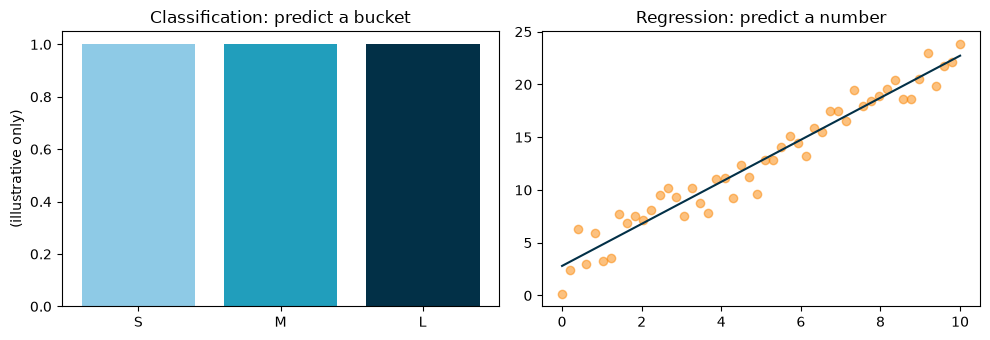

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(["S", "M", "L"], [1, 1, 1], color=["#8ECAE6", "#219EBC", "#023047"])
axes[0].set_title("Classification: predict a bucket")
axes[0].set_ylabel("(illustrative only)")

x = np.linspace(0, 10, 50)
y_line = 2 * x + 3 + rng.normal(0, 2, 50)
axes[1].scatter(x, y_line, alpha=0.5, color="#FB8500")
slope, intercept = np.polyfit(x, y_line, 1)              # the best straight line through the points
axes[1].plot(x, slope * x + intercept, color="#023047")
axes[1].set_title("Regression: predict a number")

plt.tight_layout()
plt.show()

#### Classification or regression — four cases

> **Try it.** Which is each of these?
>
> - (a) predicting tomorrow's exact temperature in °C
> - (b) predicting whether tomorrow will be “hot” or “cold”
> - (c) predicting a student's final exam score
> - (d) predicting whether a student will pass or fail
>
> *Answer.* - **(a) regression** — a temperature in °C is a continuous number.
> - **(b) classification** — “hot” and “cold” are two discrete buckets.
> - **(c) regression** — an exam score is a number on a continuous scale.
> - **(d) classification** — pass and fail are two categories.
>
> (a) and (b) use the **same data** and differ only in the *question asked*. Classification and regression are not different data; they are different targets. Turning a number into buckets (“hot” = above 30°) converts a regression problem into a classification one — a choice you make, not something the data forces.



### 9.3.7 Named algorithms for each task

*What real projects reach for*

The nearest-neighbor rule of Section 9.3.1 is one way to do classification and the polynomial fit of Section 9.3.3 one way to do regression, but real projects reach for named, well-tested algorithms. Chapter 10 builds several of these from scratch and evaluates them with exactly the tools of Sections 9.3.2–9.3.5:

| Classification | Regression |
|---|---|
| Logistic regression | Linear regression |
| Naive Bayes | Decision tree regression |
| K-nearest neighbors | Support vector regression |
| Decision tree | Lasso regression |
| Support vector machines | Random forest |

> **The same pattern, another application.** A credit card company receives thousands of applications, each listing attributes like age, job status, housing and credit rating. The problem is to classify every application as *approved* or *not approved* — the same nearest-neighbor thinking as Section 9.3.1, with different attributes and a different label.

> **Where this leaves us.** Every method in this section needed one thing: a label on every training example. Section 9.4 asks what can be learned when there are no labels at all.



## 9.4 · Unsupervised learning

*No labels, no right answers — structure waiting to be found*

Section 9.3 needed a label on every training row. The second row of the map in Section 9.2 drops that requirement: the data has inputs only, and the task is to find whatever structure is already in it. Two kinds of structure are looked for — groups of similar rows, and rules about what goes together — and this section builds one method for each, again by hand first and then in code. One thing changes from Section 9.3 and colors everything here: with no labels, there is no longer a right answer to score against.

> **Definition.** Unsupervised learning focuses on the **input only**. It has no knowledge of the “right answer”, because no right answers exist in the data. Instead it tries to **group together similar items** or **find rules that describe the data**.

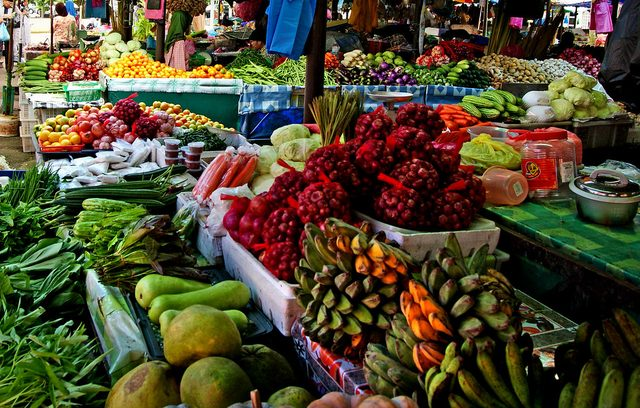

*A market stall: produce sorted into groups by resemblance, with no label telling the sorter where each item belongs. Clustering does the same with rows of data. — Photo: “Local produce. Tamu Kianggeh Brunei.” by Bernard Spragg, CC0 — flickr.com*



#### The two tasks, and a caution

| Task | What it discovers | Typical business use |
|---|---|---|
| **Clustering (Section 9.4.1, Section 9.4.2)** | The groupings already present in the data — which rows resemble which other rows | Grouping customers by purchasing behavior, so each group can be marketed to differently |
| **Association (Section 9.4.3)** | Rules that describe large portions of the data, of the form “X implies Y” | “People who buy X also tend to buy Y” — shelf layout, bundle offers, recommendations |

> **Clustering is subjective.** With supervised learning there is a right answer, so a model can be called correct. With clustering there usually is not. Take nine cartoon characters: they could be grouped **by family**, **by workplace**, or **by gender**, and all three groupings are valid — they answer different questions. Which one is “correct” depends on what the groups are for.



#### Two valid clusterings

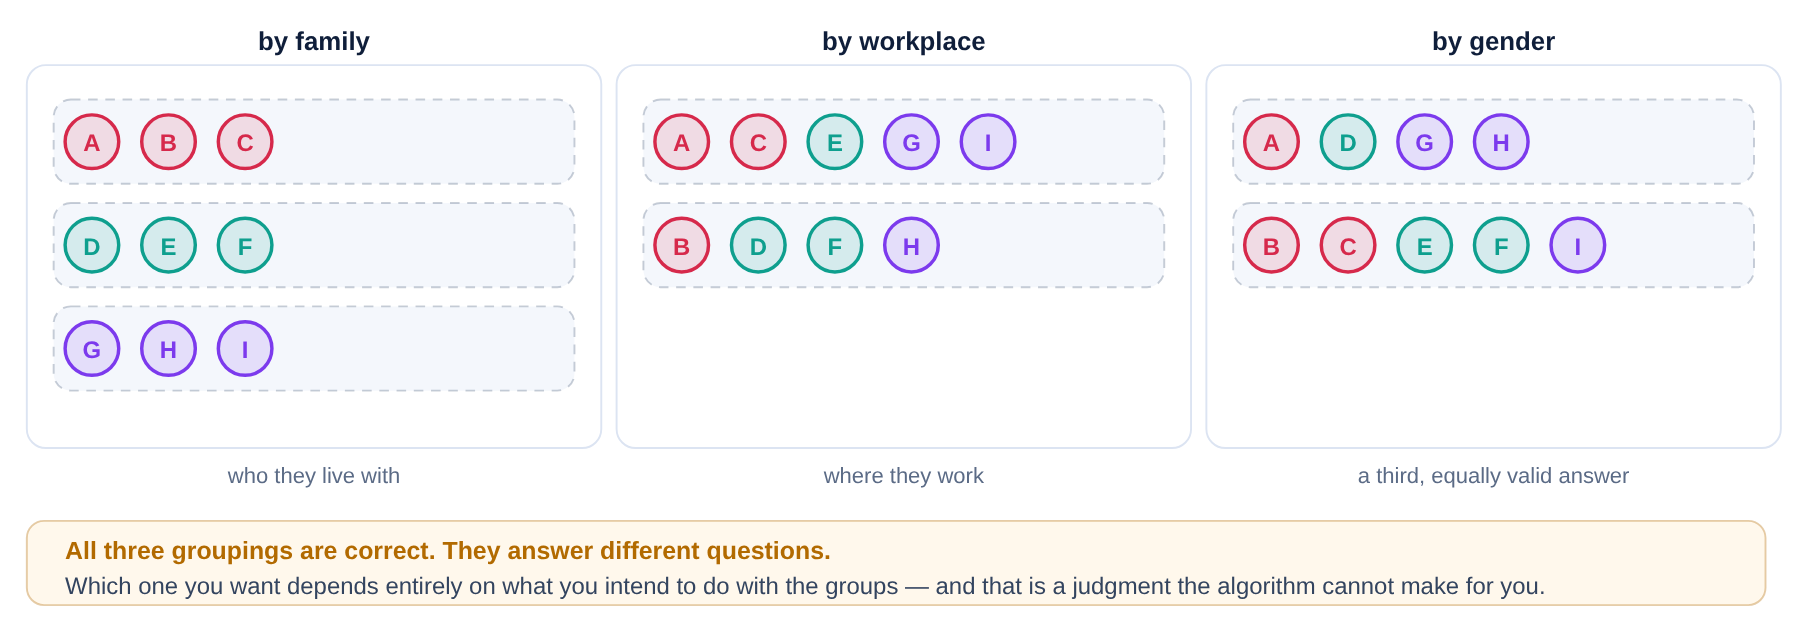

*The same nine characters, clustered three ways. Unlike supervised learning there is no answer key here, so “is this clustering right?” is not a question with an answer.*

> **The practical consequence.** When customers are clustered into four groups, the algorithm has not told you the truth about the customers. It has told you that *under the features you chose and the distance you defined*, these rows resemble each other. Change the features and the groups change, and neither result is wrong. **Choosing what to measure is where the judgment lies.** With that understood, the most widely used clustering algorithm comes first.



### 9.4.1 K-means clustering

*The most widely used clustering algorithm*

K-means groups points into `k` clusters with a loop that repeats until nothing changes. Every step uses the distance idea from Section 9.3.1 — a point belongs with the center it is closest to — and no step ever looks at a label:

1. **Choose `k`** — How many clusters you want. You decide this up front; the algorithm will not say what the right number is.
2. **Pick `k` random points as the initial centroids** — A **centroid** is the center of a cluster — a position, not necessarily one of the data points.
3. **Assign every point to its nearest centroid** — Each point is now a member of exactly one cluster.
4. **Recompute each centroid as the mean position of its members** — The cluster's center of gravity moves to where its members are.
5. **Repeat steps 3–4 until the centroids stop moving** — That is the **stopping criterion**.



#### The K-means loop

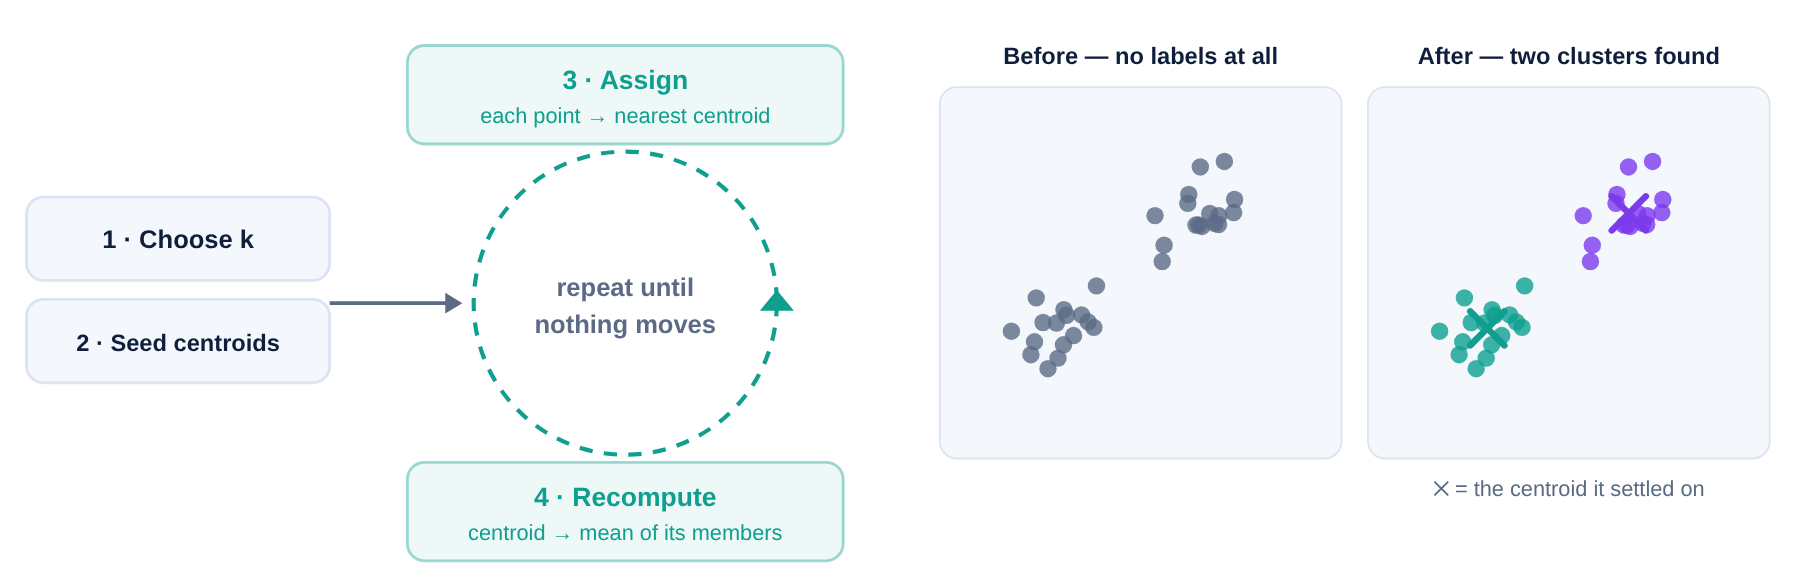

*Two steps, repeated. **You** pick k; the algorithm never questions it. Neither step can make the clusters worse, which is why the loop always comes to a stop.*



#### The quantity the loop minimizes

*chasing one number as low as it will go*

Call the clusters $C_1, \dots, C_k$ and their centers $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$. K-means is trying to make the **total spread** as small as possible:

$$J = \sum_{i=1}^{k} \; \sum_{\mathbf{x} \,\in\, C_i} \left\lVert \mathbf{x} - \boldsymbol{\mu}_i \right\rVert^{2}$$

The inner $\sum$ says *“for every point in this cluster, measure how far it is from its own center, square that distance, and add them up”*. The outer $\sum$ says *“now do that for every cluster and add those totals too”*. So $J$ is one number describing how spread out all the clusters are — **small $J$ means tight clusters**.

> **Worked example.** Four shops at $(1,1)$, $(1,3)$, $(6,5)$, $(8,5)$.
>
> **A sensible grouping**
>
> $\{(1,1),(1,3)\}$ and $\{(6,5),(8,5)\}$.
>
> First center: $\left(\frac{1+1}{2}, \frac{1+3}{2}\right) = (1,2)$. Both points are $1$ away → squared, $1 + 1 = 2$.
> Second center: $(7,5)$. Both points are $1$ away → $1 + 1 = 2$.
>
> **$J = 2 + 2 = 4$**
>
> **A poor grouping**
>
> $\{(1,1),(8,5)\}$ and $\{(1,3),(6,5)\}$.
>
> First center $(4.5, 3)$: squared distance $12.25 + 4 = 16.25$ each → total $32.5$.
> Second center $(3.5,4)$: squared distance $6.25 + 1 = 7.25$ each → total $14.5$.
>
> **$J = 32.5 + 14.5 = 47$**
>
> $4$ against $47$. The number knows which grouping is better without anyone being told the answer — which is what makes an unsupervised method possible at all.



#### J for two clusterings

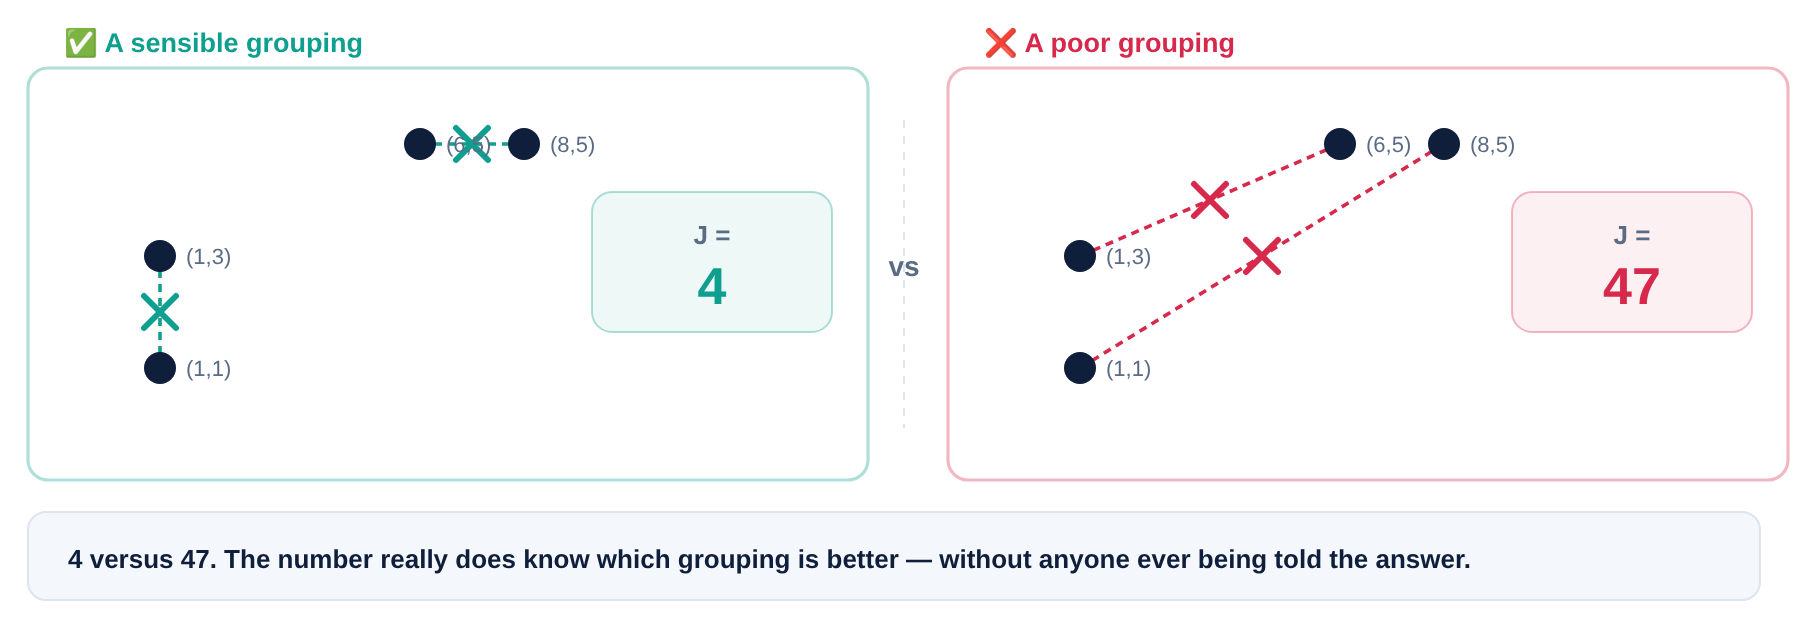

*J adds up how far every shop sits from its own ✕. Tight groups make it small, so “minimize J” and “find the natural clusters” turn out to be the same instruction.*



#### The loop always stops

Each of the two repeated steps can only push $J$ down, never up:

- **Step 3 — assign** — Keeps the centers still and moves each point to the nearest one. A point only moves if the new center is closer, which shrinks its own contribution to $J$ and leaves everyone else's untouched.
- **Step 4 — recompute** — Keeps the groups still and moves each center to the average of its members. The average is the single position with the smallest total squared distance to a set of points, so this step cannot make things worse either.

$J$ therefore keeps falling and can never go below $0$. Since there are only so many ways to sort $n$ points into $k$ groups, the algorithm cannot improve forever: it must reach a round where nothing moves, and there it stops.

> **What that does not promise.** This guarantees *a* good arrangement, not *the best* one. A different random start can settle somewhere else, which is why real implementations run the whole thing several times and keep the run that ended with the smallest $J$.

> **Definition.** K-means is **hard clustering**: every point ends up in exactly one cluster. In *soft* clustering a point can partly belong to several; Chapter 11 covers that distinction. The loop is now built in code on data with two clear groups, so that the answer can be checked by eye.



#### The steps

*What the cells below do*

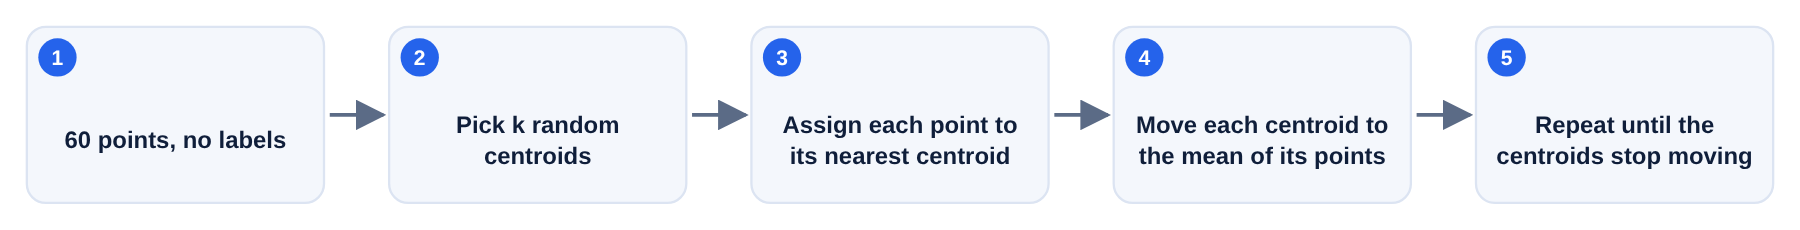

*K-means as the code runs it: the loop of Section 9.4.1 with the data first.*



#### Sixty points, and nothing else

`rng.normal(loc=(2, 2), scale=0.6, size=(30, 2))` draws 30 points scattered around the position (2, 2) — `size=(30, 2)` means 30 rows and 2 columns, an x and a y for each point — and a second call draws 30 more around (7, 7). The two groups are far apart on purpose, so that whether the algorithm found them can be seen at a glance; on real data there would be nothing to check against. Both are stacked into one array of 60 rows, which is all the algorithm receives — no column says which group a point came from.



In [32]:
group_1 = rng.normal(loc=(2, 2), scale=0.6, size=(30, 2))
group_2 = rng.normal(loc=(7, 7), scale=0.6, size=(30, 2))
points = np.vstack([group_1, group_2])
print("first three points of each group:\n", group_1[:3].round(2), "\n", group_2[:3].round(2))
print("points:", points.shape)

first three points of each group:
 [[1.8  2.12]
 [2.11 2.5 ]
 [3.81 2.82]] 
 [[6.37 6.97]
 [6.84 6.66]
 [7.75 7.16]]
points: (60, 2)


#### The K-means function

The five steps of the loop, in order. Step 2 picks k of the points at random as the starting centroids. Inside the loop, step 3 measures every point's distance to every centroid and assigns each point to the nearest (`argmin` gives the column with the smallest distance); step 4 moves each centroid to the mean of its members; step 5 stops when the centroids no longer move. `n_iterations=10` is a default — used unless the caller says otherwise.



In [33]:
def kmeans(points, k, n_iterations=10, seed=888102):
    local_rng = np.random.default_rng(seed)
    centroids = points[local_rng.choice(len(points), size=k, replace=False)]   # step 2
    for _ in range(n_iterations):
        # step 3: assign every point to its nearest centroid
        distances = np.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=2)
        assignments = distances.argmin(axis=1)
        # step 4: move each centroid to the mean of its members
        new_centroids = np.array([points[assignments == c].mean(axis=0) for c in range(k)])
        if np.allclose(new_centroids, centroids):
            break                                  # step 5: the centroids stopped moving
        centroids = new_centroids
    return assignments, centroids

#### Running it with k = 2

The function returns two things: a cluster number for every point, and the final position of each centroid — to be compared with the centers (2, 2) and (7, 7) that the data was drawn around.



> **Interpretation.** The centroids sit close to the middle of each group. Nobody told the algorithm where the groups were; it reached these positions from the geometry of the points alone, which is what makes it unsupervised.



In [34]:
assignments, centroids = kmeans(points, k=2)
print("cluster of each point:", assignments)
centroids.round(2)

cluster of each point: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


array([[1.94, 1.99],
       [6.94, 6.96]])

#### The clusters

Each point colored by its cluster, with the two centroids marked as crosses.



> **Interpretation.** The algorithm never saw a label saying “these are group 1”. It discovered the two clusters from the positions of the points and placed a centroid at the middle of each. The loop stopped because the centroids quit moving — the stopping criterion in action.



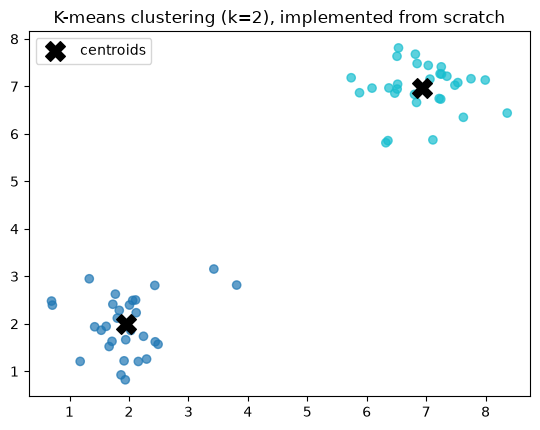

In [35]:
plt.figure(figsize=(5.5, 4.4))
plt.scatter(points[:, 0], points[:, 1], c=assignments, cmap="tab10", alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=200, label="centroids")
plt.legend()
plt.title("K-means clustering (k=2), implemented from scratch")
plt.tight_layout()
plt.show()

#### Asking for a third cluster

> **Try it.** Change `k=2` to `k=3` in the `kmeans(points, k=2)` call above and run the two cells again. The data has two real groups. What happens to the third cluster?
>
> *Answer.* K-means always produces exactly the number of clusters asked for; it has no way to say “there are only two groups here”. With `k=3` it slices one genuine cluster in half, and the two halves sit side by side with no gap between them. That is the tell-tale sign of a `k` that is too large — and the reason the next part is about choosing k.



#### Choosing k — the elbow method

*computed rather than described*

Step 1 of the loop said k must be chosen up front. The usual way to choose it is to run K-means for k = 1, 2, 3, … and watch how tight the clusters get.

> **Definition.** The quantity watched is **inertia** (also called within-cluster sum of squares): the total squared distance from every point to its own centroid. Inertia is another name for the $J$ above, now watched as $k$ changes.

> **Watch out.** Inertia is guaranteed to fall every time a cluster is added — more centers means every point has a nearer one available — and it reaches exactly $0$ when every point is its own cluster. **A number that always improves cannot pick the best $k$ on its own.** So the elbow method ignores the value and looks at the *drop* from one $k$ to the next.

**Worked example.** Suppose the inertia comes out as:

| $k$ | Inertia $J(k)$ | Drop from the previous $k$ |
|:-:|--:|--:|
| **1** | $100$ | — |
| **2** | $30$ | $100 - 30 = \mathbf{70}$ |
| **3** | $25$ | $30 - 25 = 5$ |
| **4** | $22$ | $25 - 22 = 3$ |
| **5** | $20$ | $22 - 20 = 2$ |

Going from 1 to 2 clusters buys a drop of **70**. Going from 2 to 3 buys **5**. Everything after that is small change. The “elbow” — where the improvement suddenly stops being worth it — is at $k = 2$, and that is the answer. Past the elbow you are splitting groups that were already tight.



#### Choosing k

*What the cells below do*

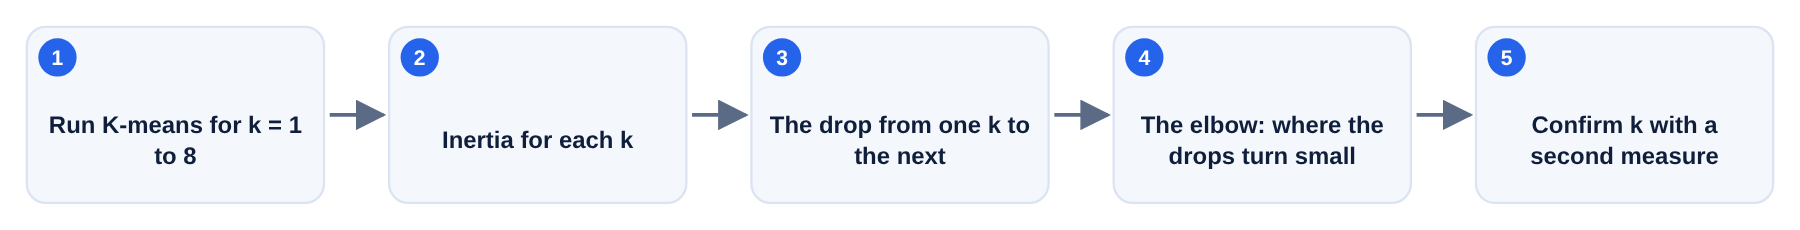

*Two ways to choose k, computed rather than described.*



#### The inertia function

The function runs K-means for a given k and then adds up, over every cluster, the squared distance from each point to its own centroid — the $J$ formula, computed.

$$J = \sum_{i=1}^{k} \; \sum_{\mathbf{x} \,\in\, C_i} \left\lVert \mathbf{x} - \boldsymbol{\mu}_i \right\rVert^{2}$$



In [36]:
def inertia_for(points, k, seed=888102):
    """Run k-means for this k, then total the squared distance from every point to its own centroid."""
    assignments, centroids = kmeans(points, k=k, seed=seed)
    return float(sum(((points[assignments == c] - centroids[c]) ** 2).sum() for c in range(k)))

#### Inertia for every k, and the drop between neighbors

The function is called for k from 1 to 8. `np.diff` then takes the difference between consecutive inertias — the minus sign turns the falls into positive amounts — so each entry of the second column is how much the extra cluster bought. Both are shown in one table.



> **Interpretation.** Inertia falls at every single step, as it must: more centroids means every point has a nearer one available, so the number alone cannot say which k is best. The drops can: a very large one going to k = 2, then almost nothing. That is the elbow stated as numbers rather than as a bend to squint at — the k where the drops become small is the k to take.



In [37]:
k_values = range(1, 9)
inertias = [inertia_for(points, k) for k in k_values]
improvements = [np.nan] + list(-np.diff(inertias))          # no drop before the first k
pd.DataFrame({"inertia": np.round(inertias, 1), "drop from previous k": np.round(improvements, 1)},
             index=pd.Index(list(k_values), name="k"))

,inertia,drop from previous k
k,,
1,786.4,NaN
2,41.1,745.2
3,35.1,6.1
4,30.2,4.9
5,29.1,1.1
6,21.2,7.9
7,16.1,5.1
8,11.7,4.4


#### The elbow

Left, inertia against k, with the elbow circled. Right, the drop bought by each extra cluster.



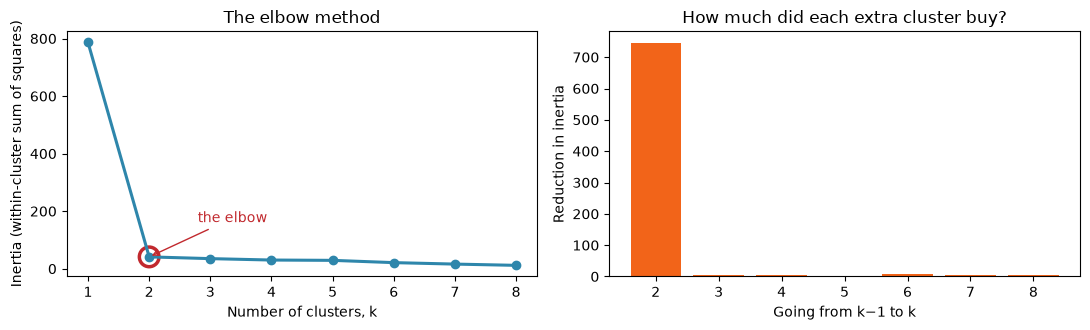

In [38]:
fig, (ax_elbow, ax_drop) = plt.subplots(1, 2, figsize=(11, 3.4))

ax_elbow.plot(k_values, inertias, marker="o", linewidth=2.2, color="#2E86AB")
ax_elbow.scatter([2], [inertias[1]], s=200, facecolors="none", edgecolors="#C1292E", linewidth=2.5)
ax_elbow.annotate("the elbow", (2, inertias[1]), textcoords="offset points",
                  xytext=(35, 25), fontsize=10, color="#C1292E",
                  arrowprops=dict(arrowstyle="->", color="#C1292E"))
ax_elbow.set_xlabel("Number of clusters, k")
ax_elbow.set_ylabel("Inertia (within-cluster sum of squares)")
ax_elbow.set_title("The elbow method")

ax_drop.bar(list(k_values)[1:], improvements[1:], color="#F26419")
ax_drop.set_xlabel("Going from k−1 to k")
ax_drop.set_ylabel("Reduction in inertia")
ax_drop.set_title("How much did each extra cluster buy?")

plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** Two panels, one answer:
>
> - **Left** — inertia drops steeply from k = 1 to k = 2, then flattens. The bend is the elbow: the point where extra clusters stop buying much.
> - **Right** — the first extra cluster removes almost all the inertia; every one after it removes very little.
> - The data was generated as two groups, so **k = 2** is the correct answer, and the elbow found it.



#### A second opinion — the silhouette score

> **Elbows are often ambiguous.** Real data frequently produces a smooth curve with no clear bend, and two analysts will read it differently. The **silhouette score** is a second opinion that gives a number rather than a shape: for each point it compares how close the point is to its own cluster (a) with how close it is to the nearest other cluster (b). The score (b − a) / max(a, b) runs from −1 (the point is in the wrong cluster) through 0 (on the boundary) to +1 (comfortably placed), and the average over all points scores the clustering.



#### The silhouette function

For each point the function computes a — the mean distance to the other points in its own cluster — and b — the smallest mean distance to the points of any other cluster — and averages (b − a) / max(a, b) over all points.

$$s = \frac{b - a}{\max(a, b)}$$

$a$: mean distance to the other points in the same cluster; $b$: mean distance to the points of the nearest other cluster. The score of a clustering is the average $s$.



In [39]:
def silhouette_score(points, assignments):
    scores = []
    for i, point in enumerate(points):
        own = assignments[i]
        same = points[assignments == own]
        same = same[~np.all(same == point, axis=1)] if len(same) > 1 else same   # leave the point itself out
        a = np.linalg.norm(same - point, axis=1).mean() if len(same) else 0.0
        b = min(np.linalg.norm(points[assignments == other] - point, axis=1).mean()
                for other in set(assignments) if other != own)
        scores.append((b - a) / max(a, b) if max(a, b) > 0 else 0.0)
    return float(np.mean(scores))

#### Inertia and silhouette side by side

K-means is run for k from 2 to 8 (a silhouette needs at least two clusters) and the two measures are printed together. Unlike inertia, the silhouette is a number to *maximize*: `np.argmax` finds the position of the largest score and the k at that position is read off.



> **Interpretation.** The silhouette peaks at k = 2 and falls away, agreeing with the elbow. Its advantage is that it is a number to maximize rather than a shape to interpret, which removes the argument between two readers of the same curve.



In [40]:
print(f"{'k':>3} {'inertia':>10} {'silhouette':>12}")
silhouettes = []
for k in range(2, 9):
    assignments_k, _ = kmeans(points, k=k)
    score = silhouette_score(points, assignments_k)
    silhouettes.append(score)
    print(f"{k:>3} {inertia_for(points, k):>10.1f} {score:>12.3f}")
best_k = list(range(2, 9))[int(np.argmax(silhouettes))]
print(f"\nHighest silhouette at k = {best_k}")

  k    inertia   silhouette
  2       41.1        0.850
  3       35.1        0.566
  4       30.2        0.584


  5       29.1        0.564
  6       21.2        0.302


  7       16.1        0.327
  8       11.7        0.415

Highest silhouette at k = 2


#### A caveat for every clustering method

> **Separable is not the same as meaningful.** K-means returns exactly the k clusters asked for, whether or not k clusters exist. Neither the elbow nor the silhouette can say that the groups are *meaningful* — only that they are geometrically separable. Deciding whether “cluster 2” corresponds to a real kind of customer is a domain judgment, and Chapter 11 returns to it.

K-means has one more limitation: k must be chosen before the algorithm runs. The next method removes that requirement by producing every k at once.



### 9.4.2 Hierarchical clustering — merging step by step

*One run gives every k at once*

> **Definition.** K-means makes you commit to `k` before you start. **Hierarchical clustering** does not: it builds a whole **tree** of clusters, from “every point alone” at one end to “everything in one group” at the other, and the tree is cut at whichever level suits afterwards. That tree, drawn as a diagram, is called a **dendrogram**.

| Method | Direction | How it proceeds |
|---|---|---|
| **Agglomerative (AGNES)** | Bottom-up | Every point starts as its own cluster. At each step the **two most similar clusters merge**. Continue until one cluster remains. |
| **Divisive (DIANA)** | Top-down | Everything starts in one cluster. At each step the **most mixed-up cluster splits in two**. Continue until every point is alone. |

Agglomerative is by far the more common of the two, and it is the one built below. It needs one new idea first: the distance from Section 9.3.1 was between two *points*, and this method has to measure the distance between two *clusters*.



#### Defining the distance between two clusters

Two single points have an obvious distance, but once a cluster holds three points, which distance counts? The common answers are called **linkages**:

- **Single linkage** — The distance between the two *closest* members. Clusters can end up long and stringy.
- **Complete linkage** — The distance between the two *furthest* members. Produces compact, round clusters.
- **Average linkage** — The *mean* distance over every pair of members, one from each cluster. This is what the code below uses.



#### Three linkages

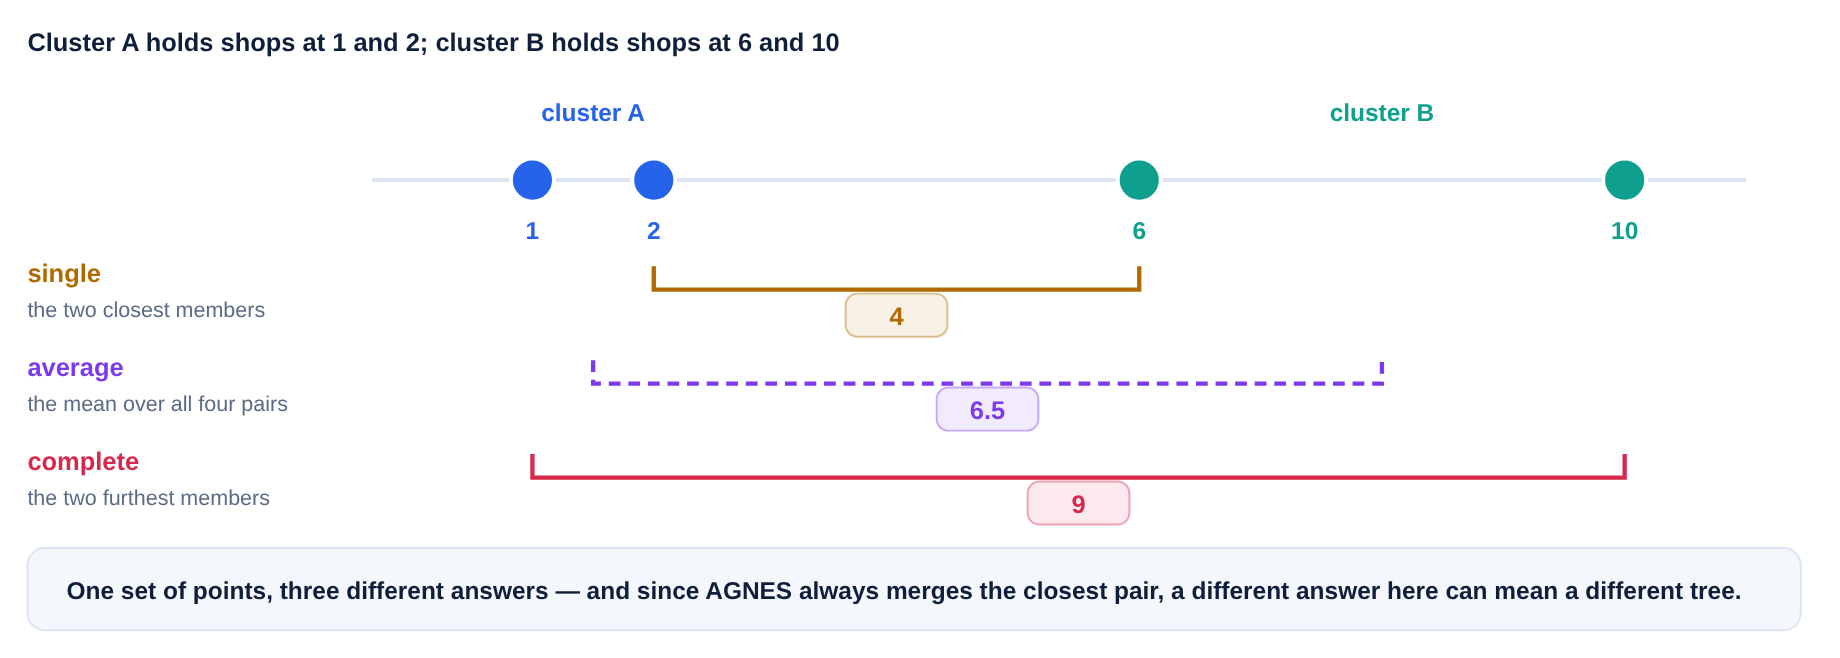

*All three linkages read the same four pairwise distances. They differ only in what they do with the list: take the smallest, the largest, or the average.*



#### The linkage formulas

$$d_{\text{single}}(A,B) = \min_{\mathbf{a} \in A,\, \mathbf{b} \in B} d(\mathbf{a}, \mathbf{b}) \qquad d_{\text{complete}}(A,B) = \max_{\mathbf{a} \in A,\, \mathbf{b} \in B} d(\mathbf{a}, \mathbf{b})$$

$$d_{\text{average}}(A,B) = \frac{1}{\lvert A \rvert \, \lvert B \rvert} \sum_{\mathbf{a} \in A} \sum_{\mathbf{b} \in B} d(\mathbf{a}, \mathbf{b})$$

All three look at *the same list of point-to-point distances between the two clusters* and differ only in what they do with that list: take the smallest, take the largest, or take the average. $\lvert A \rvert$ means “how many points are in $A$”, so $\lvert A \rvert \lvert B \rvert$ is how many pairs there are.

**Worked example.** Cluster $A$ holds two shops at positions $1$ and $2$ along a road; cluster $B$ holds two at $6$ and $10$. There are $2 \times 2 = 4$ pairs:

| Pair | Distance |
|---|---|
| **$1 \leftrightarrow 6$** | $\lvert 1 - 6 \rvert = 5$ |
| **$1 \leftrightarrow 10$** | $\lvert 1 - 10 \rvert = \mathbf{9}$ ← largest |
| **$2 \leftrightarrow 6$** | $\lvert 2 - 6 \rvert = \mathbf{4}$ ← smallest |
| **$2 \leftrightarrow 10$** | $\lvert 2 - 10 \rvert = 8$ |

- **Single linkage** takes the smallest: $\mathbf{4}$.
- **Complete linkage** takes the largest: $\mathbf{9}$.
- **Average linkage** takes the mean of all four: $(5 + 9 + 4 + 8) / 4 = 26/4 = \mathbf{6.5}$.

One set of points, three different answers. Since the algorithm always merges the *closest* pair of clusters, a different answer here can mean a different merge, and so a different tree.

> **Behavior of the three linkages.** **Single linkage** needs only one close pair, so it joins up long, chain-like shapes — good for elongated clusters, poor when two distinct groups happen to have a pair of neighbors touching. **Complete linkage** demands that *every* pair be close, so it favors compact round clusters and tends to chop long ones in half. **Average linkage** sits between the two, which is why it is the usual default.



#### The five points to be merged

The example is kept small enough to follow every merge: `a(0,0)`, `b(0,1)`, `c(5,5)`, `d(5,6)`, `e(6,5)`. By eye, `a` and `b` sit together near the origin and `c`, `d`, `e` form a separate group some distance away. With average linkage, the merge order works out as:

| Step | Merge | Distance |
|:-:|:--|--:|
| **1** | a + b | 1.00 |
| **2** | c + d | 1.00 |
| **3** | e + (c+d) | 1.21 |
| **4** | (a+b) + (e+c+d) | **7.23** |



#### AGNES and DIANA

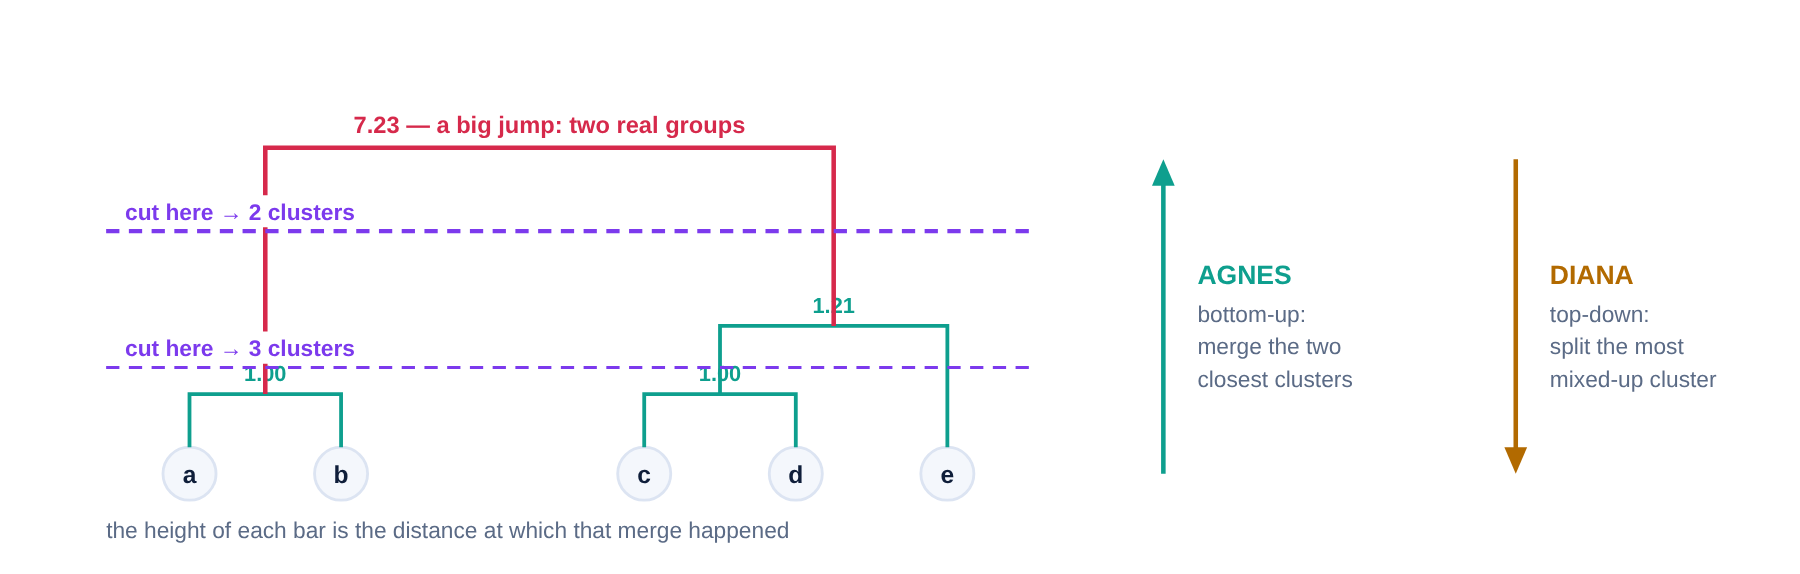

*One run gives you every k. Slide the dashed line up or down and read off a different number of clusters — no re-running anything.*

> **Key idea.** The height at which two branches join **is** the distance at which they merged, so a tall join means the two groups were far apart. The last merge costs 7.23 while every earlier one cost about 1 — that jump is the algorithm saying there really are **two** natural groups here. Cutting the tree anywhere between 1.21 and 7.23 gives exactly those two clusters.

> **Note.** **Divisive clustering (DIANA)** works the opposite way — top-down. It starts with all points in one cluster and at each step splits the most mixed-up cluster in two, until every point is alone. The code below builds the more common agglomerative version and reproduces the table above, one merge at a time.



#### The steps

*What the cells below do*

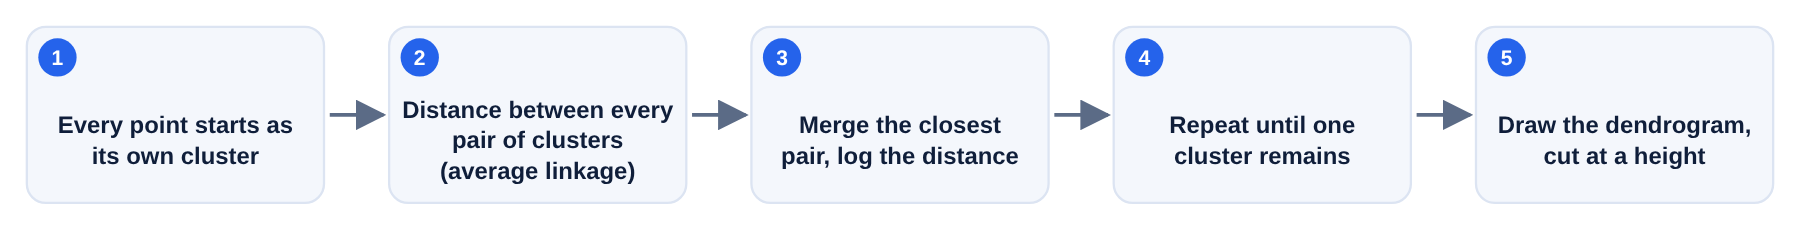

*Agglomerative clustering: merge, log, repeat, then read the tree.*



#### Five points, each its own cluster

The points go into a dictionary — each name paired with its coordinates — so that clusters can be referred to by the names of their members. Agglomerative clustering begins at the opposite end from K-means: no k to choose, and every point is its own cluster, so a second dictionary maps each cluster's name to the list of points it holds — five clusters of one point each. (`{name: [name] for name in tiny_points}` builds it with one entry per point.)



In [41]:
tiny_points = {"a": (0, 0), "b": (0, 1), "c": (5, 5), "d": (5, 6), "e": (6, 5)}
clusters = {name: [name] for name in tiny_points}
clusters

{'a': ['a'], 'b': ['b'], 'c': ['c'], 'd': ['d'], 'e': ['e']}

#### The distance between two clusters

Average linkage, as defined above: the mean of the straight-line distances between every point of one cluster and every point of the other.

$$d_{\text{average}}(A,B) = \frac{1}{\lvert A \rvert \, \lvert B \rvert} \sum_{\mathbf{a} \in A} \sum_{\mathbf{b} \in B} d(\mathbf{a}, \mathbf{b})$$



In [42]:
def cluster_distance(c1, c2, coords):
    """Average linkage: mean distance between every pair of points across the two clusters."""
    pts1 = [coords[p] for p in c1]
    pts2 = [coords[p] for p in c2]
    dists = [np.linalg.norm(np.array(p1) - np.array(p2)) for p1 in pts1 for p2 in pts2]
    return np.mean(dists)

#### Merging until one cluster remains

The loop repeats as long as more than one cluster is left (`while` keeps going while its condition is true). Each round compares every pair of clusters, keeps the closest pair, merges them under a combined name, and records the merge with its distance. The log is printed at the end.



> **Interpretation.** Compare the printed log line by line with the merge table above: the pairs and the distances match exactly. `a` and `b` merge first because they are closest; `c`, `d`, `e` merge into their own group; only at the last step do the two groups join, at 7.23. Read top to bottom, this log **is** the dendrogram, as text. This is the moment where “the algorithm” stops being a black box — every step is a comparison that could have been done with a ruler.



In [43]:
merges = []                                   # (left, right, merged name, distance), one per round
while len(clusters) > 1:
    names = list(clusters)
    best_pair, best_distance = None, np.inf   # np.inf is infinity: any real distance beats it
    for i in range(len(names)):
        for j in range(i + 1, len(names)):    # every pair exactly once
            d = cluster_distance(clusters[names[i]], clusters[names[j]], tiny_points)
            if d < best_distance:
                best_distance, best_pair = d, (names[i], names[j])
    left, right = best_pair
    merged = f"({left}+{right})"
    clusters[merged] = clusters[left] + clusters[right]
    del clusters[left], clusters[right]
    merges.append((left, right, merged, best_distance))

for left, right, merged, distance in merges:
    print(f"merge {left} and {right}  (distance={distance:.2f})  -> {merged}")

merge a and b  (distance=1.00)  -> (a+b)
merge c and d  (distance=1.00)  -> (c+d)
merge e and (c+d)  (distance=1.21)  -> (e+(c+d))
merge (a+b) and (e+(c+d))  (distance=7.23)  -> ((a+b)+(e+(c+d)))


#### The dendrogram

The same merge log as a tree. Each point sits on the baseline; each merge is drawn as a horizontal bar at the height of its distance, joining the two things merged. A dashed line marks one place to cut.



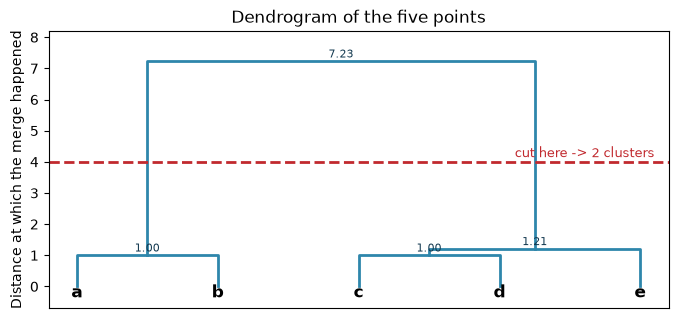

In [44]:
positions = {name: i for i, name in enumerate(["a", "b", "c", "d", "e"])}   # where each leaf sits
heights = {name: 0.0 for name in tiny_points}                                # leaves are at height 0
for left, right, merged, distance in merges:
    positions[merged] = (positions[left] + positions[right]) / 2
    heights[merged] = distance

fig, ax = plt.subplots(figsize=(8, 3.6))
for left, right, merged, distance in merges:
    ax.plot([positions[left], positions[left], positions[right], positions[right]],
            [heights[left], distance, distance, heights[right]], color="#2E86AB", linewidth=2)
    ax.text(positions[merged], distance + 0.12, f"{distance:.2f}", ha="center", fontsize=8, color="#12384f")
for name in ["a", "b", "c", "d", "e"]:
    ax.text(positions[name], -0.35, name, ha="center", fontsize=12, fontweight="bold")

cut_height = 4.0
ax.axhline(cut_height, color="#C1292E", linestyle="--", linewidth=2)
ax.text(4.1, cut_height + 0.15, "cut here -> 2 clusters", color="#C1292E", fontsize=9, ha="right")
ax.set_ylabel("Distance at which the merge happened")
ax.set_xticks([])
ax.set_ylim(-0.7, 8.2)
ax.set_title("Dendrogram of the five points")
plt.show()

#### What the chart shows

> **Interpretation.** Read the tree from the bottom up:
>
> - **Each horizontal bar is a merge**, drawn at the height of the distance at which it happened.
> - **Short bars near the bottom** — a with b at 1.00, c with d at 1.00, then e at 1.21 — are tight, obvious groupings.
> - **The tall bar at 7.23** says the final merge joined two things that are not alike at all.
> - **The dashed line at 4.0** crosses two vertical lines: cut there and there are two clusters.



#### Cutting the tree at a given height

> **One run, every k.** The dashed line at 4.0 crosses exactly two vertical lines, so it yields two clusters: {a, b} and {c, d, e}. Cut lower, at 1.1, and there would be three. That is the practical advantage over K-means: **one run, every k**, and the height of each merge says how confident the grouping is. A large jump in merge height — here from 1.21 to 7.23 — is the hierarchical equivalent of the elbow, and it argues for cutting just below the jump.



#### When to prefer hierarchical clustering over K-means

- **You do not know k** — You want to *see* the structure before deciding how many clusters there should be.
- **You want the tree itself** — Species taxonomies, document topic trees, organizational charts — the nested structure *is* the answer.
- **Your dataset is small** — The cost: AGNES compares every pair of clusters at every step, so it becomes slow on large datasets in a way K-means does not.

Both clustering methods answered the same question — which rows resemble which. The second unsupervised task asks a different one: which *items* tend to appear together.



### 9.4.3 Association rule mining

*“People who buy X also tend to buy Y”*

This is the technique behind “customers who bought this also bought…”, behind which products are placed next to each other on a shelf, and behind bundle offers. Nothing is being grouped: the output is a set of *rules*. **The data is a list of transactions**, each one the set of items in a single basket. These eight transactions are used throughout the section:

| Transaction | Items |
|:-:|:--|
| **1** | apple, beer, rice |
| **2** | apple, beer, rice |
| **3** | apple, beer |
| **4** | apple, banana |
| **5** | rice, beer, milk |
| **6** | rice, beer |
| **7** | banana, beer, milk |
| **8** | banana, milk |

> **Definition.** A **rule** is written `{X} → {Y}`, read “if X is in the basket, Y tends to be too”. Three measures, computed in turn below, decide whether a rule is worth anything.



#### 1 · Support — how popular an itemset is

$$\text{Support}(X) = \frac{\text{number of transactions containing } X}{\text{total number of transactions}}$$

Apple appears in transactions 1, 2, 3, 4 — that is 4 of 8, so $\text{Support}(\{apple\}) = 4/8 = \mathbf{50\%}$. The itemset {apple, beer, rice} appears in transactions 1 and 2 only, so $\text{Support}(\{apple, beer, rice\}) = 2/8 = \mathbf{25\%}$. Support is what stops you wasting time on rules that describe three shoppers out of a million.

> **In the language of probability.** Support is a **probability**, estimated by counting. Pick one basket at random: the chance that it contains apple is $P(\text{apple})$, and the share of baskets that contain apple — $4/8$ — is the estimate of that chance from the data (a relative frequency). Support of a set of items is the probability that *all* of them are in the basket: $P(\text{apple} \cap \text{beer} \cap \text{rice}) = 2/8$. Eight baskets make a rough estimate; a real store estimates the same probabilities from millions of receipts, which is why a minimum support is set before any rule is considered — a rule seen in three receipts out of a million is chance, not a pattern.



#### 2 · Confidence — how often Y is bought when X is bought

$$\text{Confidence}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)}$$

{apple, beer} appears in transactions 1, 2, 3 → support $3/8 = 37.5\%$. Apple alone has support $50\%$. So $\text{Confidence}(\{apple\} \rightarrow \{beer\}) = 0.375 / 0.5 = \mathbf{75\%}$: three out of every four baskets with apples also had beer. *That sounds like a strong rule.* The third measure says whether it is.

> **In the language of probability.** Confidence is a **conditional probability**: the chance of beer *given* that the basket has apple, written $P(\text{beer} \mid \text{apple})$. The definition of a conditional probability is $P(Y \mid X) = P(X \cap Y) / P(X)$ — restrict attention to the baskets where X happened, and ask how often Y happened among them. That is the formula above with supports in place of probabilities. Counting confirms it: 4 baskets have apple, and 3 of those 4 have beer, so $3/4 = 0.75$ — the same as $0.375 / 0.5$. Note that confidence has a **direction**: $\text{Confidence}(\{beer\} \rightarrow \{apple\}) = 0.375 / 0.75 = 0.5$, because only 3 of the 6 beer baskets have apple. $P(Y \mid X)$ and $P(X \mid Y)$ are different questions.



#### 3 · Lift — confidence, adjusted for how popular Y already is

$$\text{Lift}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X) \times \text{Support}(Y)}$$

Beer appears in transactions 1, 2, 3, 5, 6, 7 → support $6/8 = 75\%$. So $\text{Lift}(\{apple\} \rightarrow \{beer\}) = 0.375 / (0.5 \times 0.75) = 0.375/0.375 = \mathbf{1.00}$.

- **lift > 1** — X and Y appear together *more* often than chance would predict: a real positive association.
- **lift = 1** — Exactly as often as chance predicts: **no association at all**.
- **lift < 1** — *Less* often than chance: buying X makes Y *less* likely.



#### Where the lift formula comes from

*confidence compared with independence*

Lift compares the conditional probability of Y given X with the plain probability of Y — how much knowing that X is in the basket *changes* the chance of Y. Dividing confidence by the support of Y and writing both as probabilities gives the formula above:

$$\text{Lift}(X \rightarrow Y) = \frac{\text{Confidence}(X \rightarrow Y)}{\text{Support}(Y)} = \frac{P(Y \mid X)}{P(Y)} = \frac{P(X \cap Y)}{P(X)\,P(Y)}$$

The last step uses $P(Y \mid X) = P(X \cap Y) / P(X)$ from the confidence cell: the support of both items, divided by the product of the two single supports.

> **Lift measures distance from independence.** In probability, two events are **independent** when $P(X \cap Y) = P(X)\,P(Y)$ — knowing one tells you nothing about the other. Then $P(Y \mid X) = P(Y)$ and the lift is exactly 1. So lift measures how far two items are from independence:
>
> - **Lift = 1** — $P(Y \mid X) = P(Y)$: buying X leaves the chance of Y unchanged. No association.
> - **Lift > 1** — $P(Y \mid X) > P(Y)$: X raises the chance of Y. A positive association; a lift of 2 means Y is twice as likely once X is in the basket.
> - **Lift < 1** — $P(Y \mid X) < P(Y)$: X lowers the chance of Y. A negative association.

> **Worked example — apple and beer.** $P(\text{apple}) = 0.5$, $P(\text{beer}) = 0.75$, $P(\text{apple} \cap \text{beer}) = 0.375$.
>
> - If the two were independent they would appear together in $0.5 \times 0.75 = 0.375$ of the baskets — exactly the share observed.
> - $P(\text{beer} \mid \text{apple}) = 0.375 / 0.5 = 0.75 = P(\text{beer})$: knowing a basket has apple does not change the chance of beer at all.
> - $\text{Lift} = 0.75 / 0.75 = \mathbf{1.00}$. The 75% confidence that sounded strong is beer's own popularity showing through.



#### Confidence against lift

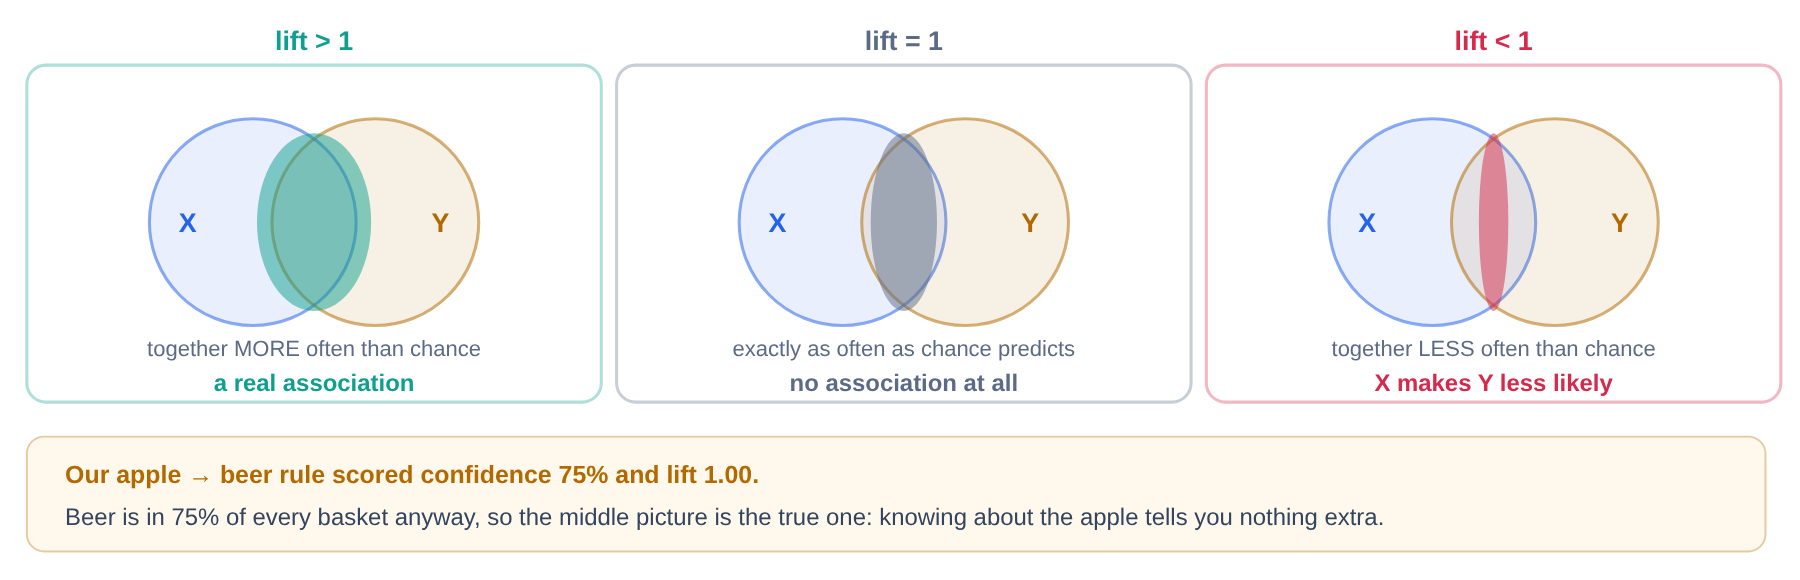

*Lift asks whether the overlap is bigger than you would get by chance alone. Confidence never asks that, which is how a popular item fools it.*

> **The conclusion of this example.** Confidence said 75% and sounded impressive — but beer is in 75% of **all** transactions anyway. Knowing that someone bought apples adds nothing. **Lift is what stops a popular item from looking like a real association.**



#### The rule apple → beer

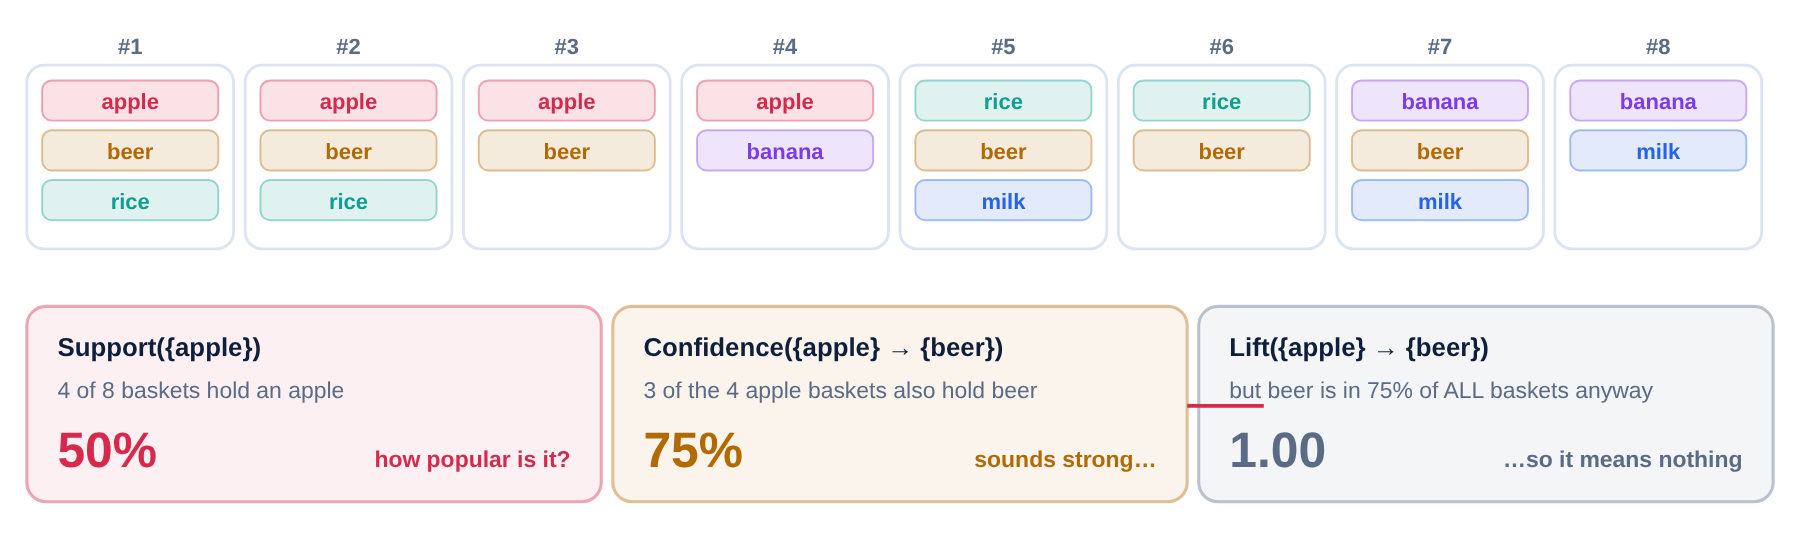

*Confidence and lift read the same baskets and disagree. Lift divides out how popular beer already is — which is the only reason you would not move the shelf.*

The three numbers are now computed in code, in the same order, from the same eight baskets.



#### The steps

*What the cells below do*

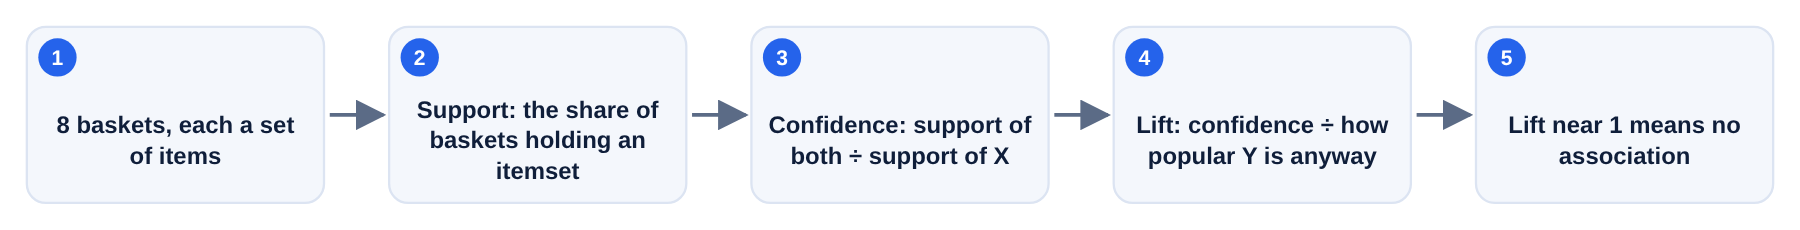

*The three measures, computed in the order they were defined.*



#### The eight baskets

Each basket is written as a set — an unordered collection with no duplicates, which is exactly what a shopping basket is: an item is either in it or not. The eight sets go in a list.



In [45]:
transactions = [
    {"apple", "beer", "rice"},
    {"apple", "beer", "rice"},
    {"apple", "beer"},
    {"apple", "banana"},
    {"rice", "beer", "milk"},
    {"rice", "beer"},
    {"banana", "beer", "milk"},
    {"banana", "milk"},
]
print(f"{len(transactions)} baskets")

8 baskets


#### The support function

The share of baskets that contain every item in the itemset. `itemset.issubset(t)` asks whether the whole itemset is present in basket t; the sum counts the baskets where it is, and the division turns the count into a share.

$$\text{Support}(X) = \frac{\text{number of transactions containing } X}{\text{total number of transactions}}$$



In [46]:
def support(itemset, transactions):
    itemset = set(itemset)
    return sum(1 for t in transactions if itemset.issubset(t)) / len(transactions)

#### Four supports

The function is called four times: apple alone (four of the eight baskets, the 50% worked out above), beer alone (six of eight — the number that will matter most for lift), apple and beer together (the numerator of both confidence and lift), and the three-item set apple, beer and rice.



> **Interpretation.** Four supports: 0.5 for apple, 0.75 for beer, 0.375 for both together, 0.25 for all three — each one matching the hand calculation. Support is the only thing counted from the data; confidence and lift are built from these numbers.



In [47]:
support_apple = support({"apple"}, transactions)
support_beer = support({"beer"}, transactions)
support_apple_beer = support({"apple", "beer"}, transactions)
support_apple_beer_rice = support({"apple", "beer", "rice"}, transactions)
print("support(apple)             =", support_apple)
print("support(beer)              =", support_beer)
print("support(apple, beer)       =", support_apple_beer)
print("support(apple, beer, rice) =", support_apple_beer_rice)

support(apple)             = 0.5
support(beer)              = 0.75
support(apple, beer)       = 0.375
support(apple, beer, rice) = 0.25


#### Confidence of apple → beer

Of the baskets with apple, the share that also hold beer: the support of both divided by the support of apple.

$$\text{Confidence}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)} = P(Y \mid X)$$



In [48]:
confidence_apple_to_beer = support_apple_beer / support_apple
round(confidence_apple_to_beer, 3)

0.75

#### Lift of apple → beer

Confidence compared with how often beer is bought anyway: the support of both divided by the product of the two single supports.

$$\text{Lift}(X \rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X) \times \text{Support}(Y)} = \frac{P(Y \mid X)}{P(Y)}$$

The code uses the first form; a value of 1 means the two items are independent.



> **Interpretation.** Confidence alone (0.75) makes it sound as if buying apples strongly predicts buying beer. Lift = 1.0 shows the truth: beer is bought in 75% of *all* baskets, so knowing someone bought apples adds nothing about whether they will buy beer. Lift is what stops a popular item from looking like a real association.



In [49]:
lift_apple_to_beer = support_apple_beer / (support_apple * support_beer)
round(lift_apple_to_beer, 3)

1.0

#### Where Section 9.4 leaves us

> **Looking ahead.** Two clustering methods and one rule-mining method, and none of them used a label. Sections 9.3 and 9.4 are the two extremes — every example labeled, or none. Most real projects sit in between: a few labels and a great many unlabeled rows. The next section is about that situation.



## 9.5 · Semi-supervised learning

*A few labels, a mountain of unlabeled data*

> **Definition.** Semi-supervised learning sits between the first two families: **a small amount of labeled data plus a large amount of unlabeled data.**

> **Labeling is the expensive half.** Collecting raw data is usually cheap; *labeling* it is not. A hospital can export a million chest X-rays overnight, but a radiologist can read only a few hundred. A phone company has years of recorded calls, but paying people to transcribe them costs a fortune. Semi-supervised learning is what you do when this is your situation — which, in practice, it very often is.

> **The idea.** Use the few labeled examples to decide what “similar” means, then match each unlabeled example to the labeled example it most resembles and let it “borrow” that label. Once enough unlabeled points have been given confident labels, they are folded back into the training set. This is **label****propagation**: labels spread outward from the few known points through the crowd of unknown ones. The mechanism is the nearest-neighbor rule of Section 9.3.1 with almost no training data.



#### The example — two labels

The example is deliberately extreme: **two** true labels — one point known to be a *monkey* at (1, 1), one known to be a *cat* at (8, 8) — and four unlabeled points that each get a prediction anyway.

| Unlabeled point | Nearest labeled example | Predicted label |
|---|---|---|
| **?1 (1.5, 1.2)** | monkey (1, 1) | monkey |
| **?2 (7.5, 8.5)** | cat (8, 8) | cat |
| **?3 (0.5, 0.8)** | monkey (1, 1) | monkey |
| **?4 (9, 7)** | cat (8, 8) | cat |



#### Label propagation

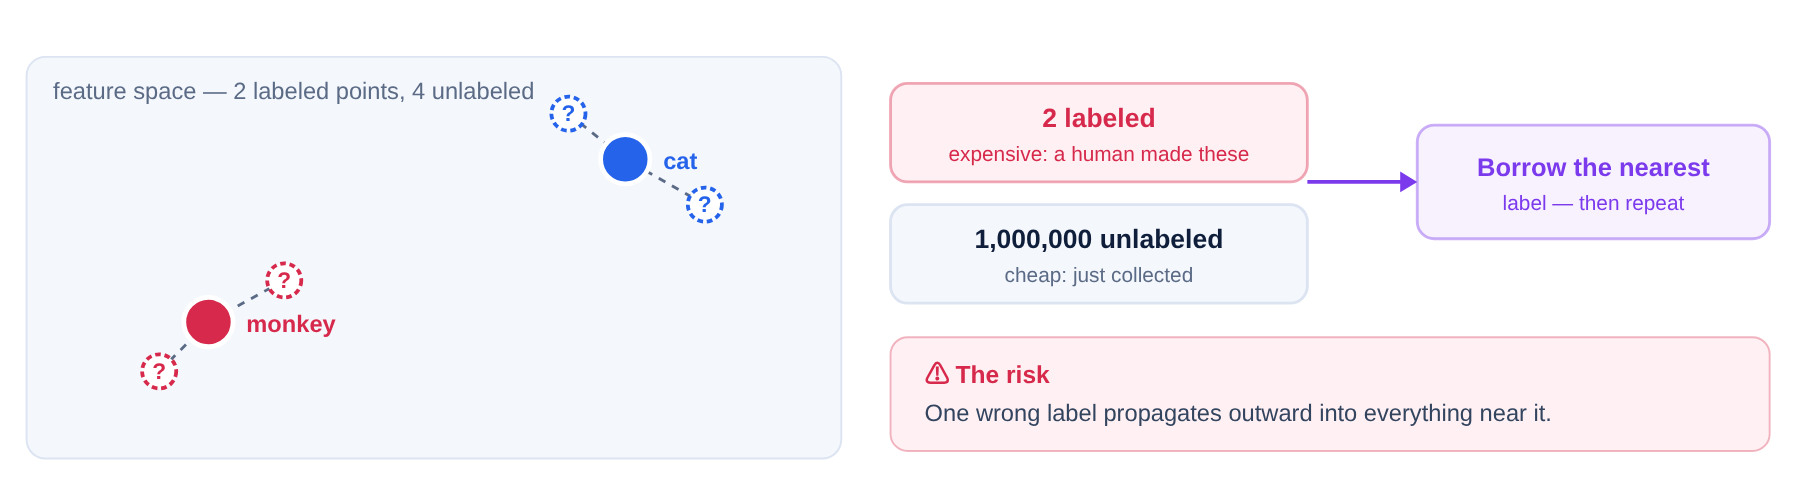

*Labels spread outward from the few known points through the crowd of unknown ones — which is why it is called **label propagation**.*

The two coordinates stand in for **features** extracted from each image — in a real system hundreds of numbers describing shape, texture and color rather than two — but the logic is identical.

> **A limitation.** If one of the few labels is wrong, that mistake propagates into everything near it. With only two labeled points there is no second opinion to catch the error.



#### The steps

*What the cells below do*

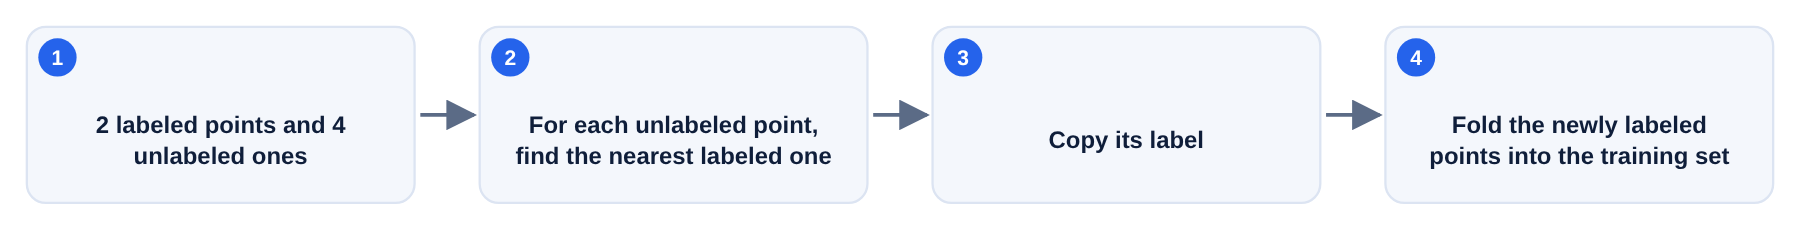

*Label propagation: the nearest-neighbor rule with almost no training data.*



#### Borrowing the nearest label

Two images whose label is known — a monkey and a cat — reduced to two coordinates each, and four points to be labeled. For each unlabeled point, `min(labeled_points, key=...)` finds the labeled point at the smallest straight-line distance — `key=` tells `min()` to compare the candidates by distance rather than by name, and `lambda` is a one-line function written in place — and that label is copied.



> **Interpretation.** Only two true labels, yet every unlabeled point got a prediction, by borrowing the label of the labeled point closest to it in feature space. That is label propagation in miniature, and it matches the table above line for line. Section 9.3 needed a label for every row; this needed two. The last family needs none at all — and no dataset either.



In [50]:
labeled_points = {"monkey": (1, 1), "cat": (8, 8)}
unlabeled_points = {"?1": (1.5, 1.2), "?2": (7.5, 8.5), "?3": (0.5, 0.8), "?4": (9, 7)}
for name, coords in unlabeled_points.items():
    nearest_label = min(labeled_points,
                        key=lambda lbl: np.linalg.norm(np.array(coords) - np.array(labeled_points[lbl])))
    print(f"{name} at {coords} -> nearest labeled example is '{nearest_label}' -> predicted label: {nearest_label}")

?1 at (1.5, 1.2) -> nearest labeled example is 'monkey' -> predicted label: monkey
?2 at (7.5, 8.5) -> nearest labeled example is 'cat' -> predicted label: cat
?3 at (0.5, 0.8) -> nearest labeled example is 'monkey' -> predicted label: monkey
?4 at (9, 7) -> nearest labeled example is 'cat' -> predicted label: cat


## 9.6 · Reinforcement learning

*No dataset at all — the learner creates its own data by playing*

Every method so far started from a table of examples, labeled or not. The third row of the map starts from nothing: there is no dataset until the learner acts and sees what happens. This is Samuel's checkers loop from Section 9.1, and the easiest way to see it is a very small game.

> **Definition.** Reinforcement learning has **no labeled dataset** — in fact no dataset at all to begin with. An **agent** tries an action, the world answers with a **reward**, and the agent adjusts so that actions which paid off are chosen more often. The data is created by the learner as it goes.

**The game.** A robot stands on the first of five squares in a corridor. A treasure lies on the last square. At each step the robot may move left or right; reaching the treasure earns a reward of 1 and ends the round. Nobody tells the robot where the treasure is or which way to go — it finds out by playing, and the question is whether it gets better at the game over many rounds.



#### The game, played

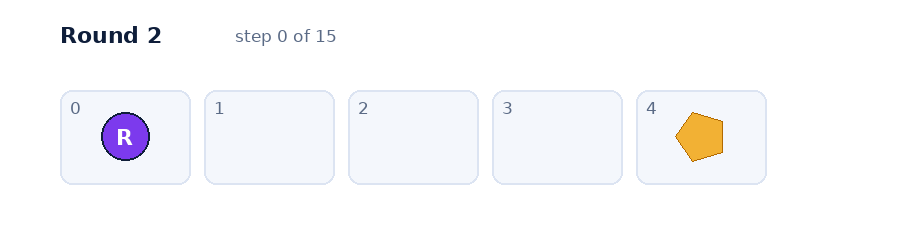

*The corridor game as the code below plays it, in rounds 2, 8, 30 and 100: the early rounds wander, the later ones walk straight to the treasure. The robot (R) starts on square 0; the treasure is on square 4.*



#### The four ingredients

| Ingredient | What it is | In the corridor game |
|---|---|---|
| **Agent** | The learner — the one choosing what to do next | The robot |
| **Action** | A choice the agent can make | Move left or move right |
| **Environment** | The world the agent acts in and gets feedback from | The corridor of five squares |
| **Reward** | Feedback saying how good the last action was | 1 for reaching the treasure, 0 for any other step |

> **The loop.** The agent picks an **action**; the **environment** responds with a **reward** and a new position; the agent updates what it believes; repeat. Over many rounds its behavior improves, because moves that led to the treasure are chosen more often. It is the same as learning a video game: the state and the reward come back from the game, and the player's next moves are better because of it. Nobody hands the player a labeled list of correct moves.



#### The reinforcement learning loop

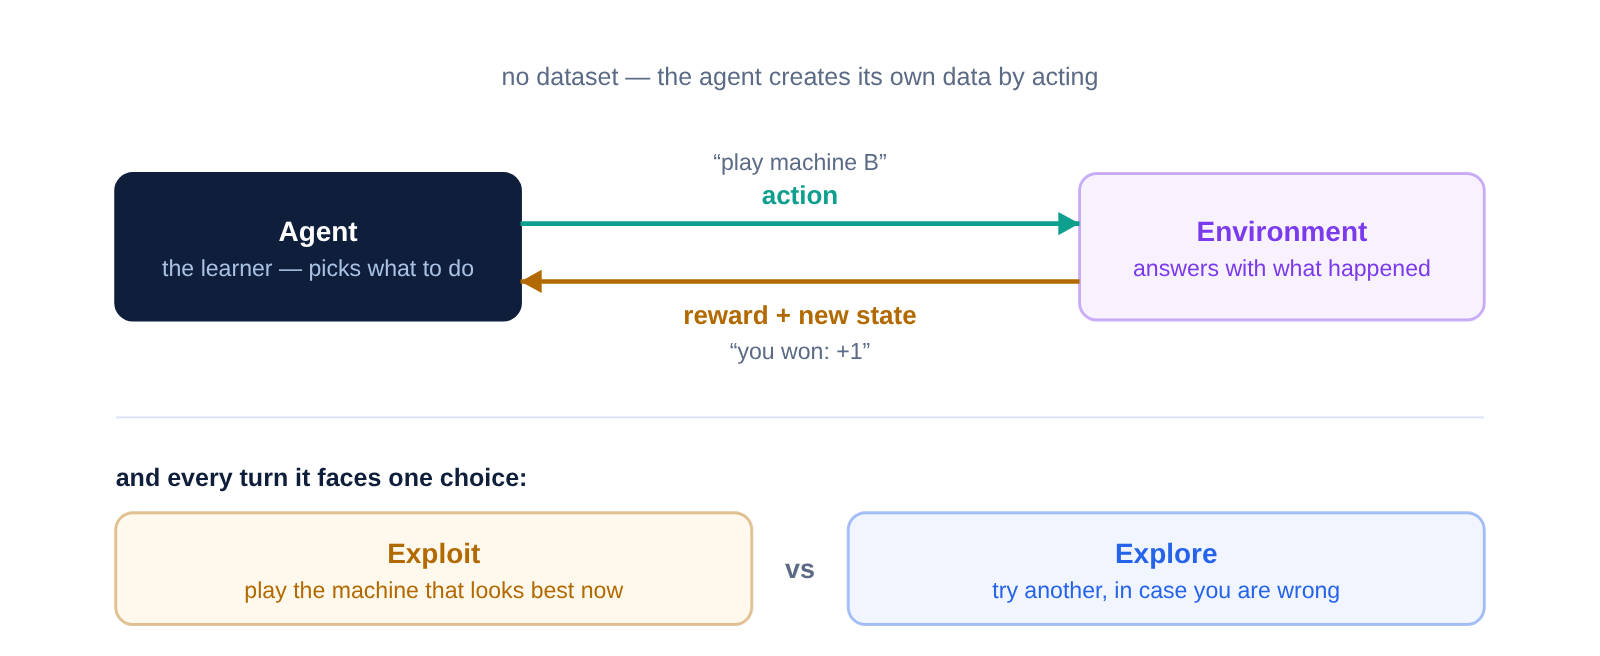

*The loop that replaces a training set. Actions that paid off get chosen more often — and the agent decides for itself what data to collect next.*



#### Exploring and exploiting

> **Why the robot sometimes moves at random.** A robot that always makes the move it currently believes best can get stuck: if it has never tried moving right from a square, it cannot know that right is better. So the agent keeps a small share of its moves random — here **ε = 0.2**, one move in five — to **explore**, and makes the best-known move the rest of the time to **exploit** what it has learned. This simple rule is called **epsilon-greedy**: greedy most of the time, random with probability ε. Too little exploring and it locks onto a poor habit; too much and it never cashes in on what it knows. Every reinforcement learning method balances these two.



#### The steps

*What the cells below do*

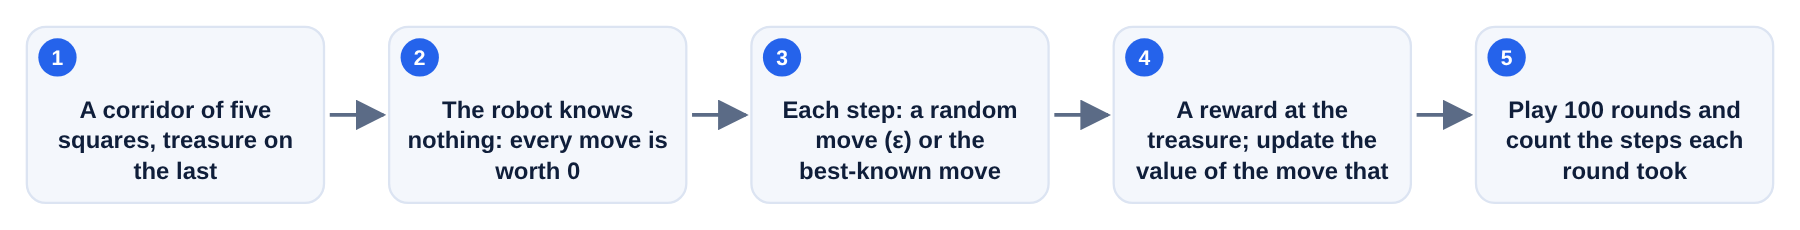

*The robot learns the corridor by playing it, one round at a time.*



#### The corridor and the robot's memory

The corridor is five squares numbered 0 to 4, with the treasure on square 4. The robot's memory is a table `value` with one row per square and one column per move — what the robot currently believes each move is worth from that square. It starts at zero everywhere: the robot knows nothing.



In [51]:
n_squares = 5                          # squares 0, 1, 2, 3, 4 — the treasure is on square 4
moves = ["left", "right"]
value = np.zeros((n_squares, 2))       # what the robot believes each move is worth, from each square
rng_game = np.random.default_rng(888102)
epsilon, learning_rate = 0.2, 0.5
pd.DataFrame(value, columns=moves, index=[f"square {i}" for i in range(n_squares)])

,left,right
square 0,0.0,0.0
square 1,0.0,0.0
square 2,0.0,0.0
square 3,0.0,0.0
square 4,0.0,0.0


#### One round of the game

The function plays one round from square 0 until the treasure is reached and returns how many steps it took. At each step the robot explores with probability ε (a random move) or exploits (the move with the higher value from its square — and when the two are equal, as they all are at the start, one is picked at random); the move is made; the reward is 1 on reaching square 4 and 0 otherwise. Then the robot **learns**: the value of the move it just made is nudged toward the reward it got plus a little less than the best value of the square it arrived at — “a little less”, because a treasure reached one step later is worth slightly less than one reached now. That single rule is enough for the values of moves leading toward the treasure to grow, round after round.



In [52]:
def play_one_round():
    square, steps = 0, 0
    while square != n_squares - 1:
        if rng_game.random() < epsilon:
            move = int(rng_game.integers(2))                 # explore: a random move
        else:
            best = np.flatnonzero(value[square] == value[square].max())   # the best-known move(s) here
            move = int(rng_game.choice(best))                # exploit; a tie is broken at random
        new_square = max(0, square - 1) if move == 0 else square + 1
        reward = 1 if new_square == n_squares - 1 else 0
        target = reward + 0.9 * value[new_square].max()      # what this move turned out to be worth
        value[square, move] += learning_rate * (target - value[square, move])   # nudge the belief toward it
        square, steps = new_square, steps + 1
    return steps

#### A hundred rounds

The robot plays 100 rounds. The number of steps each round took is recorded, and the first ten and the last ten are printed side by side.



> **Interpretation.** The early rounds are uneven — 15, 10, 8 steps — because with every value at 0 the robot is guessing (a lucky straight walk, like round 1, happens too). The last ten rounds are almost all 4 to 6 steps, close to the minimum of 4: the robot has learned to walk right. Nobody told it the treasure was on the right; the rewards did.



In [53]:
steps_per_round = [play_one_round() for _ in range(100)]
print("steps in the first ten rounds:", steps_per_round[:10])
print("steps in the last ten rounds: ", steps_per_round[-10:])

steps in the first ten rounds: [4, 15, 6, 7, 6, 8, 4, 10, 4, 7]
steps in the last ten rounds:  [6, 4, 4, 6, 4, 4, 4, 8, 4, 6]


#### What the robot learned

The memory table after 100 rounds. Read each row: the move with the larger value is the one the robot now prefers from that square.



> **Interpretation.** From every square the value of moving right is larger than the value of moving left, so the robot prefers right everywhere. The values also rise toward the treasure — moving right from square 3 is worth close to 1, from square 0 rather less — because a reward reached sooner is worth more. This table is the robot's **policy**: a learned behavior, not a predicted label.



In [54]:
learned = pd.DataFrame(value.round(2), columns=moves, index=[f"square {i}" for i in range(n_squares - 1)] + ["square 4 (treasure)"])
learned["preferred move"] = [moves[int(np.argmax(row))] if row.max() > 0 else "—" for row in value]
learned

,left,right,preferred move
square 0,0.64,0.73,right
square 1,0.66,0.81,right
square 2,0.73,0.90,right
square 3,0.81,1.00,right
square 4 (treasure),0.00,0.00,—


#### The learning curve

The steps to reach the treasure in each of the 100 rounds, as a curve; the dashed line is the shortest possible walk, four steps.



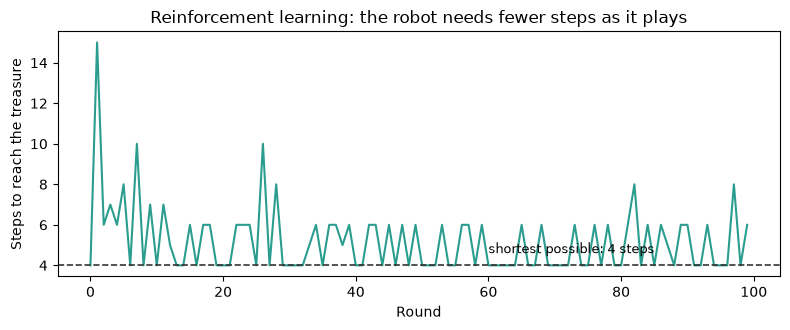

In [55]:
plt.figure(figsize=(8, 3.4))
plt.plot(steps_per_round, color="#2A9D8F")
plt.axhline(4, color="#333", linestyle="--", linewidth=1.2)
plt.text(60, 4.6, "shortest possible: 4 steps", fontsize=9)
plt.xlabel("Round")
plt.ylabel("Steps to reach the treasure")
plt.title("Reinforcement learning: the robot needs fewer steps as it plays")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the curve says:
>
> - **Early rounds are long and erratic** — with every value at 0 the robot is guessing, and a round can take many steps.
> - **The curve falls quickly** as the moves that led to the treasure gain value and are chosen more often.
> - **It never sits exactly on 4**, because one move in five is still random — the price of exploring. Real systems shrink ε as the agent becomes sure.



#### Where Section 9.6 leaves us

> **How this differs from the other families.** A supervised model treats all its training rows equally. A reinforcement learning agent **decides what data to collect next** by acting, and what it learns is a behavior — which move to make from where — rather than a label or a number. The same loop, with a much larger table or a neural network in place of it, is how programs learn to play chess, Go and video games.

That completes the three families of the map. The summary gathers what each one contributed.



## 9.7 · Summary

*The six things to carry out of this chapter*

The chapter began with one idea — data in, rules out — and a map with three rows. Each row was then built by hand and in code. These are the six things to keep:

1. **Machine learning learns from data** — Machines improve from experience instead of being programmed with every rule. The human supplies data; the machine supplies the rules. **(Section 9.1)**
2. **Supervised learning needs labels** — Given examples with known answers, it predicts either a discrete class (**classification**) or a continuous number (**regression**) for new cases. **(Section 9.3)**
3. **Test on unseen data** — A score only means something when it is measured on data the model never trained on — otherwise it measures memorization. Cross-validation chooses the model; the test set is touched once; the confusion matrix says which mistakes were made. **(Sections 9.3.2–9.3.5)**
4. **Unsupervised learning finds structure** — With no labels at all, **clustering** (K-means, hierarchical) groups similar items and **association rules** (support, confidence, lift) find “X implies Y” patterns. **(Section 9.4)**
5. **Semi-supervised learning bridges the two** — A little labeled data plus a lot of unlabeled data still yields predictions — which matters because labeling is the expensive part. **(Section 9.5)**
6. **Reinforcement learning learns by playing** — An agent improves its behavior through trial, error and reward, with no dataset at all — the robot learned the corridor from nothing but the treasure — and must balance exploring against exploiting. **(Section 9.6)**



#### The whole chapter

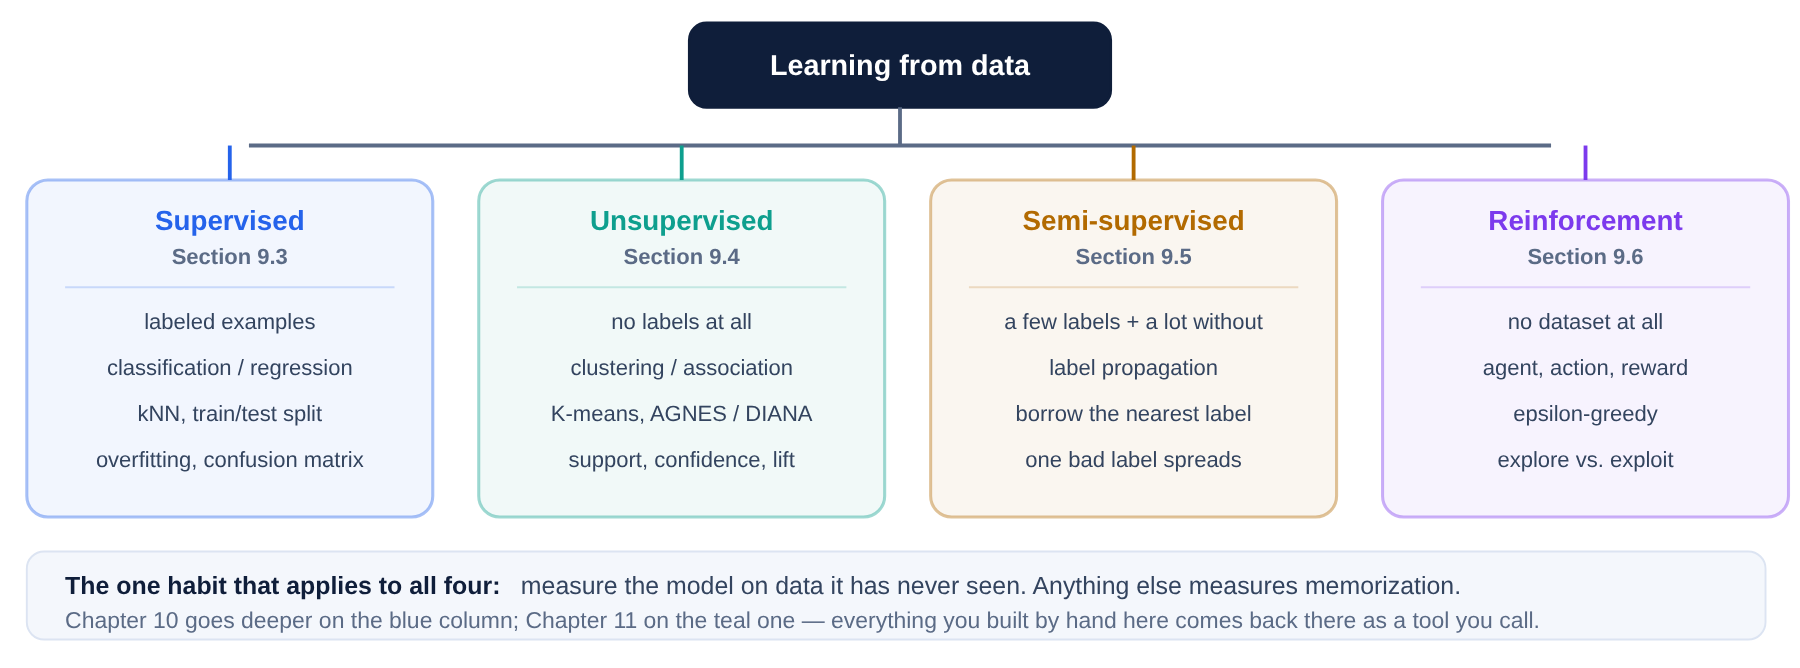

*The whole chapter on one page. Four families, told apart by one question: what does your data look like?*

> **Where this leads.** Chapter 10 takes the supervised half and works through named algorithms — linear and logistic regression, decision trees and more — evaluated with the tools of Sections 9.3.2–9.3.5. Chapter 11 does the same for the unsupervised half, going deeper into clustering and dimensionality reduction. Everything built by hand here reappears there as a tool you call rather than a loop you write.



### 9.7.1 Glossary

*Every term introduced in this chapter, in one place*

| Term | Meaning |
|---|---|
| **Accuracy** | Correct predictions ÷ total test cases. Only meaningful on data the model has not seen. |
| **Agent** | In reinforcement learning, the learner that chooses actions — the robot in the corridor game. |
| **AGNES** | Agglomerative (bottom-up) hierarchical clustering: start with every point alone, repeatedly merge the two closest clusters. |
| **Association rule** | A pattern of the form `{X} → {Y}`, “baskets containing X tend to contain Y too”. |
| **Attribute** | One measured property of an example — one column of the data table. Also called a *feature* or *input variable*. |
| **Bias** | Error that points the same way every time, because the model is too simple for the pattern. High bias is the signature of *underfitting*. |
| **Centroid** | The center of a cluster: the mean position of all points assigned to it. |
| **Classification** | Supervised learning where the predicted label is a discrete class. |
| **Cluster** | A group of examples that resemble one another, discovered rather than given. |
| **Confidence** | For rule `{X} → {Y}`: Support(X ∪ Y) ÷ Support(X). How often Y appears when X does. |
| **Confusion matrix** | The 2×2 table of TP, FP, FN and TN counts. Every metric in Section 9.3.5 is one of those four divided by some group of them. |
| **Cross-validation (k-fold)** | Split the training data into k folds and take turns validating on one while training on the rest, then average the k scores. |



#### Glossary — D to I

| Term | Meaning |
|---|---|
| **Decision boundary** | The region separating the classes — the classifier's answer for every possible input. For kNN, that picture *is* the model. |
| **Dendrogram** | The tree diagram produced by hierarchical clustering; join heights are merge distances. |
| **DIANA** | Divisive (top-down) hierarchical clustering: start with one cluster, repeatedly split the most mixed-up one. |
| **Elbow method** | Choosing `k` by plotting inertia against `k` and taking the point where the curve flattens. |
| **Epsilon-greedy** | An exploration strategy: make a random move with probability ε, otherwise the best-known move. |
| **Euclidean distance** | Straight-line distance: square the gap in each column, add, take the square root. |
| **Exploration / exploitation** | Trying options to learn about them, against taking the option that currently looks best. |
| **F1 score** | The harmonic mean of precision and recall. Deliberately harsh — it stays close to the smaller of the two. |
| **Hard clustering** | Every point belongs to exactly one cluster (K-means). *Soft* clustering allows partial membership. |
| **Imbalanced classes** | When one class is far more common than another, which makes plain accuracy misleading. |
| **Inertia** | Total squared distance from every point to its own centroid (the J that K-means minimizes). Always falls as k rises, so it cannot pick k on its own. |



#### Glossary — K to R

| Term | Meaning |
|---|---|
| **K-means** | Clustering by repeatedly assigning points to the nearest centroid and recomputing centroids. |
| **k-nearest-neighbors (kNN)** | Classify a new example by letting its `k` most similar training examples vote. |
| **Label** | The answer to be predicted. Also called the *class*, *target*, or *output variable*. |
| **Label propagation** | Spreading labels from a few known examples to nearby unlabeled ones (semi-supervised). |
| **Lift** | For rule `{X} → {Y}`: Support(X ∪ Y) ÷ (Support(X) × Support(Y)). 1 means no association. |
| **Linkage** | How the distance between two *clusters* is defined: single, complete, or average. |
| **Manhattan distance** | Add up the gaps column by column — the distance you walk along streets rather than fly. |
| **Model** | The rule an algorithm ends up with after training. |
| **Normalization** | Rescaling attributes to comparable ranges, so no single one dominates a distance calculation. |
| **Overfitting** | Learning the training data too specifically, so test performance is much worse than training performance. |
| **Precision** | TP ÷ (TP + FP). Of the cases flagged, how many were real? Use it when acting on a flag is expensive. |
| **Recall** | TP ÷ (TP + FN). Of the real cases, how many were caught? Use it when missing a case is expensive. |
| **Regression** | Supervised learning where the predicted value is a continuous number. |
| **Reward** | In reinforcement learning, the feedback saying how good the last action was — 1 for reaching the treasure. |



#### Glossary — S to V

| Term | Meaning |
|---|---|
| **Policy** | The behavior a reinforcement learning agent ends up with: which action to take in which situation. |
| **Semi-supervised learning** | Learning from a small labeled set plus a large unlabeled set. |
| **Silhouette score** | How close each point sits to its own cluster against the nearest other one, from −1 to +1. A number to maximize, unlike the elbow. |
| **Specificity** | TN ÷ (TN + FP). Of the negatives, how many were correctly left alone? |
| **Standardization** | Replacing a column by z = (x − mean) ÷ standard deviation, so every column speaks the same units before any distance is computed. |
| **Stopping criterion** | The condition that ends an iterative algorithm — for K-means, centroids no longer moving. |
| **Support** | The proportion of transactions containing a given itemset. |
| **Target function** | The rule from inputs to label that a supervised learner is trying to learn. |
| **Test set** | Labeled data held back from training, used once to measure the finished model. |
| **Training set** | The labeled data the model is allowed to learn from. |
| **Underfitting** | The model is too simple to capture the pattern, so it does badly on training *and* test data. The opposite failure to overfitting. |
| **Validation set** | Held-out data used to *choose* between models and settings, so the test set stays untouched for the single final measurement. |
| **Variance** | How much the fitted model jumps around when it is retrained on a different sample. High variance is the signature of *overfitting*. |



### 9.7.2 Sources and further reading

*Where the examples in this chapter come from*

- **On machine learning and its history** — - *Arthur Samuel* — Wikipedia.
- *The first of its kind AI model* — Samuel's Checkers Playing Program.
- *What are the types of machine learning?* — AnalyticsLearn.
- **On the everyday applications in Section 9.1.2** — - *Deep dive into Netflix's recommender system.*
- *Facebook may add your profile photo to its facial recognition database.*
- *Gmail: ensuring a spam-free inbox with machine learning* — Google.
- *Top 10 applications of machine learning* — Edureka.
- **On self-driving cars (Section 9.1.3)** — - *The role of machine learning in autonomous vehicles.*

> **Within this course.**
>
> - **Chapter 2** — the data matrix; every table in this chapter is one, with a label column added.
> - **Chapter 10** — supervised learning in depth: regression and classification algorithms, and how to evaluate them.
> - **Chapter 11** — unsupervised learning in depth: more clustering, and dimensionality reduction.



### 9.7.3 Check your understanding

*Answer first, then open the box*

**1. Your classifier scores 100% on the data it was trained on. How impressed should you be?**

> Not at all. Training accuracy measures memorization, not learning — a degree-16 polynomial passes close to every one of 18 points and predicts nonsense between them. Only performance on data the model has never seen carries information.

**2. A k-nearest-neighbors classifier with k = 1 has a jagged boundary with small islands. What is happening, and what would you change?**

> Overfitting. With one neighbor, every mislabeled training point claims its own territory because nothing can outvote it. Increase k so the local majority smooths over noisy points — but not so far that the boundary becomes a straight line and starts underfitting.

**3. Explain the difference between high bias and high variance.**

> High bias (underfitting) means the model is too simple to capture the real pattern, so it does badly on training *and* test data. High variance (overfitting) means it is flexible enough to fit the noise, so it does excellently on training data and badly on test data. The gap between the two errors is the diagnostic.

**4. You tried 20 model settings and reported the best test-set score. What is wrong?**

> The test set was used to choose the model, so it is no longer unseen and the reported score is optimistic — the best of 20 tries is partly luck. Use a validation set (or cross-validation) for selection and keep the test set for one final evaluation.

**5. Why does k-fold cross-validation help most when data is scarce?**

> Because every observation is used for training in k−1 folds and for validation in one, so no data is permanently sacrificed to a held-out set. It also gives k scores rather than one, so you can see how *stable* the estimate is.

**6. A model that flags nobody achieves 94% accuracy on a screening task. What went wrong?**

> Class imbalance. Only 6% of the people have the condition, so predicting “no” for everyone is right 94% of the time and useless. Report recall (were the sick patients caught?) and precision (were the flags real?), and look at the confusion matrix rather than a single number.



#### Check your understanding — continued

*questions 7 to 11*

**7. Raising the decision threshold improves precision and hurts recall. Which should you prefer for a cancer screening test, and which for a spam filter?**

> Screening should favor **recall** — missing a real case is far worse than an unnecessary follow-up. A spam filter should favor **precision** — a real email lost to the spam folder is far worse than a spam message reaching the inbox. The threshold encodes that value judgment, and it is not a technical decision.

**8. K-means with k = 5 returns five neat clusters. Does the data have five groups?**

> Not necessarily — K-means returns exactly what it is asked for. Check the elbow and the silhouette score to see whether five is geometrically supported, then ask whether the groups mean anything to someone who knows the domain. Neither statistic can answer that second question.

**9. What can a dendrogram do that K-means cannot?**

> Give every k from one run. Cutting the tree at a different height yields a different number of clusters without re-running anything, and the height of each merge says how similar the merged groups were — a large jump in height is evidence about where to cut.

**10. The corridor robot is set to ε = 0, so it always makes the move it believes best. Why can it fail to learn the game?**

> Because at the start every move is worth 0 and the tie is broken the same way every time — it may keep moving left, never reach the treasure, never receive a reward, and never change a value. A small ε makes it try the other move sometimes, which is all it needs to discover the treasure; after that exploiting takes over.

**11. Association rule mining reports confidence 75% for {apple} → {beer}. Should you move the beer?**

> No — check the lift first. Section 9.4.3 showed lift = 1.00, meaning beer appears in 75% of *all* transactions regardless of apples. The confidence is high and the rule carries no information.



## 9.8 · Homework

*Six exercises plus a bonus — this is the graded work*

The exercises use the methods of this chapter on a new dataset, in the order the chapter taught them: a nearest-neighbor classification (Section 9.3.1), a train/test accuracy (Section 9.3.2), a clustering (Section 9.4.1), association rules (Section 9.4.3), and two written questions on the map of Section 2. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework dataset — hotel guests

*run this cell, but do not modify it*

Run this cell once and do not edit it: everyone's numbers must match, and the seed makes sure they do. It builds `guests`, a table of 24 hotel guests with the nights they stayed, their total spend and whether they became a loyalty member, and `guest_addons`, a list of 24 sets holding the add-ons each guest bought (breakfast, spa, parking). The first five guests are shown.



In [56]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)
n = 24

nights_stayed = hw_rng.integers(1, 10, n)
spend_per_night = np.round(hw_rng.uniform(1200, 4500, n), 0)
total_spend = nights_stayed * spend_per_night
loyalty_member = total_spend > np.median(total_spend)   # the label for the classification exercises

addon_choices = ["breakfast", "spa", "parking"]         # add-on purchases, for the association exercise
guest_addons = []
for _ in range(n):
    n_addons = hw_rng.integers(0, 3)
    chosen = hw_rng.choice(addon_choices, size=n_addons, replace=False)
    guest_addons.append(set(chosen))

guests = pd.DataFrame({
    "guest_id": range(1, n + 1),
    "nights_stayed": nights_stayed,
    "total_spend": total_spend,
    "loyalty_member": loyalty_member,
})
guests.head()

,guest_id,nights_stayed,total_spend,loyalty_member
0,1,8,22160.0,True
1,2,5,21430.0,True
2,3,6,11796.0,False
3,4,9,35856.0,True
4,5,6,11496.0,False


#### Exercise 1 — Nearest-neighbor classification

Using the Section 9.3.1 pattern, write a distance function and classify a **new guest** with `nights_stayed=6` and `total_spend=18000` as `loyalty_member` True/False, by finding their nearest neighbor in `guests` (using just `nights_stayed` and `total_spend`).



In [57]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — Train/test accuracy

Split `guests` into the first 18 rows (train) and the last 6 rows (test). “Train” a simple threshold model: find the minimum `total_spend` among training rows where `loyalty_member` is `True`, and use that as your threshold. Apply it to the test rows and report accuracy, as in Section 9.3.2.



In [58]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — K-means clustering

Using the Section 9.4.1 `kmeans()` function, cluster the guests into `k=2` groups based on `nights_stayed` and `total_spend`.
**Hint:** build a numpy array with `guests[["nights_stayed", "total_spend"]].values`
Plot the result as a scatter plot, coloring points by cluster.

**Then look at your clusters and answer this:** `total_spend` runs into the tens of thousands while `nights_stayed` never passes 9. Given the caution on attribute scale in Section 9.3.1, which of the two columns decided your clusters — and what would change if you standardized both first?



In [59]:
# YOUR CODE HERE (Exercise 3)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Association rules

Using `guest_addons` (a list of sets, one per guest) and the Section 9.4.3 `support()` function, compute `Support({breakfast})`, `Support({breakfast, spa})`, `Confidence({breakfast} -> {spa})`, and `Lift({breakfast} -> {spa})`. Is there a positive, negative, or no association between buying breakfast and buying spa?



In [60]:
# YOUR CODE HERE (Exercise 4)

#### Your answer — Exercise 4

*Double-click this cell and type your answer here.*



#### Exercise 5 — Classification or regression

For each of these hotel business questions, say whether it is a classification or a regression problem (Section 9.3.6):

- (a) “will this guest become a loyalty member?”
- (b) “how much will this guest spend in total?”
- (c) “which room type (Standard / Deluxe / Suite) will this guest book?”



In [61]:
# YOUR CODE HERE (Exercise 5)
# (A written answer — this cell may be left empty or used for scratch work.)

#### Your answer — Exercise 5

*Double-click this cell and type your answer here.*



#### Exercise 6 — Supervised, unsupervised, or reinforcement

The hotel wants to try three new data projects. For each, name which type of machine learning fits best, and why (Section 9.2.1):

- (a) grouping guests into segments for targeted email campaigns, with no predefined segments;
- (b) predicting whether a guest will cancel their booking, using past bookings labeled “cancelled” or “kept”;
- (c) an AI system that adjusts room prices in real time and learns from whether rooms sell out or stay empty.



In [62]:
# YOUR CODE HERE (Exercise 6)
# (A written answer — this cell may be left empty or used for scratch work.)

#### Your answer — Exercise 6

*Double-click this cell and type your answer here.*



#### Bonus — a longer corridor with a trap

Using the Section 9.6 pattern, make the corridor 8 squares long and put a trap on square 3 that gives a reward of −1 whenever the robot steps on it (the treasure is still on the last square). Change `n_squares` and the reward line in `play_one_round`, retrain for 200 rounds, plot the steps per round, and print the learned table. Does the robot still learn to walk right? What does the value of moving right from square 2 look like, and why?



In [63]:
# YOUR CODE HERE (Bonus)

#### Your answer — the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file

